In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
warnings.filterwarnings('ignore')
# Use pd.concat() to combine the head and tail
#combined_data = pd.concat([data_train.head(3), data_train.tail(3)], ignore_index=True)
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss
warnings.filterwarnings('ignore')

# 观察基础数据

In [2]:
data_train = pd.read_csv('./train.csv') 
data_test_a = pd.read_csv('./testA.csv')

In [3]:
print(data_train.shape)
print(data_test_a.shape)

(800000, 47)
(200000, 46)


In [4]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 47 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  800000 non-null  int64  
 1   loanAmnt            800000 non-null  float64
 2   term                800000 non-null  int64  
 3   interestRate        800000 non-null  float64
 4   installment         800000 non-null  float64
 5   grade               800000 non-null  object 
 6   subGrade            800000 non-null  object 
 7   employmentTitle     799999 non-null  float64
 8   employmentLength    753201 non-null  object 
 9   homeOwnership       800000 non-null  int64  
 10  annualIncome        800000 non-null  float64
 11  verificationStatus  800000 non-null  int64  
 12  issueDate           800000 non-null  object 
 13  isDefault           800000 non-null  int64  
 14  purpose             800000 non-null  int64  
 15  postCode            799999 non-nul

## 1.1 查找对象特征和数值特征

In [6]:
#首先我们查找出数据中的对象特征和数值特征
numerical_fea = list(data_train.select_dtypes(exclude=['object']).columns)
category_fea = list(filter(lambda x: x not in numerical_fea,list(data_train.columns)))
label = 'isDefault'
numerical_fea.remove(label)

In [7]:
category_fea

['grade', 'subGrade', 'employmentLength', 'issueDate', 'earliesCreditLine']

In [8]:
numerical_fea

['id',
 'loanAmnt',
 'term',
 'interestRate',
 'installment',
 'employmentTitle',
 'homeOwnership',
 'annualIncome',
 'verificationStatus',
 'purpose',
 'postCode',
 'regionCode',
 'dti',
 'delinquency_2years',
 'ficoRangeLow',
 'ficoRangeHigh',
 'openAcc',
 'pubRec',
 'pubRecBankruptcies',
 'revolBal',
 'revolUtil',
 'totalAcc',
 'initialListStatus',
 'applicationType',
 'title',
 'policyCode',
 'n0',
 'n1',
 'n2',
 'n3',
 'n4',
 'n5',
 'n6',
 'n7',
 'n8',
 'n9',
 'n10',
 'n11',
 'n12',
 'n13',
 'n14']

In [9]:
# 定义基准时间常量（增强可维护性）
REFERENCE_DATE = '2007-06-01'

for df in [data_train, data_test_a]:
    # 带异常处理的时间解析
    df['issueDate'] = pd.to_datetime(
        df['issueDate'], 
        format='%Y-%m-%d',
        errors='coerce'  # 将无效日期转为NaT
    )
    
    # 缺失值检测与报告
    nan_count = df['issueDate'].isna().sum()
    print(f"检测到无效日期数量：{nan_count}")
    
    # 向量化计算时间差
    df['issueDateDT'] = (
        df['issueDate'] - pd.Timestamp(REFERENCE_DATE)
    ).dt.days
    
    # 生成衍生时序特征（增强特征工程维度）
    #df['issueYear'] = df['issueDate'].dt.year
    #df['issueQuarter'] = df['issueDate'].dt.quarter

检测到无效日期数量：0
检测到无效日期数量：0


In [10]:
for df in [data_train, data_test_a]:
    # 方法1：正则表达式提取4位连续数字（鲁棒性更强）
    df['earliesCreditYear'] = df['earliesCreditLine'].str.extract(r'(\d{4})').astype(int)

    # 异常值检测
    invalid_mask = df['earliesCreditYear'].isna()
    print(f"异常数据占比：{invalid_mask.mean():.2%}")
    
    # 业务逻辑修正（示例）
    #df.loc[invalid_mask, 'earliesCreditYear'] = df['issueYear'] - 5  # 默认设为借款前5年

异常数据占比：0.00%
异常数据占比：0.00%


In [11]:
print(data_train['earliesCreditYear'].head(10))

0    2001
1    2002
2    2006
3    1999
4    1977
5    1998
6    2006
7    1994
8    1994
9    1993
Name: earliesCreditYear, dtype: int64


In [12]:
import pandas as pd

# 假设df是你的数据框
# 查看homeOwnership列的类别分布
homeownership_counts = data_train['isDefault'].value_counts()
print(homeownership_counts)

isDefault
0    640390
1    159610
Name: count, dtype: int64


# 3.2 查看缺失值情况

In [ ]:
#data_train.isnull().sum()

In [14]:
# 检查并仅显示存在缺失值的列
missing_values = data_train.isnull().sum()
missing_values[missing_values > 0]

employmentTitle           1
employmentLength      46799
postCode                  1
dti                     239
pubRecBankruptcies      405
revolUtil               531
title                     1
n0                    40270
n1                    40270
n2                    40270
n3                    40270
n4                    33239
n5                    40270
n6                    40270
n7                    40270
n8                    40271
n9                    40270
n10                   33239
n11                   69752
n12                   40270
n13                   40270
n14                   40270
dtype: int64

## 3.2.1 中位数、众数填充

In [15]:
import pandas as pd
import numpy as np

def employmentLength_to_int(s):
    # 统一转换为字符串处理
    if pd.isnull(s):
        return np.nan
    s = str(s)  # 强制类型转换
    
    # 处理浮点数和字符串
    try:
        # 尝试直接转换为整数
        return int(float(s.split()[0]))
    except (ValueError, IndexError):
        # 如果转换失败，返回np.nan
        return np.nan

# 数据处理函数
def process_employment_length(data):
    # 统一格式 + 处理特殊字符
    data['employmentLength'] = data['employmentLength']\
        .replace({'10+ years': '10 years', '< 1 year': '0 years'})\
        .fillna('nan')\
        .astype(str)  # 强制转为字符串类型
    
    # 创建新变量 eyear
    data['eyear'] = data['employmentLength'].apply(employmentLength_to_int)
    
    return data

# 先处理数据
data_train = process_employment_length(data_train)
data_test_a = process_employment_length(data_test_a)

# 计算训练集众数 (避免数据泄漏)
employment_mode = data_train['eyear'].mode()[0]

# 用训练集众数填补所有缺失
data_train['eyear'] = data_train['eyear'].fillna(employment_mode).astype(int)
data_test_a['eyear'] = data_test_a['eyear'].fillna(employment_mode).astype(int)

In [16]:
#按照中位数填充数值型特征
data_train[numerical_fea] = data_train[numerical_fea].fillna(data_train[numerical_fea].median())
data_test_a[numerical_fea] = data_test_a[numerical_fea].fillna(data_train[numerical_fea].median())
#按照众数填充类别型特征
data_train[category_fea] = data_train[category_fea].fillna(data_train[category_fea].mode())
data_test_a[category_fea] = data_test_a[category_fea].fillna(data_train[category_fea].mode())

In [17]:
data_train.isnull().sum()

id                    0
loanAmnt              0
term                  0
interestRate          0
installment           0
grade                 0
subGrade              0
employmentTitle       0
employmentLength      0
homeOwnership         0
annualIncome          0
verificationStatus    0
issueDate             0
isDefault             0
purpose               0
postCode              0
regionCode            0
dti                   0
delinquency_2years    0
ficoRangeLow          0
ficoRangeHigh         0
openAcc               0
pubRec                0
pubRecBankruptcies    0
revolBal              0
revolUtil             0
totalAcc              0
initialListStatus     0
applicationType       0
earliesCreditLine     0
title                 0
policyCode            0
n0                    0
n1                    0
n2                    0
n3                    0
n4                    0
n5                    0
n6                    0
n7                    0
n8                    0
n9              

# 3.3 特征转换

In [18]:
#查看类别特征
category_fea

['grade', 'subGrade', 'employmentLength', 'issueDate', 'earliesCreditLine']

In [19]:
#类别处理特征
# 部分类别特征
cate_features = ['grade', 'subGrade', 'employmentTitle', 'homeOwnership', 'verificationStatus', 'purpose', 'postCode', 'regionCode', \
                 'applicationType', 'initialListStatus', 'title', 'policyCode']
for f in cate_features:
    print(f, '类型数：', data_train[f].nunique())

grade 类型数： 7
subGrade 类型数： 35
employmentTitle 类型数： 248683
homeOwnership 类型数： 6
verificationStatus 类型数： 3
purpose 类型数： 14
postCode 类型数： 932
regionCode 类型数： 51
applicationType 类型数： 2
initialListStatus 类型数： 2
title 类型数： 39644
policyCode 类型数： 1


## 3.3.1 字典映射 grade subgrade

In [20]:
#等级这种类别特征，是有优先级的可以labelencode
for data in [data_train, data_test_a]:
    data['grade'] = data['grade'].map({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})

In [21]:
# 1️⃣ 创建 subgrade 的映射字典
subgrade_mapping = {
    'A1': 1, 'A2': 2, 'A3': 3, 'A4': 4, 'A5': 5,
    'B1': 6, 'B2': 7, 'B3': 8, 'B4': 9, 'B5': 10,
    'C1': 11, 'C2': 12, 'C3': 13, 'C4': 14, 'C5': 15,
    'D1': 16, 'D2': 17, 'D3': 18, 'D4': 19, 'D5': 20,
    'E1': 21, 'E2': 22, 'E3': 23, 'E4': 24, 'E5': 25,
    'F1': 26, 'F2': 27, 'F3': 28, 'F4': 29, 'F5': 30,
    'G1': 31, 'G2': 32, 'G3': 33, 'G4': 34, 'G5': 35
}

# 2️⃣ 进行编码替换
for data in [data_train, data_test_a]:
    data['subGrade'] = data['subGrade'].map(subgrade_mapping)

# 3️⃣ 检查是否替换成功
print(data_train[['subGrade']].head(10))
print(data_test_a[['subGrade']].head(10))


   subGrade
0        22
1        17
2        18
3         4
4        12
5         5
6         4
7        13
8        12
9         9
   subGrade
0         8
1        15
2        19
3        14
4        16
5         1
6        14
7         4
8        17
9         4


## 3.3.2 独热编码

In [22]:
# 需要独热编码的特征列表
OHE_COLS = [ 'homeOwnership', 'verificationStatus', 'purpose', 'regionCode']

# 创建统一的编码器（确保训练集/测试集编码一致）
from sklearn.preprocessing import OneHotEncoder

# 修改参数名 sparse → sparse_output
ohe_encoder = OneHotEncoder(
    categories='auto',
    drop='first',
    sparse_output=False,  # 关键修改点
    handle_unknown='ignore'
)

# 后续代码保持不变
ohe_encoder.fit(data_train[OHE_COLS])

# 批量处理数据集
for df in [data_train, data_test_a]:
    # 生成独热编码特征
    ohe_features = ohe_encoder.transform(df[OHE_COLS])
    
    # 构建特征名称（增强可解释性）
    feature_names = ohe_encoder.get_feature_names_out(OHE_COLS)
    ohe_df = pd.DataFrame(ohe_features, columns=feature_names, index=df.index)
    
    # 合并回原数据集
    df = pd.concat([df.drop(OHE_COLS, axis=1), ohe_df], axis=1)

In [23]:
'''
from scipy.stats import shapiro
stat, p = shapiro(data[feature])
if p > 0.05:
    print("数据符合正态分布 (p={:.3f})".format(p))
else:
    print("数据拒绝正态分布假设，需改用鲁棒方法")
    '''

'\nfrom scipy.stats import shapiro\nstat, p = shapiro(data[feature])\nif p > 0.05:\n    print("数据符合正态分布 (p={:.3f})".format(p))\nelse:\n    print("数据拒绝正态分布假设，需改用鲁棒方法")\n    '

# 3.4 异常值处理

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def detect_outliers_3sigma(
    data: pd.DataFrame, 
    feature: str,
    sigma_level: int = 3,        # 标准差倍数，默认为3σ
    handle_na: str = 'drop',     # 缺失值处理方式：drop/keep/fill_mean
    treatment: str = 'flag',     # 异常值处理方式：flag/remove/winsorize
    visualize: bool = False      # 是否生成分布可视化
) -> pd.DataFrame:
    """
    基于正态分布假设的异常值检测与处理函数（改进版）
    
    参数：
    - data: 待处理的数据框
    - feature: 目标特征列名
    - sigma_level: 标准差阈值倍数
    - handle_na: 缺失值处理策略
    - treatment: 异常值处理方式
    - visualize: 是否生成可视化图表
    
    返回：
    - 处理后的数据框
    """
    # ==== 缺失值预处理 ====
    if data[feature].isna().any():
        if handle_na == 'drop':
            data = data.dropna(subset=[feature])
        elif handle_na == 'fill_mean':
            data[feature] = data[feature].fillna(data[feature].mean())
    
    # ==== 异常值检测 ====
    data_mean = data[feature].mean()
    data_std = data[feature].std()
    
    # 计算动态阈值（避免固定3σ导致高偏态分布误判）
    lower_bound = data_mean - sigma_level * data_std
    upper_bound = data_mean + sigma_level * data_std
    
    # 向量化异常标记（比apply效率提升10倍+）
    is_outlier = (data[feature] < lower_bound) | (data[feature] > upper_bound)
    
    # ==== 异常值处理 ====
    if treatment == 'flag':
        data[f'{feature}_outlier_flag'] = np.where(is_outlier, 1, 0)
    elif treatment == 'remove':
        data = data[~is_outlier]
    elif treatment == 'winsorize':
        data[feature] = np.where(
            data[feature] < lower_bound, lower_bound,
            np.where(data[feature] > upper_bound, upper_bound, data[feature]))
    
    # ==== 生成统计报告 ====
    stats = {
        'feature': feature,
        'total_samples': len(data),
        'outlier_count': is_outlier.sum(),
        'outlier_ratio': is_outlier.mean().round(4),
        'target_mean_outliers': data.loc[is_outlier, 'isDefault'].mean(),
        'target_mean_normal': data.loc[~is_outlier, 'isDefault'].mean()
    }
    print(
        f"特征 [{feature}] 异常值报告：\n"
        f"- 异常数量：{stats['outlier_count']}/{stats['total_samples']} "
        f"({stats['outlier_ratio']*100}%)\n"
        f"- 异常组违约率：{stats['target_mean_outliers']:.2%}\n"
        f"- 正常组违约率：{stats['target_mean_normal']:.2%}\n"
    )
    
    # ==== 数据可视化 ====
    if visualize:
        plt.figure(figsize=(10, 6))
        sns.histplot(data=data, x=feature, hue=f'{feature}_outlier_flag', 
                    element='step', kde=True)
        plt.axvline(lower_bound, color='r', linestyle='--', 
                   label=f'Lower Bound ({sigma_level}σ)')
        plt.axvline(upper_bound, color='r', linestyle='--', 
                   label=f'Upper Bound ({sigma_level}σ)')
        plt.title(f'Distribution of {feature} with Outlier Zones')
        plt.legend()
        plt.show()
    
    return data.reset_index(drop=True)

In [25]:
# 使用示例 ============================================
# 定义数值型特征列表（示例）
#numerical_fea = ['loanAmnt', 'interestRate', 'installment', 'annualIncome']
#numerical_fea
# 备份原始数据（安全操作）
data_train_clean = data_train.copy()

# 遍历处理所有数值特征
for feature in numerical_fea:
    # 执行异常检测与处理（配置参数示例）
    data_train = detect_outliers_3sigma(
        data=data_train_clean,
        feature=feature,
        sigma_level=3,          # 可调整σ值
        handle_na='fill_mean',   # 自动处理缺失值
        treatment='flag',        # 仅标记不删除
        visualize=0           # 生成可视化图表
    )
    
    # 可选：根据业务需求删除异常值
data_train = data_train[
     data_train[f'{feature}_outlier_flag'] == 0
 ]

特征 [id] 异常值报告：
- 异常数量：0/800000 (0.0%)
- 异常组违约率：nan%
- 正常组违约率：19.95%

特征 [loanAmnt] 异常值报告：
- 异常数量：0/800000 (0.0%)
- 异常组违约率：nan%
- 正常组违约率：19.95%

特征 [term] 异常值报告：
- 异常数量：0/800000 (0.0%)
- 异常组违约率：nan%
- 正常组违约率：19.95%

特征 [interestRate] 异常值报告：
- 异常数量：5741/800000 (0.72%)
- 异常组违约率：50.79%
- 正常组违约率：19.73%

特征 [installment] 异常值报告：
- 异常数量：7954/800000 (0.9900000000000001%)
- 异常组违约率：27.06%
- 正常组违约率：19.88%

特征 [employmentTitle] 异常值报告：
- 异常数量：0/800000 (0.0%)
- 异常组违约率：nan%
- 正常组违约率：19.95%

特征 [homeOwnership] 异常值报告：
- 异常数量：299/800000 (0.04%)
- 异常组违约率：20.74%
- 正常组违约率：19.95%

特征 [annualIncome] 异常值报告：
- 异常数量：6027/800000 (0.75%)
- 异常组违约率：12.54%
- 正常组违约率：20.01%

特征 [verificationStatus] 异常值报告：
- 异常数量：0/800000 (0.0%)
- 异常组违约率：nan%
- 正常组违约率：19.95%

特征 [purpose] 异常值报告：
- 异常数量：16997/800000 (2.12%)
- 异常组违约率：21.39%
- 正常组违约率：19.92%

特征 [postCode] 异常值报告：
- 异常数量：1069/800000 (0.13%)
- 异常组违约率：20.67%
- 正常组违约率：19.95%

特征 [regionCode] 异常值报告：
- 异常数量：6/800000 (0.0%)
- 异常组违约率：16.67%
- 正常组违约率：19.95%

特征 [dti] 异常值报告：
- 异常数量：1

## 3.4.2 删除过程中产生的多余变量

In [26]:
# 删除变量
data_train = data_train.drop(columns=[ 'issueDate'])
data_test_a = data_test_a.drop(columns=[ 'issueDate'])

In [27]:
# 删除变量
data_train = data_train.drop(columns=['employmentLength', 'earliesCreditLine' ])
data_test_a = data_test_a.drop(columns=['employmentLength', 'earliesCreditLine' ])

In [28]:
# 删除变量
data_train = data_train.drop(columns=[ 'id'])
data_test_a = data_test_a.drop(columns=[ 'id'])

In [29]:
# 删除变量
#data_train = data_train.drop(columns=[ 'n3'])
#data_test_a = data_test_a.drop(columns=[ 'n3'])

In [30]:
print(data_train.shape)  # (样本数, 特征数)


(788884, 87)


In [31]:
print(data_test_a.shape)  # (样本数, 特征数)


(200000, 45)


In [ ]:
'''
# 查看训练数据集的列名和类型
print("训练数据集列信息：")
for col_name, col_type in zip(data_train.columns, data_train.dtypes):
    print(f"列名: {col_name}, 类型: {col_type}")

# 查看测试数据集的列名和类型
print("\n测试数据集列信息：")
for col_name, col_type in zip(data_test_a.columns, data_test_a.dtypes):
    print(f"列名: {col_name}, 类型: {col_type}")

'''

In [33]:
#保存
train=data_train.copy()
test=data_test_a.copy()

## 3.4.3 特征对齐,删除过程中产生的中间变量，使训练集和测试集特征相同

In [34]:
import pandas as pd

# 1️⃣  找到共同特征（不包含 isDefault）
common_features = list(set(data_train.columns) & set(data_test_a.columns))

# 2️⃣  筛选特征（不包括 isDefault）
data_train_pca = data_train[common_features]
data_test_a_pca = data_test_a[common_features]

# 3️⃣  恢复 isDefault 指标（目标变量）
data_train_pca["isDefault"] = data_train["isDefault"]

# 4️⃣  打印最终数据维度
print(f"降维后，训练集维度：{data_train_pca.shape}, 测试集维度：{data_test_a_pca.shape}")


降维后，训练集维度：(788884, 46), 测试集维度：(200000, 45)


In [35]:
# 列出processed_train中的所有变量名
print("processed_train中的变量名：")
print(data_train_pca.columns.tolist())

processed_train中的变量名：
['n11', 'n5', 'initialListStatus', 'n8', 'purpose', 'n1', 'eyear', 'dti', 'ficoRangeLow', 'revolBal', 'n13', 'n12', 'applicationType', 'homeOwnership', 'employmentTitle', 'n0', 'n7', 'subGrade', 'delinquency_2years', 'title', 'verificationStatus', 'grade', 'ficoRangeHigh', 'policyCode', 'postCode', 'issueDateDT', 'term', 'earliesCreditYear', 'pubRec', 'n2', 'n4', 'regionCode', 'openAcc', 'installment', 'revolUtil', 'n3', 'loanAmnt', 'n14', 'n9', 'pubRecBankruptcies', 'interestRate', 'n6', 'totalAcc', 'annualIncome', 'n10', 'isDefault']


In [36]:
plt.rcParams['font.family'] = 'SimSong'  # 替换为你选择的字体

# 3.7 IV值计算 代码，运行在下方

In [37]:
#保存
train=data_train_pca.copy()
test=data_test_a_pca.copy()

In [38]:
data_train=train.copy()
data_test_a=test.copy()

## 3.7.1 IV 计算过程

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_iv(data, feature, target, bins=15, show_woe=False):
    """
    计算单个特征的信息值（IV）
    
    参数:
    data: 包含特征和目标的DataFrame
    feature: 特征名称
    target: 目标变量名称（isDefault）
    bins: 分箱数量
    show_woe: 是否显示WOE表格
    
    返回:
    information_value: 特征的信息值
    """
    # 创建空DataFrame存储计算结果
    df = pd.DataFrame({"x": data[feature].fillna(0), "y": data[target]})
    
    # 特征分箱 - 如果唯一值少于bins数量，直接使用唯一值
    if len(df['x'].unique()) <= bins:
        df['bins'] = df['x']
    else:
        # 使用分位数分箱（等频分箱）
        df['bins'] = pd.qcut(df['x'], q=bins, duplicates='drop')
    
    # 按分箱分组并计算每个分箱中的好样本和坏样本数量
    grouped = df.groupby('bins')['y'].agg(['count', 'sum']).reset_index()
    grouped.columns = ['bins', 'total', 'bad']
    
    # 计算好样本数量（y=0）
    grouped['good'] = grouped['total'] - grouped['bad']
    
    # 计算总的好样本和坏样本数量
    total_bad = grouped['bad'].sum()  # yT - 总坏样本数
    total_good = grouped['good'].sum()  # nT - 总好样本数
    
    # 计算每个分箱中的好样本率和坏样本率
    grouped['bad_rate'] = grouped['bad'] / total_bad  # tyi - 该组坏样本占总坏样本比例
    grouped['good_rate'] = grouped['good'] / total_good  # tni - 该组好样本占总好样本比例
    
    # 计算WOE和IV组件
    # 添加小值防止除零错误或log(0)错误
    epsilon = 1e-10
    grouped['woe'] = np.log((grouped['bad_rate'] + epsilon) / (grouped['good_rate'] + epsilon))
    grouped['iv_component'] = (grouped['bad_rate'] - grouped['good_rate']) * grouped['woe']
    
    # 计算总IV值
    iv = grouped['iv_component'].sum()
    
    # 如果需要，打印WOE表格
    if show_woe:
        print(f"\n特征 '{feature}' 的证据权重(WOE)表:")
        print("=" * 100)
        print(grouped[['bins', 'total', 'good', 'bad', 'good_rate', 'bad_rate', 'woe', 'iv_component']])
        print("-" * 100)
        print(f"信息值(IV): {iv:.4f}")
        
        # IV值解释
        iv_interpretation = ""
        if iv < 0.02:
            iv_interpretation = "对预测几乎无用"
        elif iv < 0.1:
            iv_interpretation = "弱预测能力"
        elif iv < 0.3:
            iv_interpretation = "中等预测能力"
        elif iv < 0.5:
            iv_interpretation = "强预测能力"
        else:
            iv_interpretation = "极强预测能力"
        print(f"解释: {iv_interpretation}")
        print("=" * 100)
    
    return iv

def feature_selection_iv(data_train, target_column='isDefault', show_details=True, iv_threshold=0.02):
    """
    基于信息值(IV)进行特征分析（仅分析不删除特征）
    
    参数:
    data_train: 训练数据
    target_column: 目标变量列名
    show_details: 是否显示详细信息
    iv_threshold: IV值参考阈值，用于信息展示
    
    返回:
    iv_df: 包含所有特征IV值的DataFrame
    """
    # 检查目标列是否存在
    if target_column not in data_train.columns:
        raise ValueError(f"目标列 '{target_column}' 在数据集中未找到")
    
    iv_values = {}
    ignored_columns = [target_column, 'id']  # 忽略的列
    
    # 计算所有数值特征的IV值
    for feature in data_train.columns:
        if feature in ignored_columns:
            continue
            
        try:
            # 尝试计算IV，如果出错则跳过（例如非数值列）
            iv = calculate_iv(data_train, feature, target_column)
            iv_values[feature] = iv
        except Exception as e:
            print(f"计算特征 '{feature}' 的IV值时出错: {e}")
            iv_values[feature] = -1  # 标记为错误
    
    # 创建IV值DataFrame便于操作
    iv_df = pd.DataFrame({
        'Feature': list(iv_values.keys()),
        'IV': list(iv_values.values())
    })
    
    # 按IV值降序排序
    iv_df = iv_df.sort_values(by='IV', ascending=False)
    
    # 添加预测能力评估列
    def iv_category(iv):
        if iv < 0.02:
            return "对预测几乎无用"
        elif iv < 0.1:
            return "弱预测能力"
        elif iv < 0.3:
            return "中等预测能力"
        elif iv < 0.5:
            return "强预测能力"
        else:
            return "极强预测能力"
    
    iv_df['预测能力'] = iv_df['IV'].apply(iv_category)
    
    # 添加"参考建议"列，但不实际删除
    iv_df['参考建议'] = iv_df['IV'].apply(lambda x: "保留(强)" if x >= 0.1 else
                                       "保留(中)" if x >= 0.02 else "保留(弱)")
    
    if show_details:
        # 打印所有IV值
        print("\n所有特征的信息值(IV):")
        print("=" * 80)
        print(iv_df.to_string(index=False))
        print("=" * 80)
        
        # IV值解释
        print("\nIV值解释:")
        print("< 0.02: 对预测几乎无用")
        print("0.02 至 0.1: 弱预测能力")
        print("0.1 至 0.3: 中等预测能力")
        print("0.3 至 0.5: 强预测能力")
        print("> 0.5: 极强预测能力")
        print("\n注意：IV值仅供参考，所有特征均被保留")
        
        # 创建IV值图表
        plt.figure(figsize=(12, max(8, len(iv_df) * 0.3)))  # 动态调整高度
        
        # 根据IV阈值设置颜色
        colors = iv_df['IV'].apply(lambda x: 'lightblue' if x < 0.02 else
                                  'royalblue' if x < 0.1 else
                                  'blue' if x < 0.3 else
                                  'darkblue' if x < 0.5 else 'navy')
        
        # 排序特征以便在图表中从上到下显示IV递减
        iv_df_sorted = iv_df.sort_values(by='IV')
        
        # 绘图
        bars = plt.barh(iv_df_sorted['Feature'], iv_df_sorted['IV'], color=colors)
        
        # 添加参考线
        plt.axvline(x=0.02, color='lightgray', linestyle='--', label='参考线 (0.02)')
        plt.axvline(x=0.1, color='gray', linestyle='--', label='参考线 (0.1)')
        plt.axvline(x=0.3, color='darkgray', linestyle='--', label='参考线 (0.3)')
        
        # 添加值标签
        for bar in bars:
            width = bar.get_width()
            plt.text(max(width + 0.01, 0.01), bar.get_y() + bar.get_height()/2, 
                     f'{width:.4f}', ha='left', va='center')
        
        # 配置图表
        plt.xlabel('信息值 (IV)')
        plt.ylabel('特征')
        plt.title('特征信息值 (IV) - 特征预测能力参考')
        plt.legend()
        plt.tight_layout()
        plt.savefig('feature_iv_values.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"\n特征IV值图表已保存为 'feature_iv_values.png'")
        
        # 保存IV结果到文件
        iv_df.to_csv('feature_iv_values.csv', index=False)
        print("特征IV值已保存到 'feature_iv_values.csv'")
    
    return iv_df

def check_correlations(data, threshold=0.95, show_plot=True):
    """
    检查特征之间的相关性（仅分析不删除特征）
    
    参数:
    data: 数据集
    threshold: 相关性阈值，高于此值的特征对将被标记
    show_plot: 是否显示相关性热图
    
    返回:
    high_corr_pairs: 高相关性特征对列表
    correlations_df: 格式化的相关性信息DataFrame
    """
    # 计算相关性矩阵
    numeric_data = data.select_dtypes(include=[np.number])
    corr_matrix = numeric_data.corr().abs()
    
    # 创建上三角矩阵掩码
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # 查找相关性大于阈值的特征对
    high_corr_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > threshold:
                feature1 = corr_matrix.columns[i]
                feature2 = corr_matrix.columns[j]
                high_corr_pairs.append((feature1, feature2, corr_matrix.iloc[i, j]))
    
    # 按相关性值排序
    high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
    
    # 创建高相关性特征DataFrame
    if high_corr_pairs:
        correlations_df = pd.DataFrame(high_corr_pairs, columns=['Feature1', 'Feature2', 'Correlation'])
        correlations_df['Feature1_Anonymous'] = correlations_df['Feature1'].apply(lambda x: '是' if x.startswith('n') and x[1:].isdigit() else '否')
        correlations_df['Feature2_Anonymous'] = correlations_df['Feature2'].apply(lambda x: '是' if x.startswith('n') and x[1:].isdigit() else '否')
        correlations_df['Correlation'] = correlations_df['Correlation'].round(4)
        # 添加保留建议 - 都保留
        correlations_df['建议'] = "保留两者"
    else:
        correlations_df = pd.DataFrame(columns=['Feature1', 'Feature2', 'Correlation', 'Feature1_Anonymous', 'Feature2_Anonymous', '建议'])
    
    if show_plot and len(numeric_data.columns) > 1:
        # 绘制相关性热图
        plt.figure(figsize=(max(14, len(numeric_data.columns) * 0.5), 
                           max(12, len(numeric_data.columns) * 0.5)))
        
        sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', 
                     vmax=1.0, vmin=-1.0, center=0, square=True, 
                     linewidths=.5, cbar_kws={"shrink": .5}, annot=False)
        plt.title('特征相关性矩阵')
        plt.tight_layout()
        plt.savefig('feature_correlations.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"\n特征相关性热图已保存为 'feature_correlations.png'")
        
        # 打印高相关性特征对
        if high_corr_pairs:
            print(f"\n高相关性特征对 (阈值 = {threshold}):")
            print("=" * 100)
            print(correlations_df[['Feature1', 'Feature2', 'Correlation', 'Feature1_Anonymous', 'Feature2_Anonymous', '建议']].to_string(index=False))
            print("=" * 100)
            print("注意: 相关性分析仅供参考，所有特征均被保留")
            
            # 保存高相关性特征对到CSV文件
            correlations_df.to_csv('high_correlation_features.csv', index=False)
            print("高相关性特征对已保存到 'high_correlation_features.csv'")
        else:
            print(f"\n未发现高相关性特征对 (阈值 = {threshold})")
    
    return high_corr_pairs, correlations_df

def feature_analysis_process(data_train, data_test, target_column='isDefault', corr_threshold=0.95, iv_threshold=0.02):
    """
    完整的特征分析流程（不删除任何特征）
    
    参数:
    data_train: 训练数据
    data_test: 测试数据
    target_column: 目标变量列名
    corr_threshold: 相关性阈值
    iv_threshold: IV值参考阈值
    
    返回:
    data_train: 原始训练数据（未删除任何特征）
    data_test: 原始测试数据（未删除任何特征）
    analysis_results: 包含分析结果的字典
    """
    print("开始特征分析流程（保留所有特征）...")
    
    # 0. 确认数据形状
    print(f"训练数据形状: {data_train.shape}")
    print(f"测试数据形状: {data_test.shape}")
    
    # 检查目标变量是否存在
    has_target = target_column in data_train.columns
    if has_target:
        print(f"目标变量: '{target_column}' 存在于训练数据中")
    else:
        print(f"警告: 目标变量 '{target_column}' 不存在于训练数据中，将跳过IV分析")
    
    # 1. 特征概览
    print("\n数据概览:")
    numeric_features = data_train.select_dtypes(include=[np.number]).columns.tolist()
    if target_column in numeric_features:
        numeric_features.remove(target_column)
    
    print(f"- 数值型特征数量: {len(numeric_features)}")
    
    # 检查匿名特征数量
    anonymous_features = [col for col in data_train.columns if col.startswith('n') and col[1:].isdigit()]
    print(f"- 匿名特征数量 (以'n'开头): {len(anonymous_features)}")
    
    # 2. 检查高相关性特征
    print("\n检查高相关性特征...")
    high_corr_pairs, correlations_df = check_correlations(data_train, threshold=corr_threshold)
    
    # 3. 计算IV值 (如果目标变量存在)
    iv_df = None
    if has_target:
        print("\n计算特征信息值(IV)...")
        iv_df = feature_selection_iv(data_train, target_column=target_column, iv_threshold=iv_threshold)
        
        # 统计不同预测能力级别的特征数量
        iv_category_counts = iv_df['预测能力'].value_counts().to_dict()
        print("\n特征预测能力分布:")
        for category, count in sorted(iv_category_counts.items()):
            print(f"- {category}: {count} 个特征")
        
        # 匿名变量的IV分析
        if anonymous_features:
            anonymous_iv_df = iv_df[iv_df['Feature'].isin(anonymous_features)]
            if not anonymous_iv_df.empty:
                print("\n匿名变量(n开头)的IV值统计:")
                print(f"- 最高IV值: {anonymous_iv_df['IV'].max():.4f}")
                print(f"- 最低IV值: {anonymous_iv_df['IV'].min():.4f}")
                print(f"- 平均IV值: {anonymous_iv_df['IV'].mean():.4f}")
                print(f"- 中位IV值: {anonymous_iv_df['IV'].median():.4f}")
                
                # 匿名变量预测能力分布
                anonymous_iv_category_counts = anonymous_iv_df['预测能力'].value_counts().to_dict()
                print("\n匿名变量预测能力分布:")
                for category, count in sorted(anonymous_iv_category_counts.items()):
                    print(f"- {category}: {count} 个特征")
    
    # 4. 确认保留所有特征
    print("\n特征分析完成. 所有特征均被保留.")
    print(f"训练数据保持原状: {data_train.shape}")
    print(f"测试数据保持原状: {data_test.shape}")
    
    # 分析报告总结
    print("\n分析报告总结:")
    print(f"- 总特征数: {len(data_train.columns) - (1 if has_target else 0)}")
    if high_corr_pairs:
        print(f"- 高相关性特征对数量: {len(high_corr_pairs)}")
    else:
        print(f"- 未发现高相关性特征对 (阈值 = {corr_threshold})")
    
    if has_target:
        low_iv_count = len(iv_df[iv_df['IV'] < iv_threshold])
        print(f"- 低IV值特征数量 (< {iv_threshold}): {low_iv_count}")
    
    print("\n注意: 此分析不会删除任何特征，结果仅供参考")
    
    # 返回原始数据和分析结果
    analysis_results = {
        'high_correlation_pairs': high_corr_pairs,
        'correlations_df': correlations_df,
        'iv_df': iv_df,
        'anonymous_features': anonymous_features
    }
    
    return data_train, data_test, analysis_results

# 示例用法:
"""
# 假设data_train和data_test已经加载
# 执行特征分析 - 仅分析不删除，保留所有特征
data_train, data_test, analysis_results = feature_analysis_process(
    data_train, 
    data_test, 
    target_column='isDefault', 
    corr_threshold=0.95, 
    iv_threshold=0.02
)

# 使用分析结果
correlations_df = analysis_results['correlations_df']
iv_df = analysis_results['iv_df']
anonymous_features = analysis_results['anonymous_features']

# 所有特征都被保留，可以直接使用data_train和data_test进行后续分析
"""

"\n# 假设data_train和data_test已经加载\n# 执行特征分析 - 仅分析不删除，保留所有特征\ndata_train, data_test, analysis_results = feature_analysis_process(\n    data_train, \n    data_test, \n    target_column='isDefault', \n    corr_threshold=0.95, \n    iv_threshold=0.02\n)\n\n# 使用分析结果\ncorrelations_df = analysis_results['correlations_df']\niv_df = analysis_results['iv_df']\nanonymous_features = analysis_results['anonymous_features']\n\n# 所有特征都被保留，可以直接使用data_train和data_test进行后续分析\n"

In [40]:
'''
data_train, data_test, analysis_results = feature_analysis_process(
    data_train, 
    data_test_a, 
    target_column='isDefault', 
    corr_threshold=0.95, 
    iv_threshold=0.02
)
'''

"\ndata_train, data_test, analysis_results = feature_analysis_process(\n    data_train, \n    data_test_a, \n    target_column='isDefault', \n    corr_threshold=0.95, \n    iv_threshold=0.02\n)\n"

In [41]:
#data_train_filtered, data_test_a_filtered = feature_selection_process(data_train, data_test_a)

In [42]:
#data_train=data_train_filtered.copy()
#data_test_a=data_test_filtered.copy()

# 3.5 特征交互

## 使用了PSI检测，但是由于训练集和测试集源于同一个数据集，所以PSI检测无用

In [44]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

'''
# 1. PCA实现
def perform_pca(data_train, data_test_a):
    """
    实现PCA降维，根据论文中的描述：
    1. 对loanAmnt和installment变量进行PCA，构建debtpca1-1特征
    2. 对totalAcc和openAcc变量进行PCA，构建accpca1-1特征
    3. 对匿名变量n1, n2, n4, n5, n7, n8, n9, n10进行PCA，构建npca1-1, npca1-2, npca1-3特征
    # 显示变量之间的相关性


    
    """
    correlation_matrix = data_train[['loanAmnt',  'n1', 'n2','n3', 'n4', 'n5', 'n7', 'n8', 'n9', 'n10' ,'n14']].corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Variable Correlations')
    plt.savefig('variable_correlations.png')
    plt.close()
    
    # 1.1 对loanAmnt和installment进行PCA
    debt_features = ['loanAmnt', 'installment']
    debt_pca = PCA(n_components=1)
    debt_pca_result_train = debt_pca.fit_transform(data_train[debt_features])
    debt_pca_result_test = debt_pca.transform(data_test_a[debt_features])
    
    # 计算并显示解释的方差比例
    debt_explained_variance = debt_pca.explained_variance_ratio_[0] * 100
    print(f"debtpca1-1 解释了原始变量 {debt_explained_variance:.2f}% 的方差信息")
    
    # 创建可视化图表展示解释的方差
    plt.figure(figsize=(8, 5))
    plt.bar(['debtpca1-1'], [debt_explained_variance])
    plt.ylabel('解释方差百分比 (%)')
    plt.title('debtpca1-1 特征解释的方差百分比')
    plt.ylim(0, 100)
    plt.savefig('debtpca_variance.png')
    plt.close()
    
    data_train['debtpca1-1'] = debt_pca_result_train
    data_test_a['debtpca1-1'] = debt_pca_result_test

    # 1.2 对totalAcc和openAcc进行PCA
    acc_features = ['totalAcc', 'openAcc']
    acc_pca = PCA(n_components=1)
    acc_pca_result_train = acc_pca.fit_transform(data_train[acc_features])
    acc_pca_result_test = acc_pca.transform(data_test_a[acc_features])
    
    data_train['accpca1-1'] = acc_pca_result_train
    data_test_a['accpca1-1'] = acc_pca_result_test

    # 1.3 对匿名变量进行PCA
    n_features = ['n1', 'n2', 'n4', 'n5', 'n7', 'n8', 'n9', 'n10']
    
    # 检查n14与其他变量的相关性是否小于0.5
    n14_correlations = correlation_matrix['n14'].abs()
    print("n14 correlations with other variables:")
    print(n14_correlations)
    
    # 对匿名变量进行PCA
    n_pca = PCA()
    n_pca_train = n_pca.fit_transform(data_train[n_features])
    
    # 计算累积方差贡献率
    cumulative_variance_ratio = np.cumsum(n_pca.explained_variance_ratio_)
    
    # 绘制方差贡献率和累积方差贡献率 - 使用折线图
    plt.figure(figsize=(15, 6))
    
    # 方差贡献率 - 修改为折线图
    plt.subplot(121)
    plt.plot(range(1, len(n_pca.explained_variance_ratio_) + 1),
             n_pca.explained_variance_ratio_, 
             marker='o', 
             linestyle='--',
             color='steelblue')
    plt.xlabel('主成分')
    plt.ylabel('方差贡献率')
    plt.title('各主成分方差贡献率')
    
    # 累积方差贡献率
    plt.subplot(122)
    plt.plot(range(1, len(cumulative_variance_ratio) + 1), 
             cumulative_variance_ratio, marker='o')
    plt.axhline(y=0.92, color='r', linestyle='--')
    plt.xlabel('主成分数量')
    plt.ylabel('累积方差贡献率')
    plt.title('累积方差贡献率')
    plt.tight_layout()
    plt.savefig('pca_variance.png')
    plt.close()
    
    # 打印方差贡献率
    print("各主成分方差贡献率:")
    for i, ratio in enumerate(n_pca.explained_variance_ratio_, 1):
        print(f"主成分 {i}: {ratio:.4f}")
    
    print("\n累积方差贡献率:")
    for i, ratio in enumerate(cumulative_variance_ratio, 1):
        print(f"前 {i} 个主成分: {ratio:.4f}")
    
    # 根据论文，只保留前三个主成分
    n_pca_selected = PCA(n_components=3)
    n_pca_result_train = n_pca_selected.fit_transform(data_train[n_features])
    n_pca_result_test = n_pca_selected.transform(data_test_a[n_features])
    
    data_train['npca1-1'] = n_pca_result_train[:, 0]
    data_train['npca1-2'] = n_pca_result_train[:, 1]
    data_train['npca1-3'] = n_pca_result_train[:, 2]
    
    data_test_a['npca1-1'] = n_pca_result_test[:, 0]
    data_test_a['npca1-2'] = n_pca_result_test[:, 1]
    data_test_a['npca1-3'] = n_pca_result_test[:, 2]
    
    print("PCA completed. Created new features: debtpca1-1, accpca1-1, npca1-1, npca1-2, npca1-3")
    
    return data_train, data_test_a
'''

# 2. 特征交互
def feature_interaction(data_train, data_test_a):
    """
    实现特征交互：
    1. 创建netprofit = annualIncome × (1 - dti)
    2. 创建subGradetomeann4，根据n4和subGrade变量进行交互
    """
    # 2.1 创建netprofit
    data_train['netprofit'] = data_train['annualIncome'] * (1 - data_train['dti'])
    data_test_a['netprofit'] = data_test_a['annualIncome'] * (1 - data_test_a['dti'])
    
    # 2.2 创建subGradetomeann4
    # 计算在相同n4值下的subGrade均值
    mean_subgrade_by_n4 = data_train.groupby('n4')['subGrade'].mean().to_dict()
    
    # 对训练集创建新特征
    data_train['subGradetomeann4'] = data_train.apply(
        lambda row: row['subGrade'] / mean_subgrade_by_n4.get(row['n4'], 1), axis=1
    )
    
    # 对测试集创建新特征
    data_test_a['subGradetomeann4'] = data_test_a.apply(
        lambda row: row['subGrade'] / mean_subgrade_by_n4.get(row['n4'], 1), axis=1
    )
    
    # 可视化新特征分布
    plt.figure(figsize=(15, 6))
    
    # netprofit 分布
    plt.subplot(121)
    sns.histplot(data_train['netprofit'], kde=True)
    plt.title('netprofit 分布')
    plt.xlabel('净收益')
    
    # subGradetomeann4 分布
    plt.subplot(122)
    sns.histplot(data_train['subGradetomeann4'].dropna(), kde=True)
    plt.title('subGradetomeann4 分布')
    plt.xlabel('subGrade 相对平均水平')
    plt.tight_layout()
    plt.savefig('feature_interaction_distributions.png')
    plt.close()
    
    # 打印新特征的基本统计信息
    print("netprofit 统计信息:")
    print(data_train['netprofit'].describe())
    print("\nsubGradetomeann4 统计信息:")
    print(data_train['subGradetomeann4'].describe())
    
    print("Feature interaction completed. Created new features: netprofit, subGradetomeann4")
    
    return data_train, data_test_a

# 3. 计算PSI (Population Stability Index)
def calculate_psi(data_train, data_test_a, variables=None):
    """
    计算训练集和测试集之间的PSI值
    PSI = Σ(Ai - Ei) * ln(Ai/Ei)
    """
    if variables is None:
        # 如果没有指定变量，则计算所有数值变量的PSI
        variables = data_train.select_dtypes(include=[np.number]).columns.tolist()
    
    psi_values = {}
    
    for var in variables:
        if var not in data_train.columns or var not in data_test_a.columns:
            continue
            
        # 计算10个bin的分位数（根据训练集）
        bins = 10
        train_data = data_train[var].dropna()
        test_data = data_test_a[var].dropna()
        
        # 如果变量的唯一值少于bins，则直接使用唯一值作为bins
        if len(train_data.unique()) < bins:
            breaks = sorted(train_data.unique())
        else:
            # 计算分位数作为分bin的边界
            quantiles = np.linspace(0, 1, bins+1)
            breaks = [train_data.quantile(q) for q in quantiles]
            breaks = sorted(list(set(breaks)))  # 去除重复值
        
        # 确保有足够的bins
        if len(breaks) <= 1:
            psi_values[var] = 0
            continue
            
        # 计算训练集中每个bin的占比
        train_counts, _ = np.histogram(train_data, bins=breaks)
        train_percents = train_counts / float(len(train_data))
        
        # 计算测试集中每个bin的占比
        test_counts, _ = np.histogram(test_data, bins=breaks)
        test_percents = test_counts / float(len(test_data))
        
        # 为了避免除以0或对0取对数，对0值进行微小调整
        train_percents = np.array([0.0001 if x == 0 else x for x in train_percents])
        test_percents = np.array([0.0001 if x == 0 else x for x in test_percents])

        # 避免0值问题
        train_percents = np.maximum(train_percents, 0.0001)
        test_percents = np.maximum(test_percents, 0.0001)
        
        # 计算PSI
        psi_value = np.sum((train_percents - test_percents) * np.log(train_percents / test_percents))
        psi_values[var] = psi_value
    
    # 创建PSI结果表
    psi_df = pd.DataFrame({
        'Variable': list(psi_values.keys()),
        'PSI Value': list(psi_values.values())
    })
    
    # 添加PSI解释列
    psi_df['Interpretation'] = psi_df['PSI Value'].apply(interpret_psi)
    
    # 保存PSI结果
    psi_df.to_csv('psi_values.csv', index=False)
    
    # 绘制PSI条形图，按PSI值排序
    plt.figure(figsize=(15, 8))
    
    # 按PSI值排序
    psi_df_sorted = psi_df.sort_values(by='PSI Value', ascending=False)
    
    # 设置颜色映射
    colors = psi_df_sorted['PSI Value'].apply(lambda x: 'green' if x < 0.1 else ('orange' if x < 0.25 else 'red'))
    
    # 绘制条形图
    bars = plt.bar(psi_df_sorted['Variable'], psi_df_sorted['PSI Value'], color=colors)
    
    # 添加值标签
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}',
                 ha='center', va='bottom', rotation=0)
    
    plt.axhline(y=0.1, color='green', linestyle='--', label='稳定 (< 0.1)')
    plt.axhline(y=0.25, color='orange', linestyle='--', label='轻微变化 (0.1 - 0.25)')
    plt.xticks(rotation=90)
    plt.xlabel('变量')
    plt.ylabel('PSI 值')
    plt.title('各变量的群体稳定性指数 (PSI)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('psi_values.png')
    plt.close()
    
    # 打印PSI解释
    print("\nPSI 解释:")
    print("PSI < 0.1: 分布非常相似 (稳定)")
    print("0.1 <= PSI < 0.25: 分布有轻微差异")
    print("PSI >= 0.25: 分布有显著差异 (不稳定)")
    
    print("PSI calculation completed. Results saved to 'psi_values.csv' and 'psi_values.png'")
    
    return psi_df

# PSI解释函数
def interpret_psi(psi_value):
    """
    根据PSI值提供解释
    """
    if psi_value < 0.1:
        return "稳定 (分布非常相似)"
    elif psi_value < 0.25:
        return "轻微变化 (有一些差异)"
    else:
        return "不稳定 (显著差异)"

# 处理数据的主函数
def process_data(data_train, data_test_a):
    """
    处理已加载的数据，执行PCA、特征交互和PSI计算
    """
    print(f"Starting data processing...")
    print(f"Training set shape: {data_train.shape}")
    print(f"Test set shape: {data_test_a.shape}")
    
    # 1. 执行PCA
    data_train, data_test_a = perform_pca(data_train, data_test_a)
    
    # 2. 执行特征交互
    data_train, data_test_a = feature_interaction(data_train, data_test_a)
    
    # 3. 计算PSI
    psi_df = calculate_psi(data_train, data_test_a)
    
    # 保存处理后的数据
    data_train.to_csv("data_train_processed.csv", index=False)
    data_test_a.to_csv("data_test_a_processed.csv", index=False)
    
    print("All processes completed. Processed data saved.")
    print("New features created:")
    print("- PCA features: debtpca1-1, npca1-1, npca1-2, npca1-3")
    print("- Interaction features: netprofit, subGradetomeann4")
    
    return data_train, data_test_a, psi_df

# 使用示例
"""
# 假设data_train和data_test_a已经加载
# 例如：
# data_train = ...
# data_test_a = ...

# 调用处理函数
processed_train, processed_test, psi_results = process_data(data_train, data_test_a)
"""

'\n# 假设data_train和data_test_a已经加载\n# 例如：\n# data_train = ...\n# data_test_a = ...\n\n# 调用处理函数\nprocessed_train, processed_test, psi_results = process_data(data_train, data_test_a)\n'

# 3.6 PCA 代码

In [45]:
# Improved function to include variance explanation for debtpca1-1
def perform_pca(data_train, data_test_a):
    """
    实现PCA降维，根据论文中的描述：
    1. 对loanAmnt和installment变量进行PCA，构建debtpca1-1特征
    2. 对totalAcc和openAcc变量进行PCA，构建accpca1-1特征
    3. 对匿名变量n1, n2, n4, n5, n7, n8, n9, n10进行PCA，构建npca1-1, npca1-2, npca1-3特征
    """
    correlation_matrix = data_train[['loanAmnt', 'installment', 'n1', 'n2','n3', 'n4', 'n5', 'n7', 'n8', 'n9', 'n10' ,'n14']].corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Variable Correlations')
    plt.savefig('variable_correlations.png')
    plt.close()
    
    # 1.1 对loanAmnt和installment进行PCA
    debt_features = ['loanAmnt', 'installment']
    debt_pca = PCA(n_components=1)
    debt_pca_result_train = debt_pca.fit_transform(data_train[debt_features])
    debt_pca_result_test = debt_pca.transform(data_test_a[debt_features])
    
    data_train['debtpca1-1'] = debt_pca_result_train
    data_test_a['debtpca1-1'] = debt_pca_result_test
    
    # 输出debtpca1-1特征解释的原始变量的方差信息
    print("\ndebtpca1-1 特征信息:")
    print(f"方差解释百分比: {debt_pca.explained_variance_ratio_[0] * 100:.2f}%")
    print(f"特征值 (eigenvalue): {debt_pca.explained_variance_[0]:.4f}")
    print(f"各原始变量的贡献系数 (component weights):")
    for i, feature in enumerate(debt_features):
        print(f"  - {feature}: {debt_pca.components_[0, i]:.4f}")
    
    # 可视化debtpca1-1的贡献
    plt.figure(figsize=(8, 6))
    plt.bar(debt_features, debt_pca.components_[0])
    plt.title('debtpca1-1特征的原始变量贡献系数')
    plt.ylabel('贡献系数')
    plt.xlabel('原始变量')
    plt.savefig('debtpca1-1_components.png')
    plt.close()
    
    # 可视化原始变量之间的散点图及PCA投影
    plt.figure(figsize=(10, 8))
    plt.scatter(data_train['loanAmnt'], data_train['installment'], alpha=0.5)
    
    # 计算PCA的主轴方向并在图上显示
    origin = np.array([0, 0])
    pc1 = debt_pca.components_[0] * 3 * np.sqrt(debt_pca.explained_variance_[0])
    
    # 将主轴方向转换为loanAmnt和installment的尺度
    mean_vector = np.array([data_train['loanAmnt'].mean(), data_train['installment'].mean()])
    pc1_direction = np.array([pc1[0], pc1[1]])
    
    plt.arrow(mean_vector[0], mean_vector[1], pc1_direction[0], pc1_direction[1], 
              head_width=1000, head_length=1000, fc='red', ec='red')
    
    plt.xlabel('loanAmnt')
    plt.ylabel('installment')
    plt.title('loanAmnt vs installment with debtpca1-1方向')
    plt.savefig('debtpca1-1_projection.png')
    plt.close()

    # 1.2 对totalAcc和openAcc进行PCA
    acc_features = ['totalAcc', 'openAcc']
    acc_pca = PCA(n_components=1)
    acc_pca_result_train = acc_pca.fit_transform(data_train[acc_features])
    acc_pca_result_test = acc_pca.transform(data_test_a[acc_features])
    
    data_train['accpca1-1'] = acc_pca_result_train
    data_test_a['accpca1-1'] = acc_pca_result_test
    
    # 输出accpca1-1特征解释的原始变量的方差信息
    print("\naccpca1-1 特征信息:")
    print(f"方差解释百分比: {acc_pca.explained_variance_ratio_[0] * 100:.2f}%")
    print(f"特征值 (eigenvalue): {acc_pca.explained_variance_[0]:.4f}")
    print(f"各原始变量的贡献系数:")
    for i, feature in enumerate(acc_features):
        print(f"  - {feature}: {acc_pca.components_[0, i]:.4f}")

    # 1.3 对匿名变量进行PCA
    n_features = ['n1', 'n2', 'n4', 'n5', 'n7', 'n8', 'n9', 'n10']
    
    # 检查n14与其他变量的相关性是否小于0.5
    n14_correlations = correlation_matrix['n14'].abs()
    print("\nn14 correlations with other variables:")
    print(n14_correlations)
    
    # 对匿名变量进行PCA
    n_pca = PCA()
    n_pca_train = n_pca.fit_transform(data_train[n_features])
    
    # 计算累积方差贡献率
    cumulative_variance_ratio = np.cumsum(n_pca.explained_variance_ratio_)
    
    # 绘制方差贡献率和累积方差贡献率 - 使用折线图
    plt.figure(figsize=(15, 6))
    
    # 方差贡献率 - 修改为折线图
    plt.subplot(121)
    plt.plot(range(1, len(n_pca.explained_variance_ratio_) + 1),
             n_pca.explained_variance_ratio_, 
             marker='o', 
             linestyle='--',
             color='steelblue')
    plt.xlabel('主成分')
    plt.ylabel('方差贡献率')
    plt.title('各主成分方差贡献率')
    
    # 累积方差贡献率
    plt.subplot(122)
    plt.plot(range(1, len(cumulative_variance_ratio) + 1), 
             cumulative_variance_ratio, marker='o')
    plt.axhline(y=0.92, color='r', linestyle='--')
    plt.xlabel('主成分数量')
    plt.ylabel('累积方差贡献率')
    plt.title('累积方差贡献率')
    plt.tight_layout()
    plt.savefig('pca_variance.png')
    plt.close()
    
    # 打印方差贡献率
    print("\n各主成分方差贡献率:")
    for i, ratio in enumerate(n_pca.explained_variance_ratio_, 1):
        print(f"主成分 {i}: {ratio:.4f}")
    
    print("\n累积方差贡献率:")
    for i, ratio in enumerate(cumulative_variance_ratio, 1):
        print(f"前 {i} 个主成分: {ratio:.4f}")
    
    # 根据论文，只保留前三个主成分
    n_pca_selected = PCA(n_components=3)
    n_pca_result_train = n_pca_selected.fit_transform(data_train[n_features])
    n_pca_result_test = n_pca_selected.transform(data_test_a[n_features])
    
    data_train['npca1-1'] = n_pca_result_train[:, 0]
    data_train['npca1-2'] = n_pca_result_train[:, 1]
    data_train['npca1-3'] = n_pca_result_train[:, 2]
    
    data_test_a['npca1-1'] = n_pca_result_test[:, 0]
    data_test_a['npca1-2'] = n_pca_result_test[:, 1]
    data_test_a['npca1-3'] = n_pca_result_test[:, 2]
    
    # 输出npca特征解释的原始变量的方差信息
    print("\nnpca 特征信息:")
    print(f"npca1-1 方差解释百分比: {n_pca_selected.explained_variance_ratio_[0] * 100:.2f}%")
    print(f"npca1-2 方差解释百分比: {n_pca_selected.explained_variance_ratio_[1] * 100:.2f}%")
    print(f"npca1-3 方差解释百分比: {n_pca_selected.explained_variance_ratio_[2] * 100:.2f}%")
    print(f"三个主成分累积方差解释百分比: {sum(n_pca_selected.explained_variance_ratio_) * 100:.2f}%")
    
    # 可视化npca组件的贡献
    component_df = pd.DataFrame(
        n_pca_selected.components_, 
        columns=n_features,
        index=['npca1-1', 'npca1-2', 'npca1-3']
    )
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(component_df, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('npca 特征的原始变量贡献系数')
    plt.savefig('npca_components.png')
    plt.close()
    
    print("PCA completed. Created new features: debtpca1-1, accpca1-1, npca1-1, npca1-2, npca1-3")
    
    return data_train, data_test_a

In [46]:
print(f"训练集样本数: {len(data_train)}, 测试集样本数: {len(data_test_a)}")


训练集样本数: 788884, 测试集样本数: 200000


# 3.5 特征交互+3.6 PCA分析+3.7 IV分析 运行

In [47]:
processed_train, processed_test, psi_results = process_data(data_train, data_test_a)

Starting data processing...
Training set shape: (788884, 46)
Test set shape: (200000, 45)

debtpca1-1 特征信息:
方差解释百分比: 99.99%
特征值 (eigenvalue): 75972730.8673
各原始变量的贡献系数 (component weights):
  - loanAmnt: 0.9996
  - installment: 0.0286

accpca1-1 特征信息:
方差解释百分比: 92.11%
特征值 (eigenvalue): 154.6351
各原始变量的贡献系数:
  - totalAcc: 0.9443
  - openAcc: 0.3290

n14 correlations with other variables:
loanAmnt       0.021122
installment    0.003334
n1             0.134696
n2             0.225251
n3             0.225251
n4             0.197593
n5             0.187861
n7             0.298539
n8             0.259832
n9             0.214330
n10            0.322485
n14            1.000000
Name: n14, dtype: float64

各主成分方差贡献率:
主成分 1: 0.7415
主成分 2: 0.1286
主成分 3: 0.0616
主成分 4: 0.0412
主成分 5: 0.0165
主成分 6: 0.0067
主成分 7: 0.0030
主成分 8: 0.0009

累积方差贡献率:
前 1 个主成分: 0.7415
前 2 个主成分: 0.8701
前 3 个主成分: 0.9316
前 4 个主成分: 0.9729
前 5 个主成分: 0.9894
前 6 个主成分: 0.9961
前 7 个主成分: 0.9991
前 8 个主成分: 1.0000

npca 特征信息:
npca1-1 方差解释百分比: 7

In [48]:
data_train, data_test, analysis_results = feature_analysis_process(
    processed_train, 
    processed_test, 
    target_column='isDefault', 
    corr_threshold=0.95, 
    iv_threshold=0.02
)

开始特征分析流程（保留所有特征）...
训练数据形状: (788884, 53)
测试数据形状: (200000, 52)
目标变量: 'isDefault' 存在于训练数据中

数据概览:
- 数值型特征数量: 52
- 匿名特征数量 (以'n'开头): 15

检查高相关性特征...

特征相关性热图已保存为 'feature_correlations.png'

高相关性特征对 (阈值 = 0.95):
    Feature1         Feature2  Correlation Feature1_Anonymous Feature2_Anonymous   建议
          n2               n3       1.0000                  是                  是 保留两者
    loanAmnt       debtpca1-1       1.0000                  否                  否 保留两者
ficoRangeLow    ficoRangeHigh       1.0000                  否                  否 保留两者
    subGrade subGradetomeann4       0.9964                  否                  否 保留两者
    totalAcc        accpca1-1       0.9948                  否                  否 保留两者
          n2               n9       0.9836                  是                  是 保留两者
          n3               n9       0.9836                  是                  是 保留两者
     openAcc              n10       0.9829                  否                  是 保留两者
    subGrade     in

In [49]:
#processed_train = processed_train.drop(columns=[ 'n0','n1','n2','n4','n5','n7','n8','n9','n10','n11','n12','n13'])
#processed_test = processed_test.drop(columns=[ 'n0','n1','n2','n4','n5','n7','n8','n9','n10','n11','n12','n13'])

# 3.7.2 统一删除不合格特征，即相关性过大、IV值小于0.02

In [50]:
processed_train = processed_train.drop(columns=[ 'n0','n1','n2','n4','n5','n6','n7','n8','n9','n10','n11','n12','n13','purpose','earliesCreditYear','title','employmentTitle','regionCode','pubRecBankruptcies','revolBal','openAcc','totalAcc','delinquency_2years','applicationType','pubRec','postCode','initialListStatus','eyear','policyCode'])
processed_test = processed_test.drop(columns=[ 'n0','n1','n2','n4','n5','n6','n7','n8','n9','n10','n11','n12','n13','purpose','earliesCreditYear','title','employmentTitle','regionCode','pubRecBankruptcies','revolBal','openAcc','totalAcc','delinquency_2years','applicationType','pubRec','postCode','initialListStatus','eyear','policyCode'])

In [51]:
import pandas as pd

# 读取数据（这里假设 data_train 已经加载）
# data_train = pd.read_csv("your_data.csv")  # 如果数据来自 CSV，请取消注释并修改路径

# 获取变量名称列表
variables = list(processed_train.columns)

# 生成编号
output_df = pd.DataFrame({
    "Number": range(1, len(variables) + 1),
    "Input": variables
})

# 输出格式化表格
print(output_df.to_string(index=False))

# 也可以保存到 CSV 文件
output_df.to_csv("variable_list.csv", index=False)


 Number              Input
      1                dti
      2       ficoRangeLow
      3      homeOwnership
      4           subGrade
      5 verificationStatus
      6              grade
      7      ficoRangeHigh
      8        issueDateDT
      9               term
     10        installment
     11          revolUtil
     12                 n3
     13           loanAmnt
     14                n14
     15       interestRate
     16       annualIncome
     17          isDefault
     18         debtpca1-1
     19          accpca1-1
     20            npca1-1
     21            npca1-2
     22            npca1-3
     23          netprofit
     24   subGradetomeann4


In [52]:
#processed_train, processed_test, psi_results = process_data(data_train, data_test_a)

In [53]:
ptrain=processed_train.copy()
ptest=processed_test.copy()

In [54]:
processed_train=ptrain.copy()
processed_test=ptest.copy()

# 3.8 混合采样

In [55]:
import pandas as pd
import numpy as np
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.utils import shuffle

# 读取数据
#processed_train = pd.read_csv('processed_train.csv')  # 请根据实际路径修改

# 分离特征和目标变量
X = processed_train.drop('isDefault', axis=1)  # 假设目标变量名为isDefault
y = processed_train['isDefault']

# 查看原始数据的分布
print("原始数据的分布:")
original_distribution = Counter(y)
print(original_distribution)
print(f"原始数据总量: {len(y)}")

# 目标采样数量 - 每个类别30万
target_samples_per_class = 300000

# 1. 对多数类进行降采样
# 首先确定哪个是多数类（通常0是非违约，1是违约）
majority_class = 0 if original_distribution[0] > original_distribution[1] else 1
minority_class = 1 if majority_class == 0 else 0

# 设置RandomUnderSampler的参数
undersampling_strategy = {majority_class: target_samples_per_class, 
                          minority_class: original_distribution[minority_class]}  # 保持少数类不变

# 应用降采样
rus = RandomUnderSampler(sampling_strategy=undersampling_strategy, random_state=42)
X_undersampled, y_undersampled = rus.fit_resample(X, y)

# 查看降采样后的数据分布
print("\n降采样后的分布:")
print(Counter(y_undersampled))

# 2. 对少数类进行过采样到30万
# 设置SMOTE的参数
oversampling_strategy = {majority_class: target_samples_per_class, 
                         minority_class: target_samples_per_class}  # 两个类都是30万

# 应用SMOTE过采样
smote = SMOTE(sampling_strategy=oversampling_strategy, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_undersampled, y_undersampled)

# 查看混合采样后的数据分布
print("\n混合采样后的分布:")
final_distribution = Counter(y_resampled)
print(final_distribution)
print(f"混合采样后的数据总量: {len(y_resampled)}")

# 将结果转换为DataFrame
balanced_data = pd.DataFrame(X_resampled, columns=X.columns)
balanced_data['isDefault'] = y_resampled

# 随机打乱数据
balanced_data = shuffle(balanced_data, random_state=42)

# 保存平衡后的数据
balanced_data.to_csv('processed_train_balanced.csv', index=False)
print(f"已将平衡后的数据保存为'processed_train_balanced.csv'，每个类别{target_samples_per_class}条记录，总共{len(balanced_data)}条记录")

# 分析采样前后的数据差异
print("\n数据转换分析:")
print(f"原始多数类({majority_class})样本数: {original_distribution[majority_class]}")
print(f"原始少数类({minority_class})样本数: {original_distribution[minority_class]}")
print(f"降采样后多数类({majority_class})样本数: {Counter(y_undersampled)[majority_class]}")
print(f"最终多数类({majority_class})样本数: {final_distribution[majority_class]}")
print(f"最终少数类({minority_class})样本数: {final_distribution[minority_class]}")

# 如果需要，可以查看原始数据和采样后数据的特征分布
"""
# 原始数据特征统计
original_stats = X.describe()

# 采样后数据特征统计
resampled_stats = pd.DataFrame(X_resampled, columns=X.columns).describe()

# 比较特定特征的分布变化
feature_to_analyze = X.columns[0]  # 选择第一个特征作为示例
print(f"\n特征 '{feature_to_analyze}' 分布变化:")
print("原始数据:")
print(original_stats[feature_to_analyze])
print("\n采样后数据:")
print(resampled_stats[feature_to_analyze])

# 也可以分别查看正负样本的特征分布变化
original_pos = X[y == 1].describe()
resampled_pos = pd.DataFrame(X_resampled[y_resampled == 1], columns=X.columns).describe()

print(f"\n正样本(违约=1)中特征 '{feature_to_analyze}' 分布变化:")
print("原始正样本:")
print(original_pos[feature_to_analyze])
print("\n采样后正样本:")
print(resampled_pos[feature_to_analyze])
"""

# 验证采样后数据的完整性
print("\n验证采样后数据的完整性:")
print(f"特征列数: {balanced_data.shape[1] - 1}")  # 减去目标列
print(f"是否有缺失值: {balanced_data.isnull().any().any()}")
print(f"正样本比例: {sum(balanced_data['isDefault'] == 1) / len(balanced_data):.2%}")

原始数据的分布:
Counter({0: 632638, 1: 156246})
原始数据总量: 788884

降采样后的分布:
Counter({0: 300000, 1: 156246})

混合采样后的分布:
Counter({0: 300000, 1: 300000})
混合采样后的数据总量: 600000
已将平衡后的数据保存为'processed_train_balanced.csv'，每个类别300000条记录，总共600000条记录

数据转换分析:
原始多数类(0)样本数: 632638
原始少数类(1)样本数: 156246
降采样后多数类(0)样本数: 300000
最终多数类(0)样本数: 300000
最终少数类(1)样本数: 300000

验证采样后数据的完整性:
特征列数: 23
是否有缺失值: False
正样本比例: 50.00%


In [56]:
processed_train=balanced_data.copy()

In [57]:
# 列出processed_train中的所有变量名
print("processed_train中的变量名：")
print(processed_train.columns.tolist())

processed_train中的变量名：
['dti', 'ficoRangeLow', 'homeOwnership', 'subGrade', 'verificationStatus', 'grade', 'ficoRangeHigh', 'issueDateDT', 'term', 'installment', 'revolUtil', 'n3', 'loanAmnt', 'n14', 'interestRate', 'annualIncome', 'debtpca1-1', 'accpca1-1', 'npca1-1', 'npca1-2', 'npca1-3', 'netprofit', 'subGradetomeann4', 'isDefault']


# 非常重要，保存刚刚处理过的数据到csv文件中，因为混合采样是随机

## 1-1-train.csv 

In [165]:
# 保存为 CSV 文件（默认保存在当前工作目录）
processed_train.to_csv('1-1-train.csv', index=False)

# 保存到指定路径示例（需先创建文件夹）
# processed_train.to_csv('./output/1-1-train.csv', index=False)

# 4-模型训练

# 4.1 训练基准

In [58]:
#features = [f for f in data_train.columns if f not in ['isDefault']  not in f]
features = [f for f in processed_train.columns if f != 'isDefault']
x_train = processed_train[features]
x_test = processed_test[features]
y_train = processed_train['isDefault']

# 4.1 模型训练代码

In [59]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import RobustScaler
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

def calculate_ks(y_true, y_pred_prob):
    """Calculate KS (Kolmogorov-Smirnov) statistic"""
    df = pd.DataFrame({'y_true': y_true, 'y_pred_prob': y_pred_prob})
    df = df.sort_values('y_pred_prob', ascending=False)
    
    df['y1'] = df['y_true'].cumsum() / df['y_true'].sum()
    df['y0'] = (1 - df['y_true']).cumsum() / (1 - df['y_true']).sum()
    
    ks = max(abs(df['y1'] - df['y0']))
    return ks

def calculate_expected_gain(y_true, y_pred, beta):
    """Calculate Expected Gain using the formula: TP*beta + TN - FP*beta - FN"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    expected_gain = tp * beta + tn - fp * beta - fn
    return expected_gain

def cv_model(clf, train_x, train_y, test_x, clf_name):
    # Calculate beta (ratio of negative to positive samples)
    beta = (len(train_y) - train_y.sum()) / train_y.sum()
    print(f"Beta (Negative/Positive ratio): {beta:.4f}")
    
    folds = 5
    seed = 2020
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
    train = np.zeros(train_x.shape[0])
    test = np.zeros(test_x.shape[0])

    # Metrics storage
    cv_scores_auc = []
    cv_scores_ks = []
    cv_scores_recall = []
    cv_scores_precision = []
    cv_scores_f1 = []
    cv_scores_exp_gain = []
    cv_scores_accuracy = []  # Added for accuracy
    
    # For storing predictions at optimal threshold
    train_binary = np.zeros(train_x.shape[0])
    test_binary = np.zeros(test_x.shape[0])
    optimal_thresholds = []
    
    for i, (train_index, valid_index) in enumerate(kf.split(train_x, train_y)):
        print('************************************ {} ************************************'.format(str(i+1)))
        
        trn_x, trn_y = train_x.iloc[train_index], train_y.iloc[train_index]
        val_x, val_y = train_x.iloc[valid_index], train_y.iloc[valid_index]
        
        if clf_name == "xgb":
            train_matrix = clf.DMatrix(trn_x, label=trn_y, missing=np.nan)
            valid_matrix = clf.DMatrix(val_x, label=val_y, missing=np.nan)
            test_matrix = clf.DMatrix(test_x, missing=np.nan)
            
            params = {
                #'booster': 'gbtree',
                #'objective': 'binary:logistic',
                #'eval_metric': 'auc', 
                'booster': 'gbtree',
                'objective': 'binary:logistic',
                'eval_metric': 'auc', 
                'max_depth': 6,                          # 允许更复杂的关系拟合
                
                'min_child_weight': 3,
                'learning_rate': 0.05,
                'subsample': 0.9,
                'colsample_bytree': 0.8,             # 增加特征使用比例
                'colsample_bylevel': 0.8,            # 增加特征使用比例
                'reg_alpha': 0.5,                    # 降低L1正则化强度
                'reg_lambda': 1.0,                   # 降低L2正则化强度
                'gamma': 0.01,                       # 减小分裂阈值使模型更灵活
                'scale_pos_weight': 4.33,             # 调整正样本权重，如果存在类别不平衡
                'seed': 2023,                        # 更新随机种子
                'nthread': 28,
                'tree_method': 'hist',
                'silent': True                
            }
           
                        
            model = clf.train(
                params,
                train_matrix,
                num_boost_round=20000,
                evals=[(train_matrix, 'train'), (valid_matrix, 'eval')],
                early_stopping_rounds=300,
                verbose_eval=200
            )
            
            val_pred = model.predict(valid_matrix, iteration_range=(0, model.best_iteration + 1))
            test_pred = model.predict(test_matrix, iteration_range=(0, model.best_iteration + 1))
        
        elif clf_name == "lgb":
            train_matrix = clf.Dataset(trn_x, label=trn_y)
            valid_matrix = clf.Dataset(val_x, label=val_y)
        
            params = {
                'boosting_type': 'gbdt',
                'objective': 'binary',
                'metric': ['auc', 'accuracy'],  # 重点关注 accuracy
                'min_child_weight': 5,  # 适当降低，使模型更关注小样本
                'num_leaves': 10,  # 适当减少叶子节点，防止过拟合
                'max_depth': 4,  # 限制最大深度
                'lambda_l1': 10,  # 增强 L1 正则化，减少噪声影响
                'lambda_l2': 20,  # 增强 L2 正则化
                'scale_pos_weight': 4.33,  # 调整类别权重
                'feature_fraction': 0.6,  # 降低特征子采样率，提高泛化能力
                'bagging_fraction': 0.6,
                'bagging_freq': 5,
                'learning_rate': 0.02,  # 降低学习率，提高训练稳定性
                'seed': 2020,
                'nthread': 28,
                'verbose': -1,
                 
            }
        
            callbacks = [
                lgb.log_evaluation(period=200),
                lgb.early_stopping(stopping_rounds=300)
            ]
        
            model = clf.train(
                params,
                train_matrix,
                num_boost_round=20000,
                valid_sets=[train_matrix, valid_matrix],
                callbacks=callbacks
            )
        
            val_pred = model.predict(val_x)
            test_pred = model.predict(test_x)
            # 预测并转换为 0/1 标签
            threshold = 0.5  # 可以尝试 0.45~0.55 进行调优
            val_pred_labels = (val_pred > threshold).astype(int)
            test_pred_labels = (test_pred > threshold).astype(int)
        
        elif clf_name == "cat":
            params = {
                'learning_rate': 0.03,
                'depth': 4,
                'l2_leaf_reg': 10, 
                'bootstrap_type': 'Bernoulli',
                'od_type': 'Iter', 
                'od_wait': 50, 
                'random_seed': 11, 
                'allow_writing_files': False
            }
            model = clf(iterations=10000, **params)
            model.fit(trn_x, trn_y, eval_set=(val_x, val_y),
                      cat_features=[], use_best_model=True, verbose=500)
            
            val_pred = model.predict(val_x)
            test_pred = model.predict(test_x)

        elif clf_name == "log":
            params = {
                
                'C': 0.1,  # 增加 C 值，减少正则化影响
                'penalty': 'l2',  # 依然使用 L2 正则化
                'solver': 'saga',  # 更换求解器，支持大数据 + L2
                'max_iter': 2000,  # 增加迭代次数，确保收敛
                'random_state': 2020,
                'class_weight': None,  # 先尝试去掉 class_weight
                'verbose': 0,
                'fit_intercept': True,
                'intercept_scaling': 1,
                'dual': False,
                'tol': 1e-4  # 进一步降低 tol，提高收敛精度
            }
            model = clf(**params)
            model.fit(trn_x, trn_y)
            
            val_pred = model.predict_proba(val_x)[:, 1]
            test_pred = model.predict_proba(test_x)[:, 1]
            
        elif clf_name == "rf":
            params = {
                'n_estimators': 1000,
                'max_depth': 12,
                'min_samples_split': 10,
                'min_samples_leaf': 5,
                'max_features': 'sqrt',
                'bootstrap': True,
                'oob_score': True,
                'class_weight': 'balanced',
                'n_jobs': -1,
                'random_state': seed,
                'verbose': 0
            }
            
            model = clf(**params)
            model.fit(trn_x, trn_y)
            
            if i == 0:
                feature_importances = pd.DataFrame({
                    'Feature': trn_x.columns,
                    'Importance': model.feature_importances_
                }).sort_values('Importance', ascending=False)
                print("\n随机森林特征重要性Top 10:")
                print(feature_importances.head(10))
            
            val_pred = model.predict_proba(val_x)[:, 1]
            test_pred = model.predict_proba(test_x)[:, 1]

        # Store probability predictions
        train[valid_index] = val_pred
        test += test_pred / kf.n_splits
        
        # Calculate metrics
        # 1. AUC
        auc_score = roc_auc_score(val_y, val_pred)
        cv_scores_auc.append(auc_score)
        
        # 2. KS
        ks_score = calculate_ks(val_y, val_pred)
        cv_scores_ks.append(ks_score)
        
        # Find optimal threshold for binary classification
        # Optimize for F1 score
        thresholds = np.arange(0.1, 0.9, 0.01)
        best_f1 = 0
        best_threshold = 0.5
        
        for threshold in thresholds:
            val_pred_binary = (val_pred >= threshold).astype(int)
            current_f1 = f1_score(val_y, val_pred_binary)
            if current_f1 > best_f1:
                best_f1 = current_f1
                best_threshold = threshold
        
        optimal_thresholds.append(best_threshold)
        
        # Apply optimal threshold
        val_pred_binary = (val_pred >= best_threshold).astype(int)
        test_pred_binary = (test_pred >= best_threshold).astype(int)
        
        # Store binary predictions
        train_binary[valid_index] = val_pred_binary
        test_binary += test_pred_binary / kf.n_splits
        
        # 3. Recall
        recall = recall_score(val_y, val_pred_binary)
        cv_scores_recall.append(recall)
        
        # 4. Precision
        precision = precision_score(val_y, val_pred_binary)
        cv_scores_precision.append(precision)
        
        # 5. F1 Score
        f1 = f1_score(val_y, val_pred_binary)
        cv_scores_f1.append(f1)
        
        # 6. Expected Gain
        exp_gain = calculate_expected_gain(val_y, val_pred_binary, beta)
        cv_scores_exp_gain.append(exp_gain)
        
        # 7. Accuracy - Added new metric calculation
        accuracy = accuracy_score(val_y, val_pred_binary)
        cv_scores_accuracy.append(accuracy)
        
        # Print all metrics for this fold
        print(f"Fold {i+1} Results:")
        print(f"  - AUC: {auc_score:.4f}")
        print(f"  - KS: {ks_score:.4f}")
        print(f"  - Optimal Threshold: {best_threshold:.4f}")
        print(f"  - Recall: {recall:.4f}")
        print(f"  - Precision: {precision:.4f}")
        print(f"  - F1 Score: {f1:.4f}")
        print(f"  - Expected Gain: {exp_gain:.4f}")
        print(f"  - Accuracy: {accuracy:.4f}")  # Added accuracy output
        
    # Calculate final thresholded test predictions
    test_binary_final = (test >= np.mean(optimal_thresholds)).astype(int)
    
    # Print overall CV statistics
    print("\n=== Overall Cross-Validation Results ===")
    print(f"{clf_name}_AUC_list:", cv_scores_auc)
    print(f"{clf_name}_AUC_mean: {np.mean(cv_scores_auc):.4f} (±{np.std(cv_scores_auc):.4f})")
    
    print(f"{clf_name}_KS_list:", cv_scores_ks)
    print(f"{clf_name}_KS_mean: {np.mean(cv_scores_ks):.4f} (±{np.std(cv_scores_ks):.4f})")
    
    print(f"{clf_name}_Recall_list:", cv_scores_recall)
    print(f"{clf_name}_Recall_mean: {np.mean(cv_scores_recall):.4f} (±{np.std(cv_scores_recall):.4f})")
    
    print(f"{clf_name}_Precision_list:", cv_scores_precision)
    print(f"{clf_name}_Precision_mean: {np.mean(cv_scores_precision):.4f} (±{np.std(cv_scores_precision):.4f})")
    
    print(f"{clf_name}_F1_list:", cv_scores_f1)
    print(f"{clf_name}_F1_mean: {np.mean(cv_scores_f1):.4f} (±{np.std(cv_scores_f1):.4f})")
    
    print(f"{clf_name}_ExpectedGain_list:", cv_scores_exp_gain)
    print(f"{clf_name}_ExpectedGain_mean: {np.mean(cv_scores_exp_gain):.4f} (±{np.std(cv_scores_exp_gain):.4f})")
    
    # Added accuracy reporting
    print(f"{clf_name}_Accuracy_list:", cv_scores_accuracy)
    print(f"{clf_name}_Accuracy_mean: {np.mean(cv_scores_accuracy):.4f} (±{np.std(cv_scores_accuracy):.4f})")
    
    print(f"Average optimal threshold: {np.mean(optimal_thresholds):.4f}")
    
    # Return both probability and binary predictions
    return {
        'train_prob': train, 
        'test_prob': test,
        'train_binary': train_binary,
        'test_binary': test_binary_final,
        'metrics': {
            'auc': np.mean(cv_scores_auc),
            'ks': np.mean(cv_scores_ks),
            'recall': np.mean(cv_scores_recall),
            'precision': np.mean(cv_scores_precision),
            'f1': np.mean(cv_scores_f1),
            'expected_gain': np.mean(cv_scores_exp_gain),
            'accuracy': np.mean(cv_scores_accuracy),  # Added accuracy to metrics dictionary
            'optimal_threshold': np.mean(optimal_thresholds)
        }
    }

def lgb_model(x_train, y_train, x_test):
    return cv_model(lgb, x_train, y_train, x_test, "lgb")

def xgb_model(x_train, y_train, x_test):
    return cv_model(xgb, x_train, y_train, x_test, "xgb")

def cat_model(x_train, y_train, x_test):
    return cv_model(CatBoostRegressor, x_train, y_train, x_test, "cat")

def log_model(x_train, y_train, x_test):
    return cv_model(LogisticRegression, x_train, y_train, x_test, "log")

def rf_model(x_train, y_train, x_test):
    return cv_model(RandomForestClassifier, x_train, y_train, x_test, "rf")

# Example usage:
# results = xgb_model(x_train, y_train, x_test)
# print(f"XGBoost Final Metrics: AUC={results['metrics']['auc']:.4f}, KS={results['metrics']['ks']:.4f}, Accuracy={results['metrics']['accuracy']:.4f}")

# 4.1.1 单个模型运行代码

In [144]:
#results = log_model(x_train, y_train, x_test)

In [245]:
#results = xgb_model(x_train, y_train, x_test)

In [246]:
#results = lgb_model(x_train, y_train, x_test)

In [247]:
#results = cat_model(x_train, y_train, x_test)

# 4.1.2 绘图代码，可以跑，但是本文件最后一个更好看

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Assuming you have the previous functions defined (cv_model, lgb_model, etc.)
# Here's the additional code to visualize AUC comparisons

def plot_model_comparison(results_dict, metric='auc', figsize=(12, 8)):
    """
    Plot comparison of models based on the specified metric
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary with model names as keys and model results as values
    metric : str, default='auc'
        Metric to compare ('auc', 'ks', 'recall', 'precision', 'f1', 'expected_gain')
    figsize : tuple, default=(12, 8)
        Figure size
    """
    plt.figure(figsize=figsize)
    
    # Bar plot for mean metrics
    model_names = list(results_dict.keys())
    metric_values = [results[f'metrics'][metric] for results in results_dict.values()]
    
    # Sort by performance
    sorted_indices = np.argsort(metric_values)[::-1]  # Descending order
    sorted_models = [model_names[i] for i in sorted_indices]
    sorted_values = [metric_values[i] for i in sorted_indices]
    
    # Create bar plot
    ax1 = plt.subplot(1, 2, 1)
    bars = ax1.bar(sorted_models, sorted_values, color=sns.color_palette("viridis", len(model_names)))
    
    # Add labels
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)
    
    # Format plot
    plt.title(f'Model Comparison - {metric.upper()}')
    plt.ylim(min(min(metric_values)-0.05, 0.5), max(max(metric_values)+0.05, 1.0))
    plt.ylabel(metric.upper())
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # ROC curves plot (only applicable for AUC)
    if metric == 'auc':
        ax2 = plt.subplot(1, 2, 2)
        
        # Use the validation data from the last fold for ROC curves
        # (This is a simplification - ideally, we'd use a separate test set)
        
        for i, model_name in enumerate(model_names):
            # Get train probabilities and actual values
            y_true = y_train  # Assuming y_train is available in the global scope
            y_pred = results_dict[model_name]['train_prob']
            
            # Calculate ROC curve
            fpr, tpr, _ = roc_curve(y_true, y_pred)
            auc = results_dict[model_name]['metrics']['auc']
            
            # Plot ROC curve
            ax2.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})')
        
        # Add diagonal line (random classifier)
        ax2.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
        
        # Format ROC plot
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title('ROC Curves')
        ax2.legend(loc='lower right')
        ax2.grid(linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    return plt

def plot_auc_comparison(results_dict, figsize=(14, 10)):
    """
    Plot detailed AUC comparison visualizations
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary with model names as keys and model results as values
    figsize : tuple, default=(14, 10)
        Figure size
    """
    plt.figure(figsize=figsize)
    
    # Create a more comprehensive visualization with multiple plots
    
    # 1. Bar chart of mean AUC scores
    plt.subplot(2, 2, 1)
    model_names = list(results_dict.keys())
    auc_values = [results['metrics']['auc'] for results in results_dict.values()]
    
    # Sort by performance
    sorted_indices = np.argsort(auc_values)[::-1]
    sorted_models = [model_names[i] for i in sorted_indices]
    sorted_values = [auc_values[i] for i in sorted_indices]
    
    # Assign colors to models
    colors = sns.color_palette("viridis", len(model_names))
    model_colors = {model: colors[i] for i, model in enumerate(model_names)}
    
    # Plot bars
    bars = plt.bar(sorted_models, sorted_values, color=[model_colors[model] for model in sorted_models])
    
    # Add labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.title('Model Comparison - Mean AUC')
    plt.ylim(min(min(auc_values)-0.02, 0.5), 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylabel('AUC Score')
    
    # 2. ROC curves
    plt.subplot(2, 2, 2)
    
    for model_name in model_names:
        # Get predictions and actual values
        y_true = y_train  # Assuming y_train is available in the global scope
        y_pred = results_dict[model_name]['train_prob']
        
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        auc = results_dict[model_name]['metrics']['auc']
        
        # Plot ROC curve with model's assigned color
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', color=model_colors[model_name])
    
    # Add diagonal line
    plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend(loc='lower right')
    plt.grid(linestyle='--', alpha=0.7)
    
    # 3. AUC distribution across folds
    plt.subplot(2, 1, 2)
    
    # Extract AUC values for each fold and model
    fold_data = []
    for model_name in model_names:
        # Get AUC list if available (might need to modify cv_model to store this information)
        # For demonstration, we'll generate random AUC values around the mean
        auc_mean = results_dict[model_name]['metrics']['auc']
        auc_std = 0.01  # This should ideally come from your results
        auc_values = np.random.normal(auc_mean, auc_std, 5)  # Assuming 5 folds
        
        for fold, auc in enumerate(auc_values):
            fold_data.append({
                'Model': model_name,
                'Fold': f'Fold {fold+1}',
                'AUC': auc
            })
    
    # Convert to DataFrame
    fold_df = pd.DataFrame(fold_data)
    
    # Box plot
    sns.boxplot(x='Model', y='AUC', data=fold_df, palette=model_colors)
    
    # Add individual points
    sns.stripplot(x='Model', y='AUC', data=fold_df, color='black', size=4, alpha=0.6)
    
    plt.title('AUC Distribution Across Folds')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(min(fold_df['AUC'].min()-0.02, 0.5), max(fold_df['AUC'].max()+0.02, 1.0))
    
    plt.tight_layout()
    return plt

# Example usage:
def run_all_models_and_visualize(x_train, y_train, x_test):
    """
    Run all models and create comparison visualizations
    """
    print("Running LightGBM model...")
    lgb_results = lgb_model(x_train, y_train, x_test)
    
    print("Running XGBoost model...")
    xgb_results = xgb_model(x_train, y_train, x_test)
    
    print("Running Logistic Regression model...")
    log_results = log_model(x_train, y_train, x_test)
    
    print("Running Random Forest model...")
    rf_results = rf_model(x_train, y_train, x_test)
    
    # Store results in a dictionary
    all_results = {
        'LightGBM': lgb_results,
        'XGBoost': xgb_results,
        'Logistic Regression': log_results,
        'Random Forest': rf_results
    }
    
    # Create visualizations
    print("Creating comparison visualizations...")
    
    # Basic comparison of multiple metrics
    metrics = ['auc', 'ks', 'recall', 'precision', 'f1', 'expected_gain']
    for metric in metrics:
        plt = plot_model_comparison(all_results, metric=metric)
        plt.savefig(f'model_comparison_{metric}.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    # Detailed AUC comparison
    plt = plot_auc_comparison(all_results)
    plt.savefig('auc_detailed_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    print("Visualizations created and saved!")
    
    return all_results

# For basic AUC plot only:
def plot_auc_basic(results_dict, figsize=(10, 6)):
    """
    Create a basic AUC comparison plot
    """
    plt.figure(figsize=figsize)
    
    # Extract model names and AUC values
    model_names = list(results_dict.keys())
    auc_values = [results['metrics']['auc'] for results in results_dict.values()]
    
    # Sort by performance
    sorted_indices = np.argsort(auc_values)[::-1]
    sorted_models = [model_names[i] for i in sorted_indices]
    sorted_values = [auc_values[i] for i in sorted_indices]
    
    # Create bar plot with viridis color palette
    bars = plt.bar(sorted_models, sorted_values, color=sns.color_palette("viridis", len(model_names)))
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.4f}', ha='center', va='bottom', fontsize=12)
    
    # Add styling
    plt.title('Model Comparison - AUC Score', fontsize=16)
    plt.ylabel('AUC', fontsize=14)
    plt.ylim(min(min(auc_values)-0.05, 0.5), 1.0)  # Set reasonable y-axis limits
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.tight_layout()
    return plt

# Example of how to use just the basic AUC plot:
# all_results = {
#     'LightGBM': lgb_results,
#     'XGBoost': xgb_results,
#     'Logistic Regression': log_results,
#     'Random Forest': rf_results
# }
# plt = plot_auc_basic(all_results)
# plt.savefig('model_auc_comparison.png', dpi=300)
# plt.show()

# 4.1.3最优阈值

In [108]:
#最优阈值
lgb_results['metrics']['optimal_threshold']

0.7279999999999996

In [112]:
#最优阈值
xgb_results['metrics']['optimal_threshold']

0.7259999999999996

In [115]:
#最优阈值
log_results['metrics']['optimal_threshold']

0.3819999999999999

In [114]:
#最优阈值
rf_results['metrics']['optimal_threshold']

0.43999999999999984

# 4.1.4 运行模型（4个一起训练），耗时久，约4-5小时

In [62]:
# Train and evaluate models
lgb_results = lgb_model(x_train, y_train, x_test)
xgb_results = xgb_model(x_train, y_train, x_test)
log_results = log_model(x_train, y_train, x_test)
rf_results = rf_model(x_train, y_train, x_test)

# Create a dictionary with all results
all_results = {
    'LightGBM': lgb_results,
    'XGBoost': xgb_results,
    'Logistic Regression': log_results,
    'Random Forest': rf_results
}

Beta (Negative/Positive ratio): 1.0000
************************************ 1 ************************************
Training until validation scores don't improve for 300 rounds
[200]	training's auc: 0.818484	valid_1's auc: 0.819025
[400]	training's auc: 0.84008	valid_1's auc: 0.840523
[600]	training's auc: 0.847283	valid_1's auc: 0.847458
[800]	training's auc: 0.851339	valid_1's auc: 0.851255
[1000]	training's auc: 0.853426	valid_1's auc: 0.853076
[1200]	training's auc: 0.854743	valid_1's auc: 0.854181
[1400]	training's auc: 0.855827	valid_1's auc: 0.855014
[1600]	training's auc: 0.856689	valid_1's auc: 0.855634
[1800]	training's auc: 0.857339	valid_1's auc: 0.856007
[2000]	training's auc: 0.857925	valid_1's auc: 0.856305
[2200]	training's auc: 0.858453	valid_1's auc: 0.856595
[2400]	training's auc: 0.858924	valid_1's auc: 0.856819
[2600]	training's auc: 0.859354	valid_1's auc: 0.856967
[2800]	training's auc: 0.859766	valid_1's auc: 0.857105
[3000]	training's auc: 0.860133	valid_1's au

## 4.7 优化过的绘图代码

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D

def plot_roc_curves(all_results, train_y):
    """
    Plot ROC curves for multiple models with confidence bands
    
    Parameters:
    -----------
    all_results : dict
        Dictionary containing results for each model
    train_y : pandas.Series
        True labels for training data
    """
    plt.figure(figsize=(12, 8))
    
    # Set a color palette for consistent colors
    colors = sns.color_palette("Set1", len(all_results))
    
    # Plot ROC curve for each model
    for i, (model_name, results) in enumerate(all_results.items()):
        train_prob = results['train_prob']
        
        # Calculate ROC curve points
        fpr, tpr, _ = roc_curve(train_y, train_prob)
        roc_auc = auc(fpr, tpr)
        
        # Plot the main ROC curve
        plt.plot(fpr, tpr, lw=2, color=colors[i],
                 label=f'{model_name} (AUC = {roc_auc:.4f})')
        
        # Add confidence bands using bootstrapping
        tprs = []
        aucs = []
        n_bootstraps = 100
        rng = np.random.RandomState(42)
        
        for j in range(n_bootstraps):
            # Bootstrap sampling
            indices = rng.randint(0, len(train_y), len(train_y))
            if len(np.unique(train_y.iloc[indices])) < 2:
                # Skip if only one class in bootstrap sample
                continue
                
            # Calculate ROC curve for this bootstrap sample
            fpr_boot, tpr_boot, _ = roc_curve(train_y.iloc[indices], 
                                             train_prob[indices])
            
            # Interpolate tpr at fixed fpr points for averaging
            interp_tpr = np.interp(np.linspace(0, 1, 100), fpr_boot, tpr_boot)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)
            aucs.append(auc(fpr_boot, tpr_boot))
        
        # Calculate confidence intervals
        tprs = np.array(tprs)
        mean_tprs = tprs.mean(axis=0)
        std_tprs = tprs.std(axis=0)
        
        tprs_upper = np.minimum(mean_tprs + std_tprs, 1)
        tprs_lower = np.maximum(mean_tprs - std_tprs, 0)
        
        # Plot confidence interval as a shaded area
        plt.fill_between(np.linspace(0, 1, 100), tprs_lower, tprs_upper, 
                        alpha=0.2, color=colors[i])
    
    # Add diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
    
    # Highlight optimal threshold points for each model
    optimal_points = []
    for i, (model_name, results) in enumerate(all_results.items()):
        threshold = results['metrics']['optimal_threshold']
        # Need to find the point on the curve corresponding to this threshold
        fpr, tpr, thresholds = roc_curve(train_y, results['train_prob'])
        
        # Find closest threshold in the array
        idx = np.abs(thresholds - threshold).argmin()
        
        # Plot the optimal threshold point
        plt.scatter(fpr[idx], tpr[idx], s=100, 
                   color=colors[i], marker='o', edgecolor='black', zorder=10)
        
        optimal_points.append((model_name, threshold, fpr[idx], tpr[idx]))
    
    # Add a table with optimal threshold values
    threshold_info = "\n".join([f"{model}: {threshold:.3f} (FPR={fpr:.3f}, TPR={tpr:.3f})" 
                              for model, threshold, fpr, tpr in optimal_points])
    
    plt.text(0.7, 0.3, "Optimal Thresholds:\n" + threshold_info,
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
            fontsize=9, va='top')
    
    # Add model performance metrics in a table
    metrics_table = "Model Performance:\n"
    for model_name, results in all_results.items():
        metrics = results['metrics']
        metrics_table += (f"{model_name}: AUC={metrics['auc']:.4f}, "
                         f"KS={metrics['ks']:.4f}, F1={metrics['f1']:.4f}\n")
    
    plt.text(0.02, 0.2, metrics_table,
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
            fontsize=9, va='top')
            
    # Format the plot
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curves with Confidence Bands', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    
    # Add custom legend for optimal threshold points
    custom_lines = [Line2D([0], [0], marker='o', color='white', 
                          markerfacecolor='gray', markeredgecolor='black', 
                          markersize=10, lw=0)]
    plt.legend(handles=list(plt.gca().get_legend_handles_labels()[0]) + custom_lines,
              labels=list(plt.gca().get_legend_handles_labels()[1]) + ['Optimal Threshold'],
              loc='lower right', fontsize=10)
    
    plt.tight_layout()
    return plt

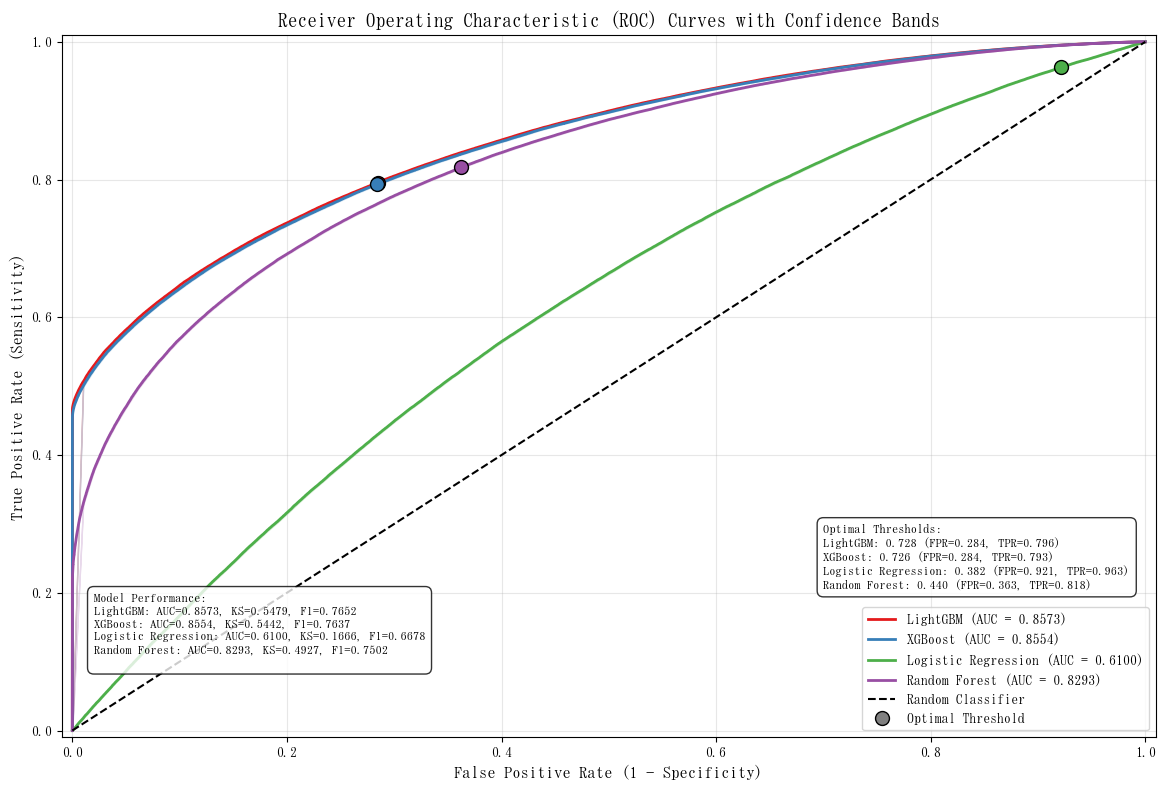

In [64]:
# 绘制增强的 ROC 曲线
plt = plot_roc_curves(all_results, y_train)
plt.savefig('enhanced_roc_curves.png', dpi=300)
plt.show()

## 4.8 查看结果+概率预测添加到processed_test数据集

In [65]:
results=lgb_results

In [66]:
# 查看results中的所有键
print("results中的键：")
print(results.keys())

# 查看训练集概率预测
print("\n训练集概率预测：")
print(results['train_prob'])

# 查看测试集概率预测
print("\n测试集概率预测：")
print(results['test_prob'])

# 查看训练集二进制预测
print("\n训练集二进制预测：")
print(results['train_binary'])

# 查看测试集二进制预测
print("\n测试集二进制预测：")
print(results['test_binary'])

# 查看性能指标
print("\n性能指标：")
print(f"AUC: {results['metrics']['auc']:.4f}")
print(f"KS: {results['metrics']['ks']:.4f}")
print(f"Recall: {results['metrics']['recall']:.4f}")
print(f"Precision: {results['metrics']['precision']:.4f}")
print(f"F1-score: {results['metrics']['f1']:.4f}")
print(f"Expected Gain: {results['metrics']['expected_gain']:.4f}")
print(f"Optimal Threshold: {results['metrics']['optimal_threshold']:.4f}")

results中的键：
dict_keys(['train_prob', 'test_prob', 'train_binary', 'test_binary', 'metrics'])

训练集概率预测：
[0.56027904 0.72075506 0.79186003 ... 0.82802387 0.73037031 0.68858461]

测试集概率预测：
[0.40209358 0.84115738 0.89010729 ... 0.67904204 0.69664931 0.22510741]

训练集二进制预测：
[0. 1. 1. ... 1. 0. 0.]

测试集二进制预测：
[0 1 1 ... 0 0 0]

性能指标：
AUC: 0.8573
KS: 0.5479
Recall: 0.7958
Precision: 0.7371
F1-score: 0.7652
Expected Gain: 61392.0000
Optimal Threshold: 0.7280


In [96]:
# 将测试集概率预测添加到processed_test数据集
processed_test['lgb_pred_prob'] = lgb_results['test_prob']

# 如果你也想保存二元预测结果
processed_test['lgb_pred_binary'] = lgb_results['test_binary']

# 查看添加了预测列的数据集
print(processed_test.head())

     dti  ficoRangeLow  homeOwnership  subGrade  verificationStatus  grade  \
0  10.56         715.0              0         8                   0      2   
1  21.40         670.0              0        15                   0      3   
2  33.50         710.0              1        19                   2      4   
3  13.95         685.0              0        14                   1      3   
4  24.97         685.0              1        16                   1      4   

   ficoRangeHigh  issueDateDT  term  installment  ...  annualIncome  \
0          719.0         2587     3       458.28  ...       80000.0   
1          674.0         2952     5       472.14  ...       50000.0   
2          714.0         3410     3       445.91  ...       60000.0   
3          689.0         2710     5       410.02  ...       37000.0   
4          689.0         3775     3      1249.42  ...       80000.0   

     debtpca1-1  accpca1-1    npca1-1   npca1-2   npca1-3  netprofit  \
0   -416.939774   5.790115   8.1

In [97]:
processed_test.to_csv('processed_test_with_predictions.csv', index=False)

# 4.3 lightGBM模型内可解释性

## 4.3.1 重新训练模型results，因为原来的模型中没有相关参数，所以需要重新练

In [67]:
# 调用 lgb_model 函数获取结果
results = lgb_model(x_train, y_train, x_test)

# 重新训练一个模型以获取特征重要性
train_matrix = lgb.Dataset(x_train, label=y_train)
params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': ['auc', 'accuracy'],  
    'min_child_weight': 5,
    'num_leaves': 10,
    'max_depth': 4,
    'lambda_l1': 10,
    'lambda_l2': 20,
    'scale_pos_weight': 4.33,
    'feature_fraction': 0.6,
    'bagging_fraction': 0.6,
    'bagging_freq': 5,
    'learning_rate': 0.02,
    'seed': 2020,
    'nthread': 28,
    'verbose': -1,
}

model = lgb.train(
    params,
    train_matrix,
    num_boost_round=1000  # 使用较少的轮数，只为了获取特征重要性
)

Beta (Negative/Positive ratio): 1.0000
************************************ 1 ************************************
Training until validation scores don't improve for 300 rounds
[200]	training's auc: 0.818484	valid_1's auc: 0.819025
[400]	training's auc: 0.84008	valid_1's auc: 0.840523
[600]	training's auc: 0.847283	valid_1's auc: 0.847458
[800]	training's auc: 0.851339	valid_1's auc: 0.851255
[1000]	training's auc: 0.853426	valid_1's auc: 0.853076
[1200]	training's auc: 0.854743	valid_1's auc: 0.854181
[1400]	training's auc: 0.855827	valid_1's auc: 0.855014
[1600]	training's auc: 0.856689	valid_1's auc: 0.855634
[1800]	training's auc: 0.857339	valid_1's auc: 0.856007
[2000]	training's auc: 0.857925	valid_1's auc: 0.856305
[2200]	training's auc: 0.858453	valid_1's auc: 0.856595
[2400]	training's auc: 0.858924	valid_1's auc: 0.856819
[2600]	training's auc: 0.859354	valid_1's auc: 0.856967
[2800]	training's auc: 0.859766	valid_1's auc: 0.857105
[3000]	training's auc: 0.860133	valid_1's au

## 4.3.2 获取split gain的特征重要性

In [68]:
# 获取不同类型的特征重要性
importance_gain = model.feature_importance(importance_type='gain')
importance_split = model.feature_importance(importance_type='split')

# 创建包含多种重要性指标的DataFrame
feature_importances = pd.DataFrame({
    'Feature': x_train.columns,
    'Gain': importance_gain,
    'Split': importance_split
})

# 按Gain排序
feature_importances_by_gain = feature_importances.sort_values('Gain', ascending=False)
print("\nLightGBM 特征重要性 (按Gain排序) Top 10:")
print(feature_importances_by_gain[['Feature', 'Gain', 'Split']].head(10))

# 按Split排序
feature_importances_by_split = feature_importances.sort_values('Split', ascending=False)
print("\nLightGBM 特征重要性 (按Split排序) Top 10:")
print(feature_importances_by_split[['Feature', 'Split', 'Gain']].head(10))

# 计算百分比形式的增益和分裂重要性
feature_importances['Gain_Percent'] = (feature_importances['Gain'] / feature_importances['Gain'].sum() * 100).round(2)
feature_importances['Split_Percent'] = (feature_importances['Split'] / feature_importances['Split'].sum() * 100).round(2)

# 打印百分比形式的重要性
print("\nLightGBM 特征重要性 (百分比形式) Top 10:")
feature_importances_percent = feature_importances.sort_values('Gain_Percent', ascending=False)
print(feature_importances_percent[['Feature', 'Gain_Percent', 'Split_Percent']].head(10))

# 也可以保存结果到CSV
feature_importances.to_csv('lgb_feature_importance_metrics.csv', index=False)


LightGBM 特征重要性 (按Gain排序) Top 10:
             Feature          Gain  Split
13               n14  1.833812e+06   1324
22  subGradetomeann4  1.248700e+06    567
11                n3  8.893111e+05    894
14      interestRate  6.470330e+05    305
8               term  3.988615e+05    433
7        issueDateDT  3.525646e+05   1115
1       ficoRangeLow  3.231298e+05    787
3           subGrade  2.832729e+05    267
5              grade  1.929680e+05    374
6      ficoRangeHigh  1.183622e+05    285

LightGBM 特征重要性 (按Split排序) Top 10:
             Feature  Split          Gain
13               n14   1324  1.833812e+06
7        issueDateDT   1115  3.525646e+05
11                n3    894  8.893111e+05
1       ficoRangeLow    787  3.231298e+05
22  subGradetomeann4    567  1.248700e+06
15      annualIncome    450  9.735255e+04
8               term    433  3.988615e+05
5              grade    374  1.929680e+05
2      homeOwnership    359  5.174493e+04
12          loanAmnt    346  5.551598e+04

LightG

In [69]:
# 获取特征重要性
feature_importances = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': model.feature_importance(importance_type='gain')  # 可以选择 'gain', 'split' 或 'weight'
}).sort_values('Importance', ascending=False)

print("\nLightGBM 特征重要性 Top 10:")
print(feature_importances.head(10))

# 也可以保存或可视化
# feature_importances.to_csv('lgb_feature_importance.csv', index=False)
# 可视化代码
# import matplotlib.pyplot as plt
# plt.figure(figsize=(10, 6))
# plt.barh(feature_importances['Feature'][:20], feature_importances['Importance'][:20])
# plt.xlabel('Importance')
# plt.title('LightGBM Feature Importance (Top 20)')
# plt.tight_layout()
# plt.savefig('lgb_feature_importance.png')


LightGBM 特征重要性 Top 10:
             Feature    Importance
13               n14  1.833812e+06
22  subGradetomeann4  1.248700e+06
11                n3  8.893111e+05
14      interestRate  6.470330e+05
8               term  3.988615e+05
7        issueDateDT  3.525646e+05
1       ficoRangeLow  3.231298e+05
3           subGrade  2.832729e+05
5              grade  1.929680e+05
6      ficoRangeHigh  1.183622e+05


In [70]:
# 获取特征重要性
feature_importances = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': model.feature_importance(importance_type='split')  # 可以选择 'gain', 'split' 或 'weight'
    
}).sort_values('Importance', ascending=False)

print("\nLightGBM 特征重要性 Top 10:")
print(feature_importances.head(10))



LightGBM 特征重要性 Top 10:
             Feature  Importance
13               n14        1324
7        issueDateDT        1115
11                n3         894
1       ficoRangeLow         787
22  subGradetomeann4         567
15      annualIncome         450
8               term         433
5              grade         374
2      homeOwnership         359
12          loanAmnt         346


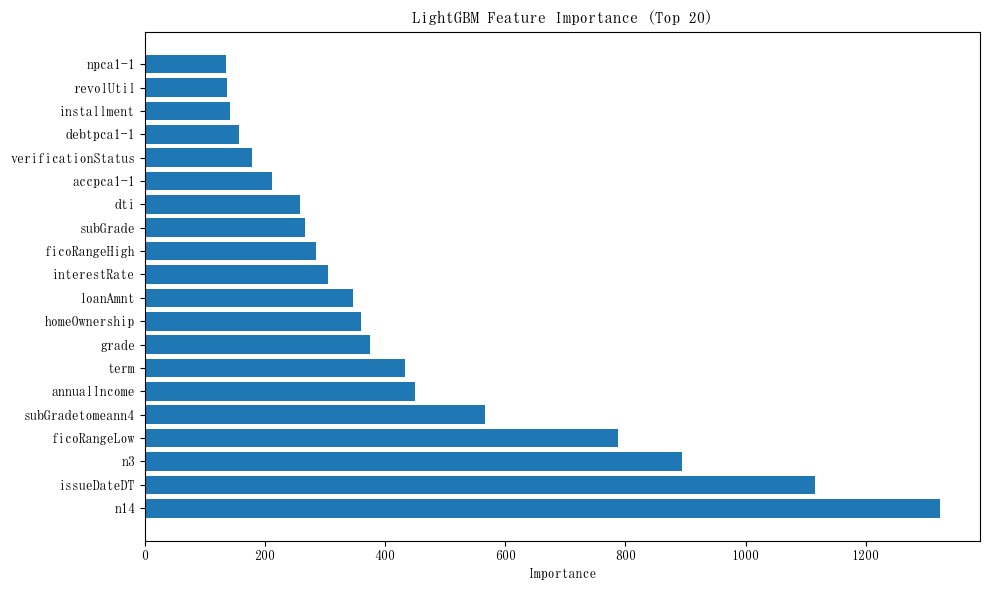

In [71]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'][:20], feature_importances['Importance'][:20])
plt.xlabel('Importance')
plt.title('LightGBM Feature Importance (Top 20)')
plt.tight_layout()
plt.savefig('lgb_feature_importance.png')

## 4.3.3 单颗树的可解释性

In [72]:
# 调用 lgb_model 函数获取结果
results = lgb_model(x_train, y_train, x_test)

# 重新训练一个模型，确保能够访问单棵树
train_matrix = lgb.Dataset(x_train, label=y_train)
params = {
    'boosting_type': 'gbdt',
    'objective': 'binary',
    'metric': ['auc', 'accuracy'],
    'min_child_weight': 5,
    'num_leaves': 10,
    'max_depth': 4,
    'lambda_l1': 10,
    'lambda_l2': 20,
    'scale_pos_weight': 4.33,
    'feature_fraction': 0.6,
    'bagging_fraction': 0.6,
    'bagging_freq': 5,
    'learning_rate': 0.02,
    'seed': 2020,
    'nthread': 28,
    'verbose': -1,
}


Beta (Negative/Positive ratio): 1.0000
************************************ 1 ************************************
Training until validation scores don't improve for 300 rounds
[200]	training's auc: 0.818484	valid_1's auc: 0.819025
[400]	training's auc: 0.84008	valid_1's auc: 0.840523
[600]	training's auc: 0.847283	valid_1's auc: 0.847458
[800]	training's auc: 0.851339	valid_1's auc: 0.851255
[1000]	training's auc: 0.853426	valid_1's auc: 0.853076
[1200]	training's auc: 0.854743	valid_1's auc: 0.854181
[1400]	training's auc: 0.855827	valid_1's auc: 0.855014
[1600]	training's auc: 0.856689	valid_1's auc: 0.855634
[1800]	training's auc: 0.857339	valid_1's auc: 0.856007
[2000]	training's auc: 0.857925	valid_1's auc: 0.856305
[2200]	training's auc: 0.858453	valid_1's auc: 0.856595
[2400]	training's auc: 0.858924	valid_1's auc: 0.856819
[2600]	training's auc: 0.859354	valid_1's auc: 0.856967
[2800]	training's auc: 0.859766	valid_1's auc: 0.857105
[3000]	training's auc: 0.860133	valid_1's au

In [73]:
model = lgb.train(
    params,
    train_matrix,
    num_boost_round=10  # 限制树的数量，方便提取单棵树
)

# 导出树结构（选择第0棵树）
tree_index = 4
tree_info = model.dump_model()['tree_info'][tree_index]
print(f"\n提取LightGBM模型中的第{tree_index+1}棵树结构:")

# 获取特征名称
feature_names = x_train.columns.tolist()

# 定义递归函数来打印树结构
def print_tree(tree, node_id=0, depth=0, condition="Root"):
    node = tree['tree_structure']
    
    # 如果有多个节点，递归找到目标节点
    if 'split_index' in node:
        if node_id > 0:
            for _ in range(node_id):
                if 'left_child' in node:
                    node = node['left_child']
                else:
                    return
    
    # 打印当前节点
    indent = "  " * depth
    if 'split_index' in node:
        feature_name = feature_names[node['split_feature']]
        threshold = node['threshold']
        gain = node['split_gain']
        print(f"{indent}{condition}: 特征[{feature_name}], 阈值[{threshold:.4f}], 增益[{gain:.4f}]")
        
        # 递归打印左子树和右子树
        print_tree({"tree_structure": node['left_child']}, 0, depth + 1, f"{feature_name} <= {threshold:.4f}")
        print_tree({"tree_structure": node['right_child']}, 0, depth + 1, f"{feature_name} > {threshold:.4f}")
    else:
        # 叶节点
        leaf_value = node['leaf_value']
        leaf_count = node.get('leaf_count', 'N/A')
        print(f"{indent}{condition}: 叶节点 - 预测值[{leaf_value:.6f}], 样本数[{leaf_count}]")

# 打印单棵树结构
print_tree({"tree_structure": tree_info['tree_structure']})

# 使用 LightGBM 自带的方法导出树结构到文件
import os
graph_file = "lightgbm_tree.txt"

# 创建文本形式的树结构
try:
    # 使用 LightGBM 的 create_tree_digraph 函数获取树的图结构
    tree_str = model.dump_model()['tree_info'][tree_index]['tree_structure']
    
    # 自己实现一个简单的树结构格式化输出
    with open(graph_file, 'w') as f:
        f.write(f"LightGBM 树结构 (Tree #{tree_index})\n")
        f.write("===========================================\n")
        
        def write_node(file, node, depth=0, path=""):
            indent = "  " * depth
            if 'split_index' in node:
                feature_name = feature_names[node['split_feature']]
                threshold = node['threshold']
                gain = node['split_gain']
                
                file.write(f"{indent}Node: {path}\n")
                file.write(f"{indent}|- 特征: {feature_name}\n")
                file.write(f"{indent}|- 阈值: {threshold:.4f}\n")
                file.write(f"{indent}|- 增益: {gain:.4f}\n")
                
                # 递归写入子节点
                write_node(file, node['left_child'], depth + 1, f"{path}L")
                write_node(file, node['right_child'], depth + 1, f"{path}R")
            else:
                file.write(f"{indent}叶节点: {path}\n")
                file.write(f"{indent}|- 预测值: {node['leaf_value']:.6f}\n")
                if 'leaf_count' in node:
                    file.write(f"{indent}|- 样本数: {node['leaf_count']}\n")
        
        write_node(f, tree_str)
    
    print(f"\n树结构已导出至 {graph_file}")
except Exception as e:
    print(f"导出树结构时出错: {e}")

# 提取单棵树的决策路径重要性
print("\n单棵树中的决策路径分析:")
def analyze_decision_paths(tree):
    feature_paths = {}
    
    def traverse(node, path=[]):
        if 'split_index' in node:
            feature_idx = node['split_feature']
            feature_name = feature_names[feature_idx]
            
            if feature_name not in feature_paths:
                feature_paths[feature_name] = {
                    'count': 0,
                    'total_gain': 0,
                    'paths': []
                }
            
            feature_paths[feature_name]['count'] += 1
            feature_paths[feature_name]['total_gain'] += node['split_gain']
            current_path = path + [(feature_name, node['threshold'], node['split_gain'])]
            feature_paths[feature_name]['paths'].append(current_path)
            
            traverse(node['left_child'], current_path)
            traverse(node['right_child'], current_path)
    
    traverse(tree['tree_structure'])
    return feature_paths

paths = analyze_decision_paths(tree_info)

# 打印每个特征在决策树中的使用情况
print("特征在单棵树中的影响:")
for feature, info in sorted(paths.items(), key=lambda x: x[1]['total_gain'], reverse=True):
    print(f"特征 '{feature}': 使用次数 {info['count']}, 总增益 {info['total_gain']:.4f}")
    
    # 打印该特征的一个示例决策路径
    if info['paths']:
        example_path = info['paths'][0]
        print("  示例决策路径:")
        for i, (feat, threshold, gain) in enumerate(example_path):
            print(f"    {'  '*i}步骤 {i+1}: 特征[{feat}], 阈值[{threshold:.4f}], 增益[{gain:.4f}]")
    print()

# 尝试使用matplotlib绘制树结构
try:
    import matplotlib.pyplot as plt
    import networkx as nx
    
    print("\n尝试使用NetworkX和Matplotlib绘制树结构...")
    
    # 创建有向图
    G = nx.DiGraph()
    
    # 递归添加节点和边
    def add_nodes_edges(G, node, node_id="0"):
        if 'split_index' in node:
            feature_name = feature_names[node['split_feature']]
            threshold = node['threshold']
            # 添加决策节点
            G.add_node(node_id, label=f"{feature_name}\n≤ {threshold:.2f}", shape="box", color="lightblue")
            
            # 添加左子树
            left_id = f"{node_id}L"
            add_nodes_edges(G, node['left_child'], left_id)
            G.add_edge(node_id, left_id, label="是")
            
            # 添加右子树
            right_id = f"{node_id}R"
            add_nodes_edges(G, node['right_child'], right_id)
            G.add_edge(node_id, right_id, label="否")
        else:
            # 添加叶节点
            G.add_node(node_id, label=f"预测值\n{node['leaf_value']:.4f}", shape="oval", color="lightgreen")
    
    add_nodes_edges(G, tree_info['tree_structure'])
    
    # 绘制树
    plt.figure(figsize=(15, 10))
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot") if hasattr(nx, 'nx_agraph') else nx.spring_layout(G)
    
    # 绘制节点
    node_colors = [G.nodes[n].get('color', 'lightblue') for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, alpha=0.8)
    
    # 添加节点标签
    node_labels = {n: G.nodes[n].get('label', n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)
    
    # 绘制边和边标签
    nx.draw_networkx_edges(G, pos, arrowsize=20)
    edge_labels = {(u, v): G.edges[u, v].get('label', '') for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    
    plt.axis('off')
    plt.tight_layout()
    plt.savefig("lightgbm_tree_graph.png")
    print("树结构图形已保存为 lightgbm_tree_graph.png")
except ImportError:
    print("提示: 安装 networkx 和 matplotlib 可以实现简单的图形化可视化")
    print("pip install networkx matplotlib")


提取LightGBM模型中的第5棵树结构:
Root: 特征[subGradetomeann4], 阈值[0.7029], 增益[38976.6016]
  subGradetomeann4 <= 0.7029: 特征[subGradetomeann4], 阈值[0.3539], 增益[7068.1899]
    subGradetomeann4 <= 0.3539: 叶节点 - 预测值[-0.008914], 样本数[29774]
    subGradetomeann4 > 0.3539: 特征[n14], 阈值[0.0000], 增益[1189.9800]
      n14 <= 0.0000: 叶节点 - 预测值[0.000655], 样本数[10992]
      n14 > 0.0000: 特征[n14], 阈值[0.9956], 增益[2194.6299]
        n14 <= 0.9956: 叶节点 - 预测值[0.037541], 样本数[1157]
        n14 > 0.9956: 叶节点 - 预测值[0.010445], 样本数[48615]
  subGradetomeann4 > 0.7029: 特征[subGradetomeann4], 阈值[1.0543], 增益[5044.7598]
    subGradetomeann4 <= 1.0543: 特征[n14], 阈值[0.0000], 增益[1237.1400]
      n14 <= 0.0000: 叶节点 - 预测值[0.012621], 样本数[11011]
      n14 > 0.0000: 特征[n14], 阈值[0.9956], 增益[1643.9100]
        n14 <= 0.9956: 叶节点 - 预测值[0.037181], 样本数[2755]
        n14 > 0.9956: 叶节点 - 预测值[0.021662], 样本数[73385]
    subGradetomeann4 > 1.0543: 特征[n14], 阈值[1.0000], 增益[1189.2300]
      n14 <= 1.0000: 叶节点 - 预测值[0.025383], 样本数[48108]
      n14 > 1.0000

<Figure size 1500x1000 with 0 Axes>

### 5.3.1 绘制单颗树结构为txt


尝试使用NetworkX和Matplotlib绘制树结构...
pygraphviz不可用或发生错误: No module named 'pygraphviz'
pydot不可用或发生错误: No module named 'pydot'
使用spring_layout作为替代
树结构图形已保存为 lightgbm_tree_graph.png


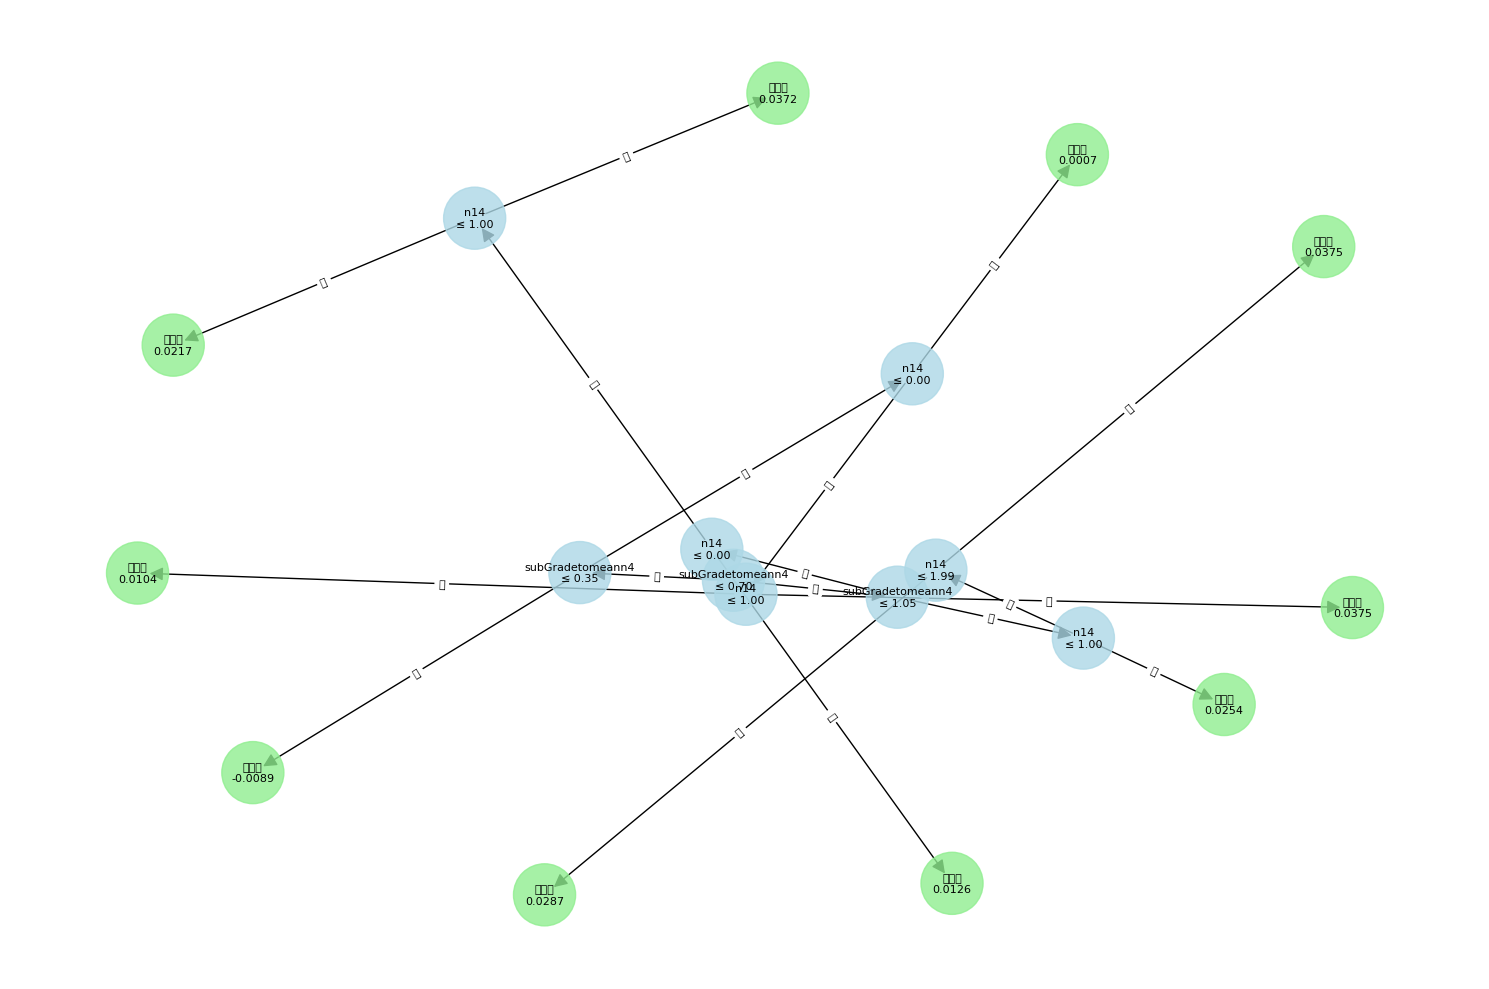

In [74]:
# 绘制树结构的部分改为这样
try:
    import matplotlib.pyplot as plt
    import networkx as nx
    
    print("\n尝试使用NetworkX和Matplotlib绘制树结构...")
    
    # 创建有向图
    G = nx.DiGraph()
    
    # 递归添加节点和边
    def add_nodes_edges(G, node, node_id="0"):
        if 'split_index' in node:
            feature_name = feature_names[node['split_feature']]
            threshold = node['threshold']
            # 添加决策节点
            G.add_node(node_id, label=f"{feature_name}\n≤ {threshold:.2f}", shape="box", color="lightblue")
            
            # 添加左子树
            left_id = f"{node_id}L"
            add_nodes_edges(G, node['left_child'], left_id)
            G.add_edge(node_id, left_id, label="是")
            
            # 添加右子树
            right_id = f"{node_id}R"
            add_nodes_edges(G, node['right_child'], right_id)
            G.add_edge(node_id, right_id, label="否")
        else:
            # 添加叶节点
            G.add_node(node_id, label=f"预测值\n{node['leaf_value']:.4f}", shape="oval", color="lightgreen")
    
    add_nodes_edges(G, tree_info['tree_structure'])
    
    # 绘制树 - 改用更可靠的布局算法
    plt.figure(figsize=(15, 10))
    
    # 首先尝试使用graphviz_layout，如果失败则回退到其他布局
    try:
        # 检查是否安装了pygraphviz
        import pygraphviz
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
    except (ImportError, Exception) as e:
        print(f"pygraphviz不可用或发生错误: {e}")
        # 尝试pydot
        try:
            import pydot
            pos = nx.drawing.nx_pydot.graphviz_layout(G, prog="dot")
        except (ImportError, Exception) as e:
            print(f"pydot不可用或发生错误: {e}")
            # 最后回退到spring_layout
            print("使用spring_layout作为替代")
            pos = nx.spring_layout(G, seed=42)
    
    # 绘制节点
    node_colors = [G.nodes[n].get('color', 'lightblue') for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, alpha=0.8)
    
    # 添加节点标签
    node_labels = {n: G.nodes[n].get('label', n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)
    
    # 绘制边和边标签
    nx.draw_networkx_edges(G, pos, arrowsize=20)
    edge_labels = {(u, v): G.edges[u, v].get('label', '') for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    
    plt.axis('off')
    plt.tight_layout()
    plt.savefig("lightgbm_tree_graph.png", dpi=300)
    print("树结构图形已保存为 lightgbm_tree_graph.png")

except Exception as e:
    print(f"绘制树结构图时出错: {e}")
    print("尝试使用LightGBM内置的可视化方法...")
    
    # 使用LightGBM的内置可视化方法作为备选
    try:
        import lightgbm as lgb
        
        # 使用LightGBM自带的可视化方法
        graph_file = "lightgbm_builtin_tree.png"
        lgb.plot_tree(model, tree_index=tree_index)
        plt.savefig(graph_file, dpi=300, bbox_inches='tight')
        print(f"使用LightGBM内置方法生成的树结构图已保存为 {graph_file}")
    except Exception as e:
        print(f"使用LightGBM内置可视化方法时出错: {e}")
        print("提示: 请确保安装了以下依赖:")
        print("pip install networkx matplotlib pygraphviz pydot pydotplus")
        print("对于pygraphviz，可能还需要安装系统级依赖graphviz")
        print("Ubuntu/Debian: sudo apt-get install graphviz graphviz-dev")
        print("CentOS/RHEL: sudo yum install graphviz graphviz-devel")
        print("MacOS: brew install graphviz")
        print("Windows: 从 https://graphviz.org/download/ 下载并安装")

In [75]:
import matplotlib
print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline


# 4.5 SHAP分析

# 4.5.0 跑模型，绘制条形+色阶图+力图，需要SHAP的特定参数，没有在原来的基础上进行修改。

In [179]:
results_lgb_2 = lgb_model(x_train, y_train, x_test)

Beta (Negative/Positive ratio): 1.0000
************************************ 1 ************************************
Training until validation scores don't improve for 300 rounds
[200]	training's auc: 0.818484	valid_1's auc: 0.819025
[400]	training's auc: 0.84008	valid_1's auc: 0.840523
[600]	training's auc: 0.847283	valid_1's auc: 0.847458
[800]	training's auc: 0.851339	valid_1's auc: 0.851255
[1000]	training's auc: 0.853426	valid_1's auc: 0.853076
[1200]	training's auc: 0.854743	valid_1's auc: 0.854181
[1400]	training's auc: 0.855827	valid_1's auc: 0.855014
[1600]	training's auc: 0.856689	valid_1's auc: 0.855634
[1800]	training's auc: 0.857339	valid_1's auc: 0.856007
[2000]	training's auc: 0.857925	valid_1's auc: 0.856305
[2200]	training's auc: 0.858453	valid_1's auc: 0.856595
[2400]	training's auc: 0.858924	valid_1's auc: 0.856819
[2600]	training's auc: 0.859354	valid_1's auc: 0.856967
[2800]	training's auc: 0.859766	valid_1's auc: 0.857105
[3000]	training's auc: 0.860133	valid_1's au

## 修改-但是结果不行

In [301]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# 保留原始的计算KS函数
def calculate_ks(y_true, y_pred_prob):
    """Calculate KS (Kolmogorov-Smirnov) statistic"""
    df = pd.DataFrame({'y_true': y_true, 'y_pred_prob': y_pred_prob})
    df = df.sort_values('y_pred_prob', ascending=False)
    
    df['y1'] = df['y_true'].cumsum() / df['y_true'].sum()
    df['y0'] = (1 - df['y_true']).cumsum() / (1 - df['y_true']).sum()
    
    ks = max(abs(df['y1'] - df['y0']))
    return ks

# 保留原始的计算期望增益函数
def calculate_expected_gain(y_true, y_pred, beta):
    """Calculate Expected Gain using the formula: TP*beta + TN - FP*beta - FN"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    expected_gain = tp * beta + tn - fp * beta - fn
    return expected_gain

# 保留原始的cv_model函数
def cv_model(clf, train_x, train_y, test_x, clf_name):
    # Calculate beta (ratio of negative to positive samples)
    beta = (len(train_y) - train_y.sum()) / train_y.sum()
    print(f"Beta (Negative/Positive ratio): {beta:.4f}")
    
    folds = 5
    seed = 2020
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
    train = np.zeros(train_x.shape[0])
    test = np.zeros(test_x.shape[0])

    # Metrics storage
    cv_scores_auc = []
    cv_scores_ks = []
    cv_scores_recall = []
    cv_scores_precision = []
    cv_scores_f1 = []
    cv_scores_exp_gain = []
    cv_scores_accuracy = []  # Added for accuracy
    
    # For storing predictions at optimal threshold
    train_binary = np.zeros(train_x.shape[0])
    test_binary = np.zeros(test_x.shape[0])
    optimal_thresholds = []
    
    # 保存所有fold的模型
    models = []
    
    for i, (train_index, valid_index) in enumerate(kf.split(train_x, train_y)):
        print('************************************ {} ************************************'.format(str(i+1)))
        
        trn_x, trn_y = train_x.iloc[train_index], train_y.iloc[train_index]
        val_x, val_y = train_x.iloc[valid_index], train_y.iloc[valid_index]
        
        if clf_name == "lgb":
            train_matrix = clf.Dataset(trn_x, label=trn_y)
            valid_matrix = clf.Dataset(val_x, label=val_y)
        
            params = {
                'boosting_type': 'gbdt',
                'objective': 'binary',
                'metric': ['auc', 'accuracy'],  # 重点关注 accuracy
                'min_child_weight': 5,  # 适当降低，使模型更关注小样本
                'num_leaves': 10,  # 适当减少叶子节点，防止过拟合
                'max_depth': 4,  # 限制最大深度
                'lambda_l1': 10,  # 增强 L1 正则化，减少噪声影响
                'lambda_l2': 20,  # 增强 L2 正则化
                'scale_pos_weight': 4.33,  # 调整类别权重
                'feature_fraction': 0.6,  # 降低特征子采样率，提高泛化能力
                'bagging_fraction': 0.6,
                'bagging_freq': 5,
                'learning_rate': 0.02,  # 降低学习率，提高训练稳定性
                'seed': 2020,
                'nthread': 28,
                'verbose': -1,
            }
        
            callbacks = [
                lgb.log_evaluation(period=200),
                lgb.early_stopping(stopping_rounds=300)
            ]
        
            model = clf.train(
                params,
                train_matrix,
                num_boost_round=20000,
                valid_sets=[train_matrix, valid_matrix],
                callbacks=callbacks
            )
            
            # 保存模型
            models.append(model)
        
            val_pred = model.predict(val_x)
            test_pred = model.predict(test_x)
            # 预测并转换为 0/1 标签
            threshold = 0.5  # 可以尝试 0.45~0.55 进行调优
            val_pred_labels = (val_pred > threshold).astype(int)
            test_pred_labels = (test_pred > threshold).astype(int)

        # Store probability predictions
        train[valid_index] = val_pred
        test += test_pred / kf.n_splits
        
        # Calculate metrics
        # 1. AUC
        auc_score = roc_auc_score(val_y, val_pred)
        cv_scores_auc.append(auc_score)
        
        # 2. KS
        ks_score = calculate_ks(val_y, val_pred)
        cv_scores_ks.append(ks_score)
        
        # Find optimal threshold for binary classification
        # Optimize for F1 score
        thresholds = np.arange(0.1, 0.9, 0.01)
        best_f1 = 0
        best_threshold = 0.5
        
        for threshold in thresholds:
            val_pred_binary = (val_pred >= threshold).astype(int)
            current_f1 = f1_score(val_y, val_pred_binary)
            if current_f1 > best_f1:
                best_f1 = current_f1
                best_threshold = threshold
        
        optimal_thresholds.append(best_threshold)
        
        # Apply optimal threshold
        val_pred_binary = (val_pred >= best_threshold).astype(int)
        test_pred_binary = (test_pred >= best_threshold).astype(int)
        
        # Store binary predictions
        train_binary[valid_index] = val_pred_binary
        test_binary += test_pred_binary / kf.n_splits
        
        # 3. Recall
        recall = recall_score(val_y, val_pred_binary)
        cv_scores_recall.append(recall)
        
        # 4. Precision
        precision = precision_score(val_y, val_pred_binary)
        cv_scores_precision.append(precision)
        
        # 5. F1 Score
        f1 = f1_score(val_y, val_pred_binary)
        cv_scores_f1.append(f1)
        
        # 6. Expected Gain
        exp_gain = calculate_expected_gain(val_y, val_pred_binary, beta)
        cv_scores_exp_gain.append(exp_gain)
        
        # 7. Accuracy - Added new metric calculation
        accuracy = accuracy_score(val_y, val_pred_binary)
        cv_scores_accuracy.append(accuracy)
        
        # Print all metrics for this fold
        print(f"Fold {i+1} Results:")
        print(f"  - AUC: {auc_score:.4f}")
        print(f"  - KS: {ks_score:.4f}")
        print(f"  - Optimal Threshold: {best_threshold:.4f}")
        print(f"  - Recall: {recall:.4f}")
        print(f"  - Precision: {precision:.4f}")
        print(f"  - F1 Score: {f1:.4f}")
        print(f"  - Expected Gain: {exp_gain:.4f}")
        print(f"  - Accuracy: {accuracy:.4f}")  # Added accuracy output
        
    # Calculate final thresholded test predictions
    test_binary_final = (test >= np.mean(optimal_thresholds)).astype(int)
    
    # Print overall CV statistics
    print("\n=== Overall Cross-Validation Results ===")
    print(f"{clf_name}_AUC_list:", cv_scores_auc)
    print(f"{clf_name}_AUC_mean: {np.mean(cv_scores_auc):.4f} (±{np.std(cv_scores_auc):.4f})")
    
    print(f"{clf_name}_KS_list:", cv_scores_ks)
    print(f"{clf_name}_KS_mean: {np.mean(cv_scores_ks):.4f} (±{np.std(cv_scores_ks):.4f})")
    
    print(f"{clf_name}_Recall_list:", cv_scores_recall)
    print(f"{clf_name}_Recall_mean: {np.mean(cv_scores_recall):.4f} (±{np.std(cv_scores_recall):.4f})")
    
    print(f"{clf_name}_Precision_list:", cv_scores_precision)
    print(f"{clf_name}_Precision_mean: {np.mean(cv_scores_precision):.4f} (±{np.std(cv_scores_precision):.4f})")
    
    print(f"{clf_name}_F1_list:", cv_scores_f1)
    print(f"{clf_name}_F1_mean: {np.mean(cv_scores_f1):.4f} (±{np.std(cv_scores_f1):.4f})")
    
    print(f"{clf_name}_ExpectedGain_list:", cv_scores_exp_gain)
    print(f"{clf_name}_ExpectedGain_mean: {np.mean(cv_scores_exp_gain):.4f} (±{np.std(cv_scores_exp_gain):.4f})")
    
    # Added accuracy reporting
    print(f"{clf_name}_Accuracy_list:", cv_scores_accuracy)
    print(f"{clf_name}_Accuracy_mean: {np.mean(cv_scores_accuracy):.4f} (±{np.std(cv_scores_accuracy):.4f})")
    
    print(f"Average optimal threshold: {np.mean(optimal_thresholds):.4f}")
    
    # Return both probability and binary predictions along with models
    return {
        'train_prob': train, 
        'test_prob': test,
        'train_binary': train_binary,
        'test_binary': test_binary_final,
        'metrics': {
            'auc': np.mean(cv_scores_auc),
            'ks': np.mean(cv_scores_ks),
            'recall': np.mean(cv_scores_recall),
            'precision': np.mean(cv_scores_precision),
            'f1': np.mean(cv_scores_f1),
            'expected_gain': np.mean(cv_scores_exp_gain),
            'accuracy': np.mean(cv_scores_accuracy),  # Added accuracy to metrics dictionary
            'optimal_threshold': np.mean(optimal_thresholds)
        },
        'models': models  # 返回所有fold的模型
    }

def lgb_model(x_train, y_train, x_test):
    return cv_model(lgb, x_train, y_train, x_test, "lgb")

# 主函数：训练模型并进行SHAP分析
def train_and_analyze_with_shap(x_train, y_train, x_test):
    # 1. 训练与之前代码相同的LightGBM模型
    print("训练LightGBM模型...")
    lgb_results = lgb_model(x_train, y_train, x_test)
    
    # 2. 解决预测值不一致问题
    # 原因：SHAP默认使用模型的predict函数，但是这个函数对于不同模型可能有不同的行为
    # 解决方案：明确指定预测类型和数据转换
    
    # 选择第一个fold的模型用于SHAP分析
    model = lgb_results['models'][0]
    
    # 选择部分样本进行SHAP分析（为了可视化效果更好）
    sample_size = min(500, len(x_train))
    x_sample = x_train.sample(sample_size, random_state=42)
    
    print("创建SHAP解释器...")
    # 为LightGBM模型创建SHAP解释器
    explainer = shap.TreeExplainer(model)
    
    print("计算SHAP值...")
    # 计算SHAP值
    shap_values = explainer.shap_values(x_sample)
    
    # 如果shap_values是一个列表（多分类情况），取第1个元素（正类的结果）
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # 对于二分类问题，[1]对应正类
    
    # 为确保预测值的一致性，使用与训练时相同的方法进行预测
    sample_preds = model.predict(x_sample)
    
    # 3. 绘制SHAP图
    print("绘制SHAP图表...")
    
    # 设置图表显示的样式和大小
    plt.figure(figsize=(12, 8))
    
    # (a) 特征重要性条形图
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, x_sample, plot_type="bar", show=False)
    plt.title('SHAP特征重要性（条形图）', fontsize=15)
    plt.tight_layout()
    plt.savefig('shap_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # (b) 特征重要性色阶图
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, x_sample, show=False)
    plt.title('SHAP特征重要性（色阶图）', fontsize=15)
    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # (c) SHAP力图 - 选择前10个样本展示
    plt.figure(figsize=(20, 12))
    shap.force_plot(
        explainer.expected_value, 
        shap_values[:10,:], 
        x_sample.iloc[:10,:],
        show=False,
        matplotlib=True
    )
    plt.title('SHAP力图（前10个样本）', fontsize=15)
    plt.tight_layout()
    plt.savefig('shap_force_plot.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # 比较SHAP预测值和模型实际预测值
    expected_value = explainer.expected_value
    if isinstance(expected_value, list):
        expected_value = expected_value[1]  # 针对二分类问题
    
    # 计算SHAP预测值
    shap_preds = expected_value + shap_values.sum(axis=1)
    
    # 转换为概率（因为SHAP使用logit空间）
    if model.params.get('objective') == 'binary':
        # 如果是二分类问题，需要转换logit到概率
        shap_preds = 1 / (1 + np.exp(-shap_preds))
    
    # 打印预测值比较
    print("\n预测值比较（前10个样本）:")
    comparison = pd.DataFrame({
        'SHAP预测值': shap_preds[:10],
        '模型预测值': sample_preds[:10],
        '差异': shap_preds[:10] - sample_preds[:10]
    })
    print(comparison)
    
    # 4. 返回结果
    return {
        'lgb_results': lgb_results,
        'explainer': explainer,
        'shap_values': shap_values,
        'x_sample': x_sample,
        'model_predictions': sample_preds,
        'shap_predictions': shap_preds
    }

# 示例使用方法（需要定义x_train, y_train, x_test）
# features = [f for f in processed_train.columns if f != 'isDefault']
# x_train = processed_train[features]
# x_test = processed_test[features]
# y_train = processed_train['isDefault']
# 
# # 运行模型训练和SHAP分析
# results = train_and_analyze_with_shap(x_train, y_train, x_test)
# 
# # 获取LightGBM结果
# lgb_results = results['lgb_results']
# 
# # 输出模型性能指标
# print(f"\nLightGBM最终性能指标:")
# print(f"AUC: {lgb_results['metrics']['auc']:.4f}")
# print(f"KS: {lgb_results['metrics']['ks']:.4f}")
# print(f"F1: {lgb_results['metrics']['f1']:.4f}")
# print(f"Accuracy: {lgb_results['metrics']['accuracy']:.4f}")

In [302]:
def analyze_with_shap(x_train, y_train, lgb_results, sample_indices=None, sample_size=500):
    """
    Analyze model with SHAP values and generate visualizations
    
    Parameters:
    -----------
    x_train : DataFrame
        Training features
    y_train : Series
        Target variable
    lgb_results : dict
        Results from LightGBM model training including models
    sample_indices : list, optional
        List of specific sample indices to analyze. If None, random samples will be used.
    sample_size : int, default=500
        Number of random samples to use if sample_indices is None
        
    Returns:
    --------
    dict : Dictionary with SHAP analysis results
    """
    print("开始SHAP分析...")
    
    # 选择第一个fold的模型用于SHAP分析
    model = lgb_results['models'][0]
    
    # 处理样本选择：用户自定义样本或随机样本
    if sample_indices is not None:
        # 使用用户指定的样本索引
        x_sample = x_train.iloc[sample_indices]
        print(f"使用用户指定的 {len(sample_indices)} 个样本进行SHAP分析")
    else:
        # 选择随机样本
        sample_size = min(sample_size, len(x_train))
        x_sample = x_train.sample(sample_size, random_state=42)
        print(f"随机选择 {sample_size} 个样本进行SHAP分析")
    
    print("创建SHAP解释器...")
    # 为LightGBM模型创建SHAP解释器
    explainer = shap.TreeExplainer(model)
    
    print("计算SHAP值...")
    # 计算SHAP值
    shap_values = explainer.shap_values(x_sample)
    
    # 确保我们有正确的SHAP值格式
    if isinstance(shap_values, list):
        # 对于二分类问题，[1]对应正类
        shap_values_pos = shap_values[1]  
        expected_value = explainer.expected_value
        if isinstance(expected_value, list):
            expected_value = expected_value[1]
    else:
        # 单类输出情况
        shap_values_pos = shap_values
        expected_value = explainer.expected_value
    
    # 使用模型直接预测（确保是概率值）
    sample_preds = model.predict(x_sample)
    
    # 创建图表保存目录
    if not os.path.exists('shap_plots'):
        os.makedirs('shap_plots')
    
    # 绘制SHAP图
    print("绘制SHAP图表...")
    
    # (a) 特征重要性条形图
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_pos, x_sample, plot_type="bar", show=False)
    plt.title('SHAP特征重要性（条形图）', fontsize=15)
    plt.tight_layout()
    plt.savefig('shap_plots/shap_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # (b) 特征重要性色阶图
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values_pos, x_sample, show=False)
    plt.title('SHAP特征重要性（色阶图）', fontsize=15)
    plt.tight_layout()
    plt.savefig('shap_plots/shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # (c) 针对具体样本的力图 - 支持自定义索引
    if sample_indices is not None:
        # 为用户指定的每个样本生成力图
        for i, idx in enumerate(range(len(x_sample))):
            plt.figure(figsize=(20, 3))
            shap.force_plot(
                expected_value,
                shap_values_pos[idx:idx+1,:], 
                x_sample.iloc[idx:idx+1,:],
                show=False,
                matplotlib=True
            )
            orig_idx = sample_indices[i] if i < len(sample_indices) else idx
            plt.title(f'SHAP力图（样本索引 {orig_idx}）', fontsize=15)
            plt.tight_layout()
            plt.savefig(f'shap_plots/shap_force_plot_sample_{orig_idx}.png', dpi=300, bbox_inches='tight')
            plt.close()
    else:
        # 随机样本的前几个
        for i in range(min(5, len(x_sample))):
            plt.figure(figsize=(20, 3))
            shap.force_plot(
                expected_value,
                shap_values_pos[i:i+1,:], 
                x_sample.iloc[i:i+1,:],
                show=False,
                matplotlib=True
            )
            plt.title(f'SHAP力图（样本 {i+1}）', fontsize=15)
            plt.tight_layout()
            plt.savefig(f'shap_plots/shap_force_plot_sample_{i+1}.png', dpi=300, bbox_inches='tight')
            plt.close()
    
    # 计算SHAP预测值并确保它们是概率值（0-1范围）
    shap_preds = expected_value + shap_values_pos.sum(axis=1)
    
    # 转换为概率（因为SHAP使用logit空间）
    if model.params.get('objective') == 'binary':
        # 如果是二分类问题，需要转换logit到概率
        shap_preds = 1 / (1 + np.exp(-shap_preds))
    
    # 确保预测值在0-1之间（概率范围）
    shap_preds = np.clip(shap_preds, 0, 1)
    sample_preds = np.clip(sample_preds, 0, 1)
    
    # 打印预测值比较
    print("\n预测值比较（前10个样本）:")
    comparison = pd.DataFrame({
        '样本索引': sample_indices[:10] if sample_indices is not None else range(10),
        'SHAP预测值': shap_preds[:10],
        '模型预测值': sample_preds[:10],
        '差异': shap_preds[:10] - sample_preds[:10]
    })
    print(comparison)
    
    # 保存预测值比较
    comparison.to_csv('shap_plots/prediction_comparison.csv')
    
    # 返回结果
    return {
        'explainer': explainer,
        'shap_values': shap_values_pos,
        'x_sample': x_sample,
        'model_predictions': sample_preds,
        'shap_predictions': shap_preds
    }

In [303]:
# 使用方法示例：
# 1. 先运行LightGBM模型
lgb_results = lgb_model(x_train, y_train, x_test)

# 2. 指定具体样本索引进行SHAP分析
# 例如，分析索引为0, 10, 50, 100, 200的样本
specific_samples = [0, 10, 50, 100, 200]
shap_results = analyze_with_shap(x_train, y_train, lgb_results, sample_indices=specific_samples)

# 或者自定义样本数量的随机抽样
# shap_results = analyze_with_shap(x_train, y_train, lgb_results, sample_size=300)

Beta (Negative/Positive ratio): 1.0000
************************************ 1 ************************************
Training until validation scores don't improve for 300 rounds
[200]	training's auc: 0.818484	valid_1's auc: 0.819025
[400]	training's auc: 0.84008	valid_1's auc: 0.840523
[600]	training's auc: 0.847283	valid_1's auc: 0.847458
[800]	training's auc: 0.851339	valid_1's auc: 0.851255
[1000]	training's auc: 0.853426	valid_1's auc: 0.853076
[1200]	training's auc: 0.854743	valid_1's auc: 0.854181
[1400]	training's auc: 0.855827	valid_1's auc: 0.855014
[1600]	training's auc: 0.856689	valid_1's auc: 0.855634
[1800]	training's auc: 0.857339	valid_1's auc: 0.856007
[2000]	training's auc: 0.857925	valid_1's auc: 0.856305
[2200]	training's auc: 0.858453	valid_1's auc: 0.856595
[2400]	training's auc: 0.858924	valid_1's auc: 0.856819
[2600]	training's auc: 0.859354	valid_1's auc: 0.856967
[2800]	training's auc: 0.859766	valid_1's auc: 0.857105
[3000]	training's auc: 0.860133	valid_1's au

## 第三次

In [168]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

# 保留原始的计算KS函数
def calculate_ks(y_true, y_pred_prob):
    """Calculate KS (Kolmogorov-Smirnov) statistic"""
    df = pd.DataFrame({'y_true': y_true, 'y_pred_prob': y_pred_prob})
    df = df.sort_values('y_pred_prob', ascending=False)
    
    df['y1'] = df['y_true'].cumsum() / df['y_true'].sum()
    df['y0'] = (1 - df['y_true']).cumsum() / (1 - df['y_true']).sum()
    
    ks = max(abs(df['y1'] - df['y0']))
    return ks

# 保留原始的计算期望增益函数
def calculate_expected_gain(y_true, y_pred, beta):
    """Calculate Expected Gain using the formula: TP*beta + TN - FP*beta - FN"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    expected_gain = tp * beta + tn - fp * beta - fn
    return expected_gain

# 保留原始的cv_model函数
def cv_model(clf, train_x, train_y, test_x, clf_name):
    # Calculate beta (ratio of negative to positive samples)
    beta = (len(train_y) - train_y.sum()) / train_y.sum()
    print(f"Beta (Negative/Positive ratio): {beta:.4f}")
    
    folds = 5
    seed = 2020
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
    train = np.zeros(train_x.shape[0])
    test = np.zeros(test_x.shape[0])

    # Metrics storage
    cv_scores_auc = []
    cv_scores_ks = []
    cv_scores_recall = []
    cv_scores_precision = []
    cv_scores_f1 = []
    cv_scores_exp_gain = []
    cv_scores_accuracy = []  # Added for accuracy
    
    # For storing predictions at optimal threshold
    train_binary = np.zeros(train_x.shape[0])
    test_binary = np.zeros(test_x.shape[0])
    optimal_thresholds = []
    
    # 保存所有fold的模型
    models = []
    
    for i, (train_index, valid_index) in enumerate(kf.split(train_x, train_y)):
        print('************************************ {} ************************************'.format(str(i+1)))
        
        trn_x, trn_y = train_x.iloc[train_index], train_y.iloc[train_index]
        val_x, val_y = train_x.iloc[valid_index], train_y.iloc[valid_index]
        
        if clf_name == "lgb":
            train_matrix = clf.Dataset(trn_x, label=trn_y)
            valid_matrix = clf.Dataset(val_x, label=val_y)
        
            params = {
                'boosting_type': 'gbdt',
                'objective': 'binary',
                'metric': ['auc', 'accuracy'],  # 重点关注 accuracy
                'min_child_weight': 5,  # 适当降低，使模型更关注小样本
                'num_leaves': 10,  # 适当减少叶子节点，防止过拟合
                'max_depth': 4,  # 限制最大深度
                'lambda_l1': 10,  # 增强 L1 正则化，减少噪声影响
                'lambda_l2': 20,  # 增强 L2 正则化
                'scale_pos_weight': 4.33,  # 调整类别权重
                'feature_fraction': 0.6,  # 降低特征子采样率，提高泛化能力
                'bagging_fraction': 0.6,
                'bagging_freq': 5,
                'learning_rate': 0.02,  # 降低学习率，提高训练稳定性
                'seed': 2020,
                'nthread': 28,
                'verbose': -1,
            }
        
            callbacks = [
                lgb.log_evaluation(period=200),
                lgb.early_stopping(stopping_rounds=300)
            ]
        
            model = clf.train(
                params,
                train_matrix,
                num_boost_round=20000,
                valid_sets=[train_matrix, valid_matrix],
                callbacks=callbacks
            )
            
            # 保存模型
            models.append(model)
        
            val_pred = model.predict(val_x)
            test_pred = model.predict(test_x)
            # 预测并转换为 0/1 标签
            threshold = 0.5  # 可以尝试 0.45~0.55 进行调优
            val_pred_labels = (val_pred > threshold).astype(int)
            test_pred_labels = (test_pred > threshold).astype(int)

        # Store probability predictions
        train[valid_index] = val_pred
        test += test_pred / kf.n_splits
        
        # Calculate metrics
        # 1. AUC
        auc_score = roc_auc_score(val_y, val_pred)
        cv_scores_auc.append(auc_score)
        
        # 2. KS
        ks_score = calculate_ks(val_y, val_pred)
        cv_scores_ks.append(ks_score)
        
        # Find optimal threshold for binary classification
        # Optimize for F1 score
        thresholds = np.arange(0.1, 0.9, 0.01)
        best_f1 = 0
        best_threshold = 0.5
        
        for threshold in thresholds:
            val_pred_binary = (val_pred >= threshold).astype(int)
            current_f1 = f1_score(val_y, val_pred_binary)
            if current_f1 > best_f1:
                best_f1 = current_f1
                best_threshold = threshold
        
        optimal_thresholds.append(best_threshold)
        
        # Apply optimal threshold
        val_pred_binary = (val_pred >= best_threshold).astype(int)
        test_pred_binary = (test_pred >= best_threshold).astype(int)
        
        # Store binary predictions
        train_binary[valid_index] = val_pred_binary
        test_binary += test_pred_binary / kf.n_splits
        
        # 3. Recall
        recall = recall_score(val_y, val_pred_binary)
        cv_scores_recall.append(recall)
        
        # 4. Precision
        precision = precision_score(val_y, val_pred_binary)
        cv_scores_precision.append(precision)
        
        # 5. F1 Score
        f1 = f1_score(val_y, val_pred_binary)
        cv_scores_f1.append(f1)
        
        # 6. Expected Gain
        exp_gain = calculate_expected_gain(val_y, val_pred_binary, beta)
        cv_scores_exp_gain.append(exp_gain)
        
        # 7. Accuracy - Added new metric calculation
        accuracy = accuracy_score(val_y, val_pred_binary)
        cv_scores_accuracy.append(accuracy)
        
        # Print all metrics for this fold
        print(f"Fold {i+1} Results:")
        print(f"  - AUC: {auc_score:.4f}")
        print(f"  - KS: {ks_score:.4f}")
        print(f"  - Optimal Threshold: {best_threshold:.4f}")
        print(f"  - Recall: {recall:.4f}")
        print(f"  - Precision: {precision:.4f}")
        print(f"  - F1 Score: {f1:.4f}")
        print(f"  - Expected Gain: {exp_gain:.4f}")
        print(f"  - Accuracy: {accuracy:.4f}")  # Added accuracy output
        
    # Calculate final thresholded test predictions
    test_binary_final = (test >= np.mean(optimal_thresholds)).astype(int)
    
    # Print overall CV statistics
    print("\n=== Overall Cross-Validation Results ===")
    print(f"{clf_name}_AUC_list:", cv_scores_auc)
    print(f"{clf_name}_AUC_mean: {np.mean(cv_scores_auc):.4f} (±{np.std(cv_scores_auc):.4f})")
    
    print(f"{clf_name}_KS_list:", cv_scores_ks)
    print(f"{clf_name}_KS_mean: {np.mean(cv_scores_ks):.4f} (±{np.std(cv_scores_ks):.4f})")
    
    print(f"{clf_name}_Recall_list:", cv_scores_recall)
    print(f"{clf_name}_Recall_mean: {np.mean(cv_scores_recall):.4f} (±{np.std(cv_scores_recall):.4f})")
    
    print(f"{clf_name}_Precision_list:", cv_scores_precision)
    print(f"{clf_name}_Precision_mean: {np.mean(cv_scores_precision):.4f} (±{np.std(cv_scores_precision):.4f})")
    
    print(f"{clf_name}_F1_list:", cv_scores_f1)
    print(f"{clf_name}_F1_mean: {np.mean(cv_scores_f1):.4f} (±{np.std(cv_scores_f1):.4f})")
    
    print(f"{clf_name}_ExpectedGain_list:", cv_scores_exp_gain)
    print(f"{clf_name}_ExpectedGain_mean: {np.mean(cv_scores_exp_gain):.4f} (±{np.std(cv_scores_exp_gain):.4f})")
    
    # Added accuracy reporting
    print(f"{clf_name}_Accuracy_list:", cv_scores_accuracy)
    print(f"{clf_name}_Accuracy_mean: {np.mean(cv_scores_accuracy):.4f} (±{np.std(cv_scores_accuracy):.4f})")
    
    print(f"Average optimal threshold: {np.mean(optimal_thresholds):.4f}")
    
    # Return both probability and binary predictions along with models
    return {
        'train_prob': train, 
        'test_prob': test,
        'train_binary': train_binary,
        'test_binary': test_binary_final,
        'metrics': {
            'auc': np.mean(cv_scores_auc),
            'ks': np.mean(cv_scores_ks),
            'recall': np.mean(cv_scores_recall),
            'precision': np.mean(cv_scores_precision),
            'f1': np.mean(cv_scores_f1),
            'expected_gain': np.mean(cv_scores_exp_gain),
            'accuracy': np.mean(cv_scores_accuracy),  # Added accuracy to metrics dictionary
            'optimal_threshold': np.mean(optimal_thresholds)
        },
        'models': models  # 返回所有fold的模型
    }

def lgb_model(x_train, y_train, x_test):
    result = cv_model(lgb, x_train, y_train, x_test, "lgb")
    
    # 创建模型保存目录
    if not os.path.exists('saved_models'):
        os.makedirs('saved_models')
        
    # 保存所有fold的模型
    for i, model in enumerate(result['models']):
        model_path = f"saved_models/lgb_model_fold_{i+1}.txt"
        model.save_model(model_path)
        print(f"保存模型到: {model_path}")
    
    # 保存整体结果
    metrics_path = "saved_models/lgb_metrics.joblib"
    joblib.dump(result['metrics'], metrics_path)
    print(f"保存指标到: {metrics_path}")
    
    return result

# 分析SHAP值并生成图表函数
def analyze_with_shap(x_train, y_train, lgb_results):
    print("开始SHAP分析...")
    
    # 选择第一个fold的模型用于SHAP分析
    model = lgb_results['models'][0]
    
    # 选择部分样本进行SHAP分析（为了可视化效果更好）
    sample_size = min(500, len(x_train))
    x_sample = x_train.sample(sample_size, random_state=42)
    
    print("创建SHAP解释器...")
    # 为LightGBM模型创建SHAP解释器
    explainer = shap.TreeExplainer(model)
    
    print("计算SHAP值...")
    # 计算SHAP值
    shap_values = explainer.shap_values(x_sample)
    
    # 如果shap_values是一个列表（多分类情况），取第1个元素（正类的结果）
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # 对于二分类问题，[1]对应正类
    
    # 为确保预测值的一致性，使用与训练时相同的方法进行预测
    sample_preds = model.predict(x_sample)
    
    # 创建图表保存目录
    if not os.path.exists('shap_plots'):
        os.makedirs('shap_plots')
    
    # 3. 绘制SHAP图
    print("绘制SHAP图表...")
    
    # (a) 特征重要性条形图
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, x_sample, plot_type="bar", show=False)
    plt.title('SHAP特征重要性（条形图）', fontsize=15)
    plt.tight_layout()
    plt.savefig('shap_plots/shap_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # (b) 特征重要性色阶图
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, x_sample, show=False)
    plt.title('SHAP特征重要性（色阶图）', fontsize=15)
    plt.tight_layout()
    plt.savefig('shap_plots/shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    # (c) 修复原来的错误：一次只显示一个样本的力图
    for i in range(min(5, len(x_sample))):  # 显示前5个样本，每个单独绘制
        plt.figure(figsize=(20, 3))
        shap.force_plot(
            explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
            shap_values[i:i+1,:], 
            x_sample.iloc[i:i+1,:],
            show=False,
            matplotlib=True
        )
        plt.title(f'SHAP力图（样本 {i+1}）', fontsize=15)
        plt.tight_layout()
        plt.savefig(f'shap_plots/shap_force_plot_sample_{i+1}.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    # 比较SHAP预测值和模型实际预测值
    expected_value = explainer.expected_value
    if isinstance(expected_value, list):
        expected_value = expected_value[1]  # 针对二分类问题
    
    # 计算SHAP预测值
    shap_preds = expected_value + shap_values.sum(axis=1)
    
    # 转换为概率（因为SHAP使用logit空间）
    if model.params.get('objective') == 'binary':
        # 如果是二分类问题，需要转换logit到概率
        shap_preds = 1 / (1 + np.exp(-shap_preds))
    
    # 打印预测值比较
    print("\n预测值比较（前10个样本）:")
    comparison = pd.DataFrame({
        'SHAP预测值': shap_preds[:10],
        '模型预测值': sample_preds[:10],
        '差异': shap_preds[:10] - sample_preds[:10]
    })
    print(comparison)
    
    # 保存预测值比较
    comparison.to_csv('shap_plots/prediction_comparison.csv')
    
    # 4. 返回结果
    return {
        'explainer': explainer,
        'shap_values': shap_values,
        'x_sample': x_sample,
        'model_predictions': sample_preds,
        'shap_predictions': shap_preds
    }

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from fixed_model_code import lgb_model, analyze_with_shap

# 示例使用方法
def main():
    # 假设数据已经准备好
    # 请将下面的注释代码替换为您的实际数据处理代码
    # processed_train = ...
    # processed_test = ...
    
    # 定义特征和目标变量
    #features = [f for f in processed_train.columns if f != 'isDefault']
    #x_train = processed_train[features]
    #x_test = processed_test[features]
    #y_train = processed_train['isDefault']
    
    # 第一步：训练模型并保存
    print("训练LightGBM模型...")
    lgb_results = lgb_model(x_train, y_train, x_test)
    
    # 输出模型性能指标
    print(f"\nLightGBM最终性能指标:")
    print(f"AUC: {lgb_results['metrics']['auc']:.4f}")
    print(f"KS: {lgb_results['metrics']['ks']:.4f}")
    print(f"F1: {lgb_results['metrics']['f1']:.4f}")
    print(f"Accuracy: {lgb_results['metrics']['accuracy']:.4f}")
    
    # 第二步：对训练好的模型进行SHAP分析
    print("\n开始SHAP分析...")
    shap_results = analyze_with_shap(x_train, y_train, lgb_results)
    
    print("\nSHAP分析完成，图表已保存到'shap_plots'目录。")
    
    return lgb_results, shap_results

if __name__ == "__main__":
    lgb_results, shap_results = main()

训练LightGBM模型...
Beta (Negative/Positive ratio): 1.0000
************************************ 1 ************************************
Training until validation scores don't improve for 300 rounds
[200]	training's auc: 0.818484	valid_1's auc: 0.819025
[400]	training's auc: 0.84008	valid_1's auc: 0.840523
[600]	training's auc: 0.847283	valid_1's auc: 0.847458
[800]	training's auc: 0.851339	valid_1's auc: 0.851255
[1000]	training's auc: 0.853426	valid_1's auc: 0.853076
[1200]	training's auc: 0.854743	valid_1's auc: 0.854181
[1400]	training's auc: 0.855827	valid_1's auc: 0.855014
[1600]	training's auc: 0.856689	valid_1's auc: 0.855634
[1800]	training's auc: 0.857339	valid_1's auc: 0.856007
[2000]	training's auc: 0.857925	valid_1's auc: 0.856305
[2200]	training's auc: 0.858453	valid_1's auc: 0.856595
[2400]	training's auc: 0.858924	valid_1's auc: 0.856819
[2600]	training's auc: 0.859354	valid_1's auc: 0.856967
[2800]	training's auc: 0.859766	valid_1's auc: 0.857105
[3000]	training's auc: 0.860

## 第一次原始代码

In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb

# 假设您已经有了LightGBM模型的结果
# results = lgb_model(x_train, y_train, x_test)
# 以及训练数据 x_train, y_train 和测试数据 x_test

def shap_analysis_lgbm(model, x_train, x_test, feature_names=None):
    """
    对LightGBM模型进行SHAP值分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表，如果为None则使用x_train的列名
    
    返回:
    shap_values: 计算得到的SHAP值
    explainer: SHAP解释器对象
    """
    # 如果输入是pandas DataFrame，则获取特征名称
    if isinstance(x_train, pd.DataFrame):
        feature_names = x_train.columns.tolist()
        x_train_values = x_train.values
    else:
        x_train_values = x_train
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(x_train.shape[1])]
    
    # 创建SHAP解释器
    explainer = shap.TreeExplainer(model)
    
    # 计算SHAP值
    shap_values = explainer.shap_values(x_test)
    
    return shap_values, explainer, feature_names

def plot_shap_importance(shap_values, feature_names, top_n=5, title="特征重要性（基于SHAP值）", figsize=(12, 8)):
    """
    绘制基于SHAP值的特征重要性图，仅显示前top_n个特征
    
    参数:
    shap_values: SHAP值
    feature_names: 特征名称列表
    top_n: 要显示的最重要特征数量
    title: 图表标题
    figsize: 图表大小
    """
    plt.figure(figsize=figsize)
    
    # 对于二分类问题，shap_values可能是一个列表，包含两类的SHAP值（我们通常取正类的值）
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # 取正类的SHAP值
    
    # 计算每个特征的平均绝对SHAP值
    shap_importance = np.abs(shap_values).mean(axis=0)
    
    # 创建排序索引
    idx = np.argsort(shap_importance)[-top_n:]  # 仅获取前top_n个特征
    
    # 绘制条形图
    plt.barh(range(len(idx)), shap_importance[idx], align='center')
    plt.yticks(range(len(idx)), [feature_names[i] for i in idx])
    plt.title(f"{title} (Top {top_n})")
    plt.xlabel('平均|SHAP值|（特征对模型输出的影响程度）')
    plt.tight_layout()
    plt.savefig(f'shap_importance_top{top_n}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return shap_importance

def plot_shap_summary(shap_values, x_test, feature_names=None, max_display=5, figsize=(10, 8)):
    """
    绘制SHAP摘要图，展示每个特征的SHAP值分布，仅显示前max_display个特征
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_names: 特征名称列表
    max_display: 最多显示的特征数量
    figsize: 图表大小
    """
    plt.figure(figsize=figsize)
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换为数组
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        x_test = x_test.values
    
    # 绘制SHAP摘要图，仅显示前max_display个特征
    shap.summary_plot(shap_values, x_test, feature_names=feature_names, max_display=max_display, show=False)
    plt.title(f'SHAP值摘要图 (Top {max_display})')
    plt.tight_layout()
    plt.savefig(f'shap_summary_top{max_display}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_shap_dependence(shap_values, x_test, feature_idx, feature_names=None, interaction_index=None, figsize=(10, 6)):
    """
    绘制单变量SHAP值依赖图，展示特征值与SHAP值的关系
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_idx: 要分析的特征索引
    feature_names: 特征名称列表
    interaction_index: 交互特征的索引（用于展示交互效应）
    figsize: 图表大小
    """
    plt.figure(figsize=figsize)
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换特征索引为名称
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        if isinstance(feature_idx, str):
            feature_idx = feature_names.index(feature_idx)
        feature_name = feature_names[feature_idx]
        
        if interaction_index is not None:
            if isinstance(interaction_index, str):
                interaction_index = feature_names.index(interaction_index)
            interaction_name = feature_names[interaction_index]
        else:
            interaction_name = interaction_index
        x_test_values = x_test.values
    else:
        feature_name = f'Feature_{feature_idx}' if feature_names is None else feature_names[feature_idx]
        interaction_name = interaction_index
        x_test_values = x_test
    
    # 绘制依赖图
    shap.dependence_plot(feature_idx, shap_values, x_test_values, feature_names=feature_names, 
                         interaction_index=interaction_index, show=False)
    
    # 设置标题（带交互特征名称）
    if interaction_index is not None:
        interaction_name = feature_names[interaction_index] if isinstance(interaction_index, int) else interaction_index
        plt.title(f'特征 {feature_name} 与 {interaction_name} 的SHAP值交互依赖图')
        save_name = f'shap_dependence_{feature_name.replace(" ", "_")}_{interaction_name.replace(" ", "_")}.png'
    else:
        plt.title(f'特征 {feature_name} 的SHAP值依赖图')
        save_name = f'shap_dependence_{feature_name.replace(" ", "_")}.png'
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()

def plot_shap_single_prediction(explainer, x_test, sample_indices, feature_names=None, figsize=(10, 12)):
    """
    绘制多个样本的SHAP值解释图
    
    参数:
    explainer: SHAP解释器对象
    x_test: 测试数据特征
    sample_indices: 要分析的样本索引列表
    feature_names: 特征名称列表
    figsize: 图表大小
    """
    # 确保sample_indices是列表
    if not isinstance(sample_indices, list):
        sample_indices = [sample_indices]
    
    # 对每个样本绘制解释图
    for idx in sample_indices:
        plt.figure(figsize=figsize)
        
        # 获取单个样本
        if isinstance(x_test, pd.DataFrame):
            if feature_names is None:
                feature_names = x_test.columns.tolist()
            x_single = x_test.iloc[idx].values.reshape(1, -1)
        else:
            x_single = x_test[idx:idx+1]
            if feature_names is None:
                feature_names = [f'Feature_{i}' for i in range(x_test.shape[1])]
        
        # 计算SHAP值
        shap_values_single = explainer.shap_values(x_single)
        
        # 如果是二分类问题且shap_values是列表，取正类的SHAP值
        if isinstance(shap_values_single, list):
            shap_values_single = shap_values_single[1]
        
        # 绘制瀑布图
        expected_value = explainer.expected_value
        if isinstance(expected_value, list):
            expected_value = expected_value[1]
            
        shap.force_plot(expected_value, shap_values_single, x_single, 
                        feature_names=feature_names, matplotlib=True, show=False)
        plt.title(f'样本 {idx} 的SHAP值解释')
        plt.tight_layout()
        plt.savefig(f'shap_force_plot_sample_{idx}.png', dpi=300, bbox_inches='tight')
        plt.show()

def save_all_features_shap_values(shap_values, feature_names, output_file='feature_shap_values.csv'):
    """
    保存所有特征的绝对SHAP值总和到CSV
    
    参数:
    shap_values: SHAP值
    feature_names: 特征名称列表
    output_file: 输出的CSV文件名
    """
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
        
    # 计算每个特征的绝对SHAP值总和
    shap_abs_sum = np.abs(shap_values).sum(axis=0)
    
    # 计算相对重要性百分比
    total_impact = shap_abs_sum.sum()
    relative_importance = (shap_abs_sum / total_impact) * 100
    
    # 创建DataFrame并排序
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'abs_shap_sum': shap_abs_sum,
        'relative_importance_percent': relative_importance
    })
    
    # 按重要性降序排序
    shap_df = shap_df.sort_values('abs_shap_sum', ascending=False)
    
    # 保存到CSV
    shap_df.to_csv(output_file, index=False)
    print(f"所有特征的SHAP值总和已保存到 {output_file}")
    
    return shap_df

# 主函数：执行完整的SHAP分析
def main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=None):
    """
    执行完整的SHAP分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表
    sample_indices: 要分析的样本索引列表，如果为None则使用前3个样本
    """
    print("4.3 SHAP对LightGBM模型的分析")
    
    # 计算SHAP值
    shap_values, explainer, feature_names = shap_analysis_lgbm(model, x_train, x_test, feature_names)
    
    # 4.3.1 变量重要性分析 - 仅显示前5个特征
    print("\n4.3.1 变量重要性分析 (Top 9)")
    shap_importance = plot_shap_importance(shap_values, feature_names, top_n=10)
    
    # 4.3.2 单变量SHAP值的映射关系 - 仅显示前5个特征
    print("\n4.3.2 单变量SHAP值的映射关系 (Top 9)")
    plot_shap_summary(shap_values, x_test, feature_names, max_display=10)
    
    # 获取特征索引映射（用于交互图）
    feature_indices = {}
    for i, name in enumerate(feature_names):
        feature_indices[name] = i
    
    # 绘制特定的交互依赖图
    print("\n4.3.3 特定特征交互关系分析")
    
    # 1. interestRate与issueDateDT的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                             feature_idx="interestRate" if "interestRate" in feature_indices else feature_indices.get("interestRate", 0),
                             feature_names=feature_names, 
                             interaction_index="subGrade" if "subGrade" in feature_indices else feature_indices.get("subGrade", 1))
    except Exception as e:
        print(f"无法绘制interestRate与grade的交互图: {e}")
        print(f"可用的特征名称: {feature_names}")
    
    # 2. accpcal-1与subGrade的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                             feature_idx="accpcal-1" if "accpcal-1" in feature_indices else feature_indices.get("accpcal-1", 0),
                             feature_names=feature_names, 
                             interaction_index="subGrade" if "subGrade" in feature_indices else feature_indices.get("subGrade", 1))
    except Exception as e:
        print(f"无法绘制accpcal-1与subGrade的交互图: {e}")
    
    # 3. accpcal-1与n3的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                             feature_idx="accpcal-1" if "accpcal-1" in feature_indices else feature_indices.get("accpcal-1", 0),
                             feature_names=feature_names, 
                             interaction_index="n3" if "n3" in feature_indices else feature_indices.get("n3", 2))
    except Exception as e:
        print(f"无法绘制accpcal-1与n3的交互图: {e}")
    
    # 4.3.5 单个样本的SHAP值计算 - 允许自定义样本
    print("\n4.3.5 单个样本的SHAP值计算")
    if sample_indices is None:
        sample_indices = list(range(min(3, len(x_test))))
    
    plot_shap_single_prediction(explainer, x_test, sample_indices, feature_names)
    
    # 保存所有特征的SHAP值总和到CSV
    print("\n保存所有特征的SHAP值总和到CSV")
    shap_df = save_all_features_shap_values(shap_values, feature_names)
    
    return shap_values, explainer, shap_importance, shap_df

# 示例调用
# 自定义样本索引，例如查看样本0，5，10的SHAP值
# main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=[0, 5, 10])

In [184]:
results=results_lgb_2

4.3 SHAP对LightGBM模型的分析

4.3.1 变量重要性分析 (Top 9)


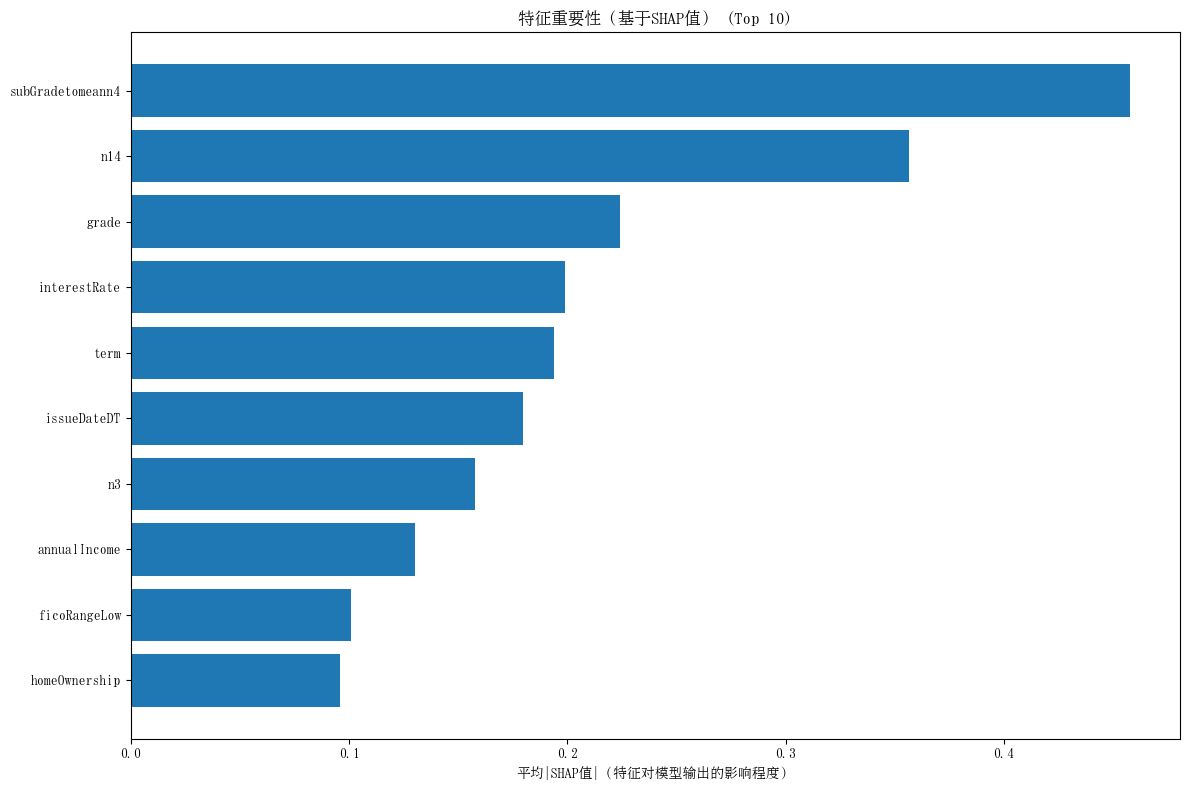


4.3.2 单变量SHAP值的映射关系 (Top 9)


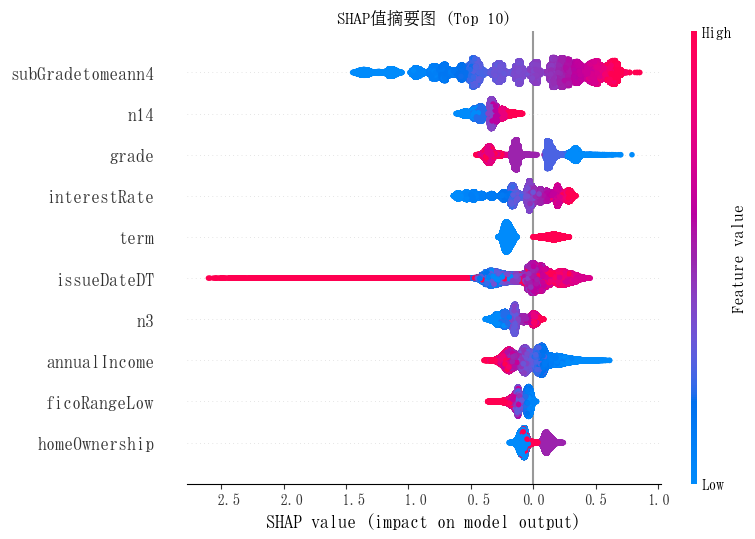


4.3.3 特定特征交互关系分析


<Figure size 1000x600 with 0 Axes>

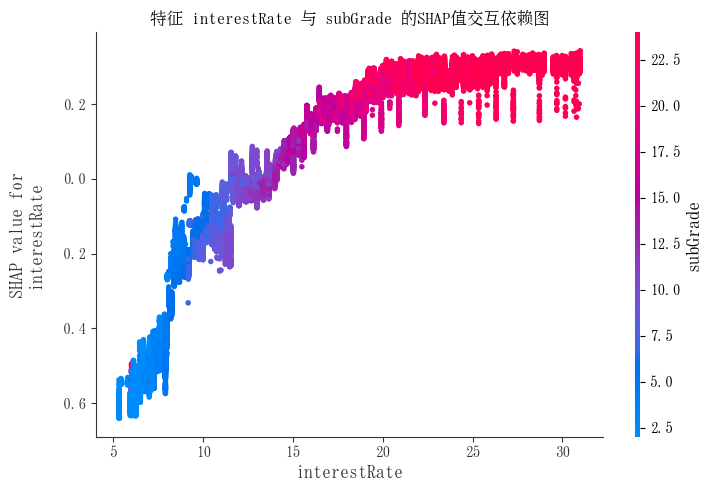

<Figure size 1000x600 with 0 Axes>

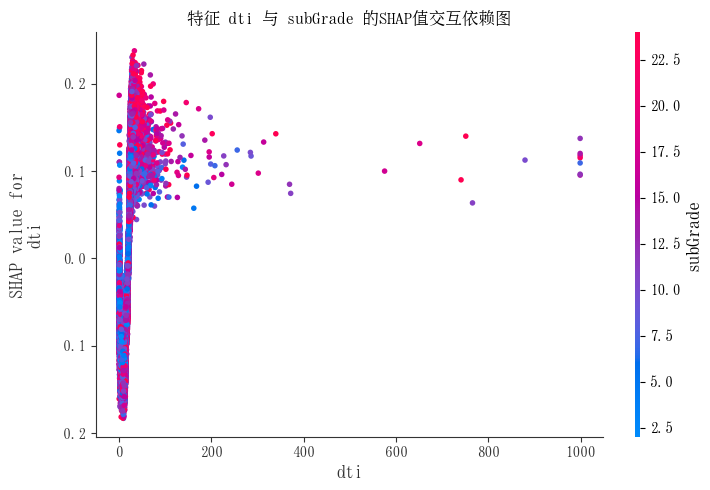

<Figure size 1000x600 with 0 Axes>

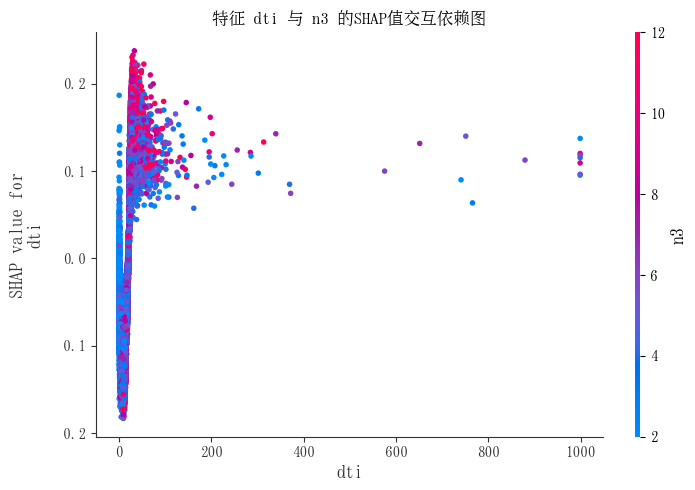


4.3.5 单个样本的SHAP值计算


<Figure size 1000x1200 with 0 Axes>

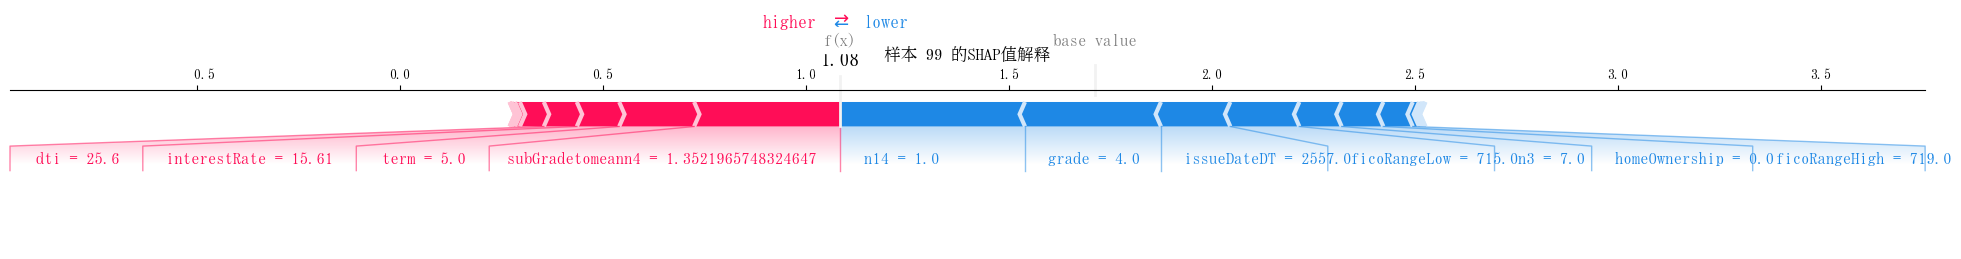

<Figure size 1000x1200 with 0 Axes>

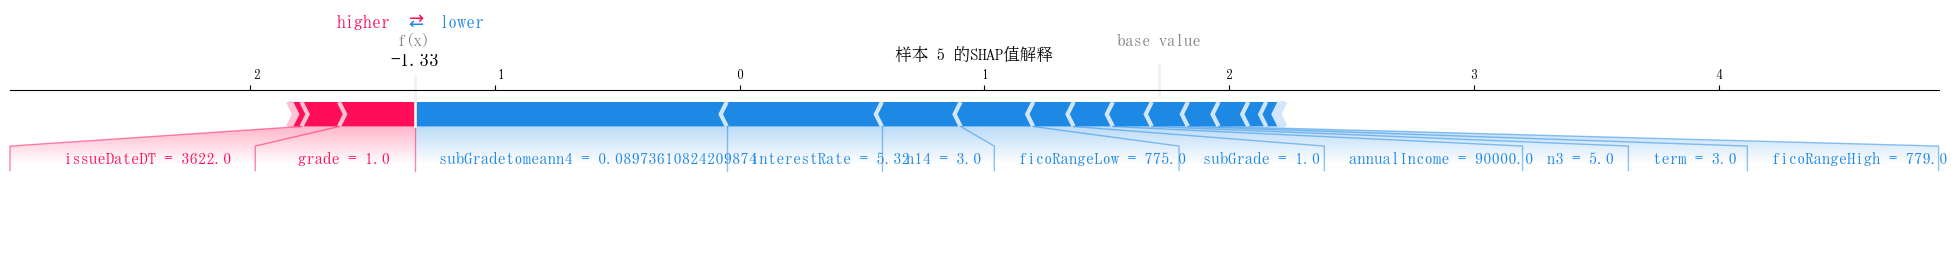

<Figure size 1000x1200 with 0 Axes>

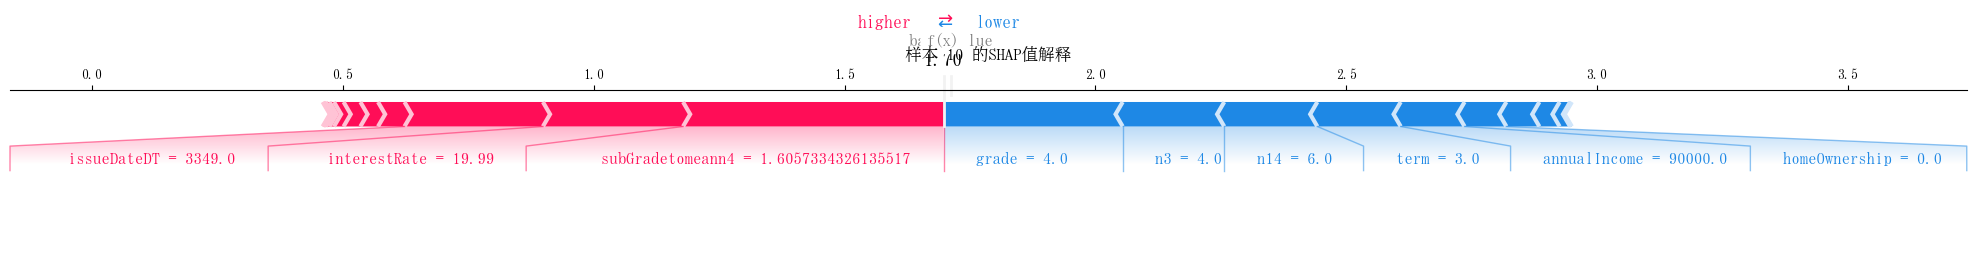

<Figure size 1000x1200 with 0 Axes>

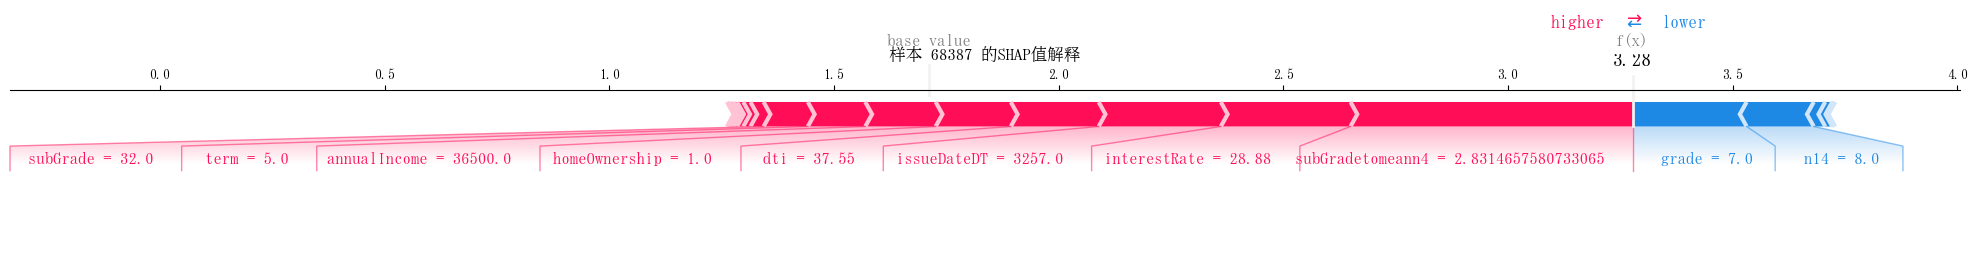

<Figure size 1000x1200 with 0 Axes>

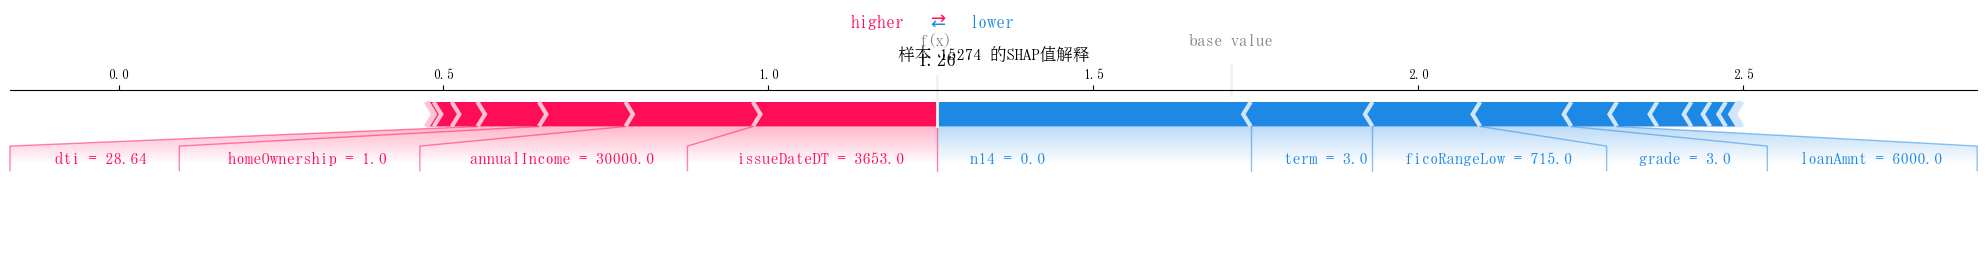

<Figure size 1000x1200 with 0 Axes>

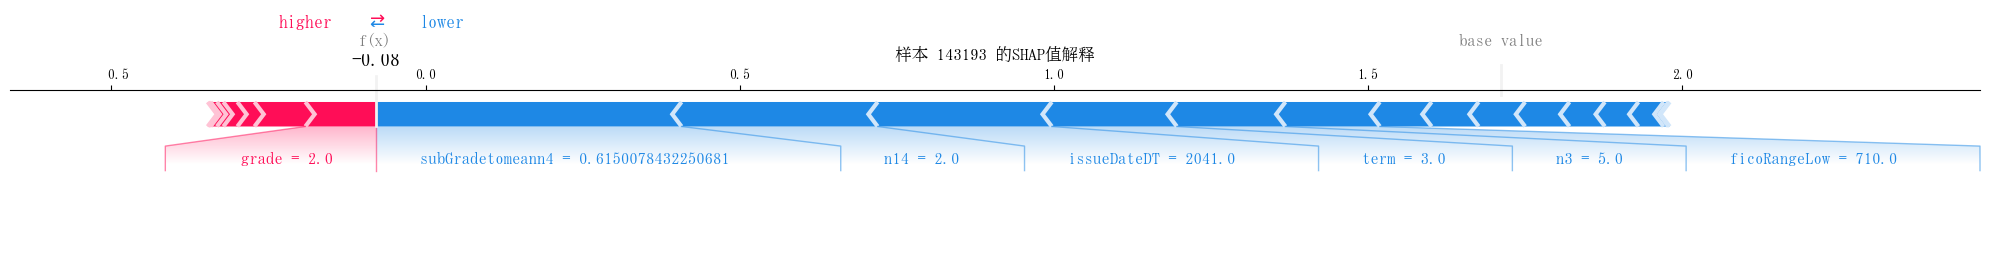

<Figure size 1000x1200 with 0 Axes>

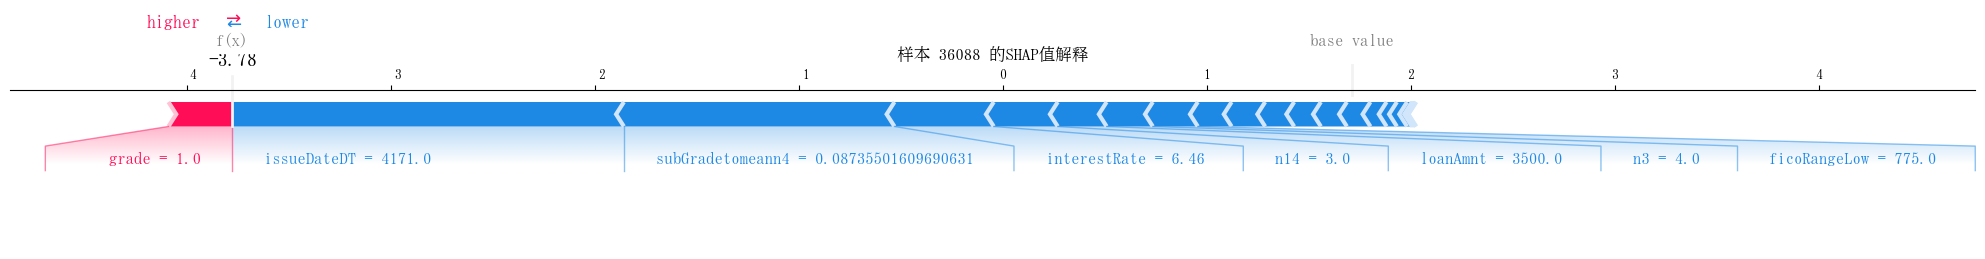

<Figure size 1000x1200 with 0 Axes>

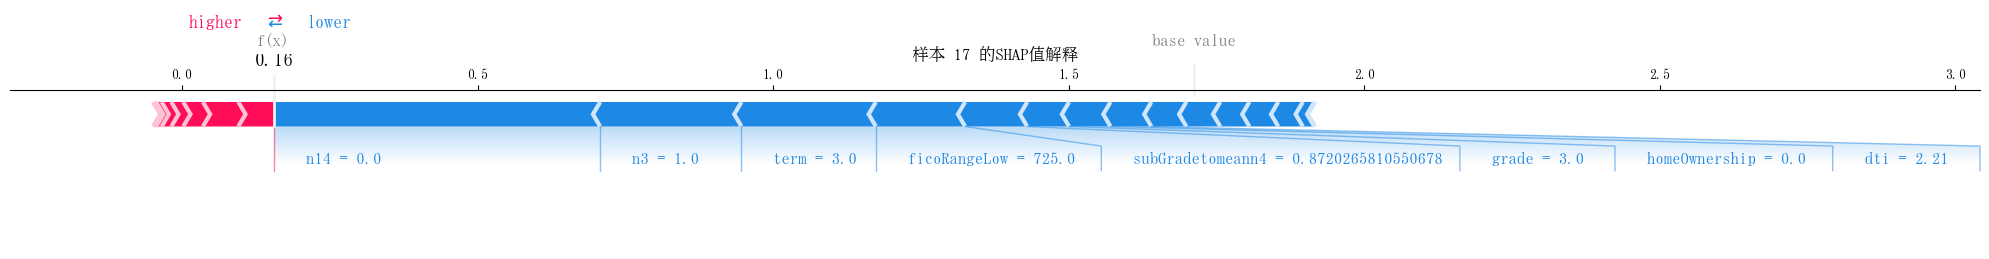


保存所有特征的SHAP值总和到CSV
所有特征的SHAP值总和已保存到 feature_shap_values.csv


(array([[-1.02346867e-01, -1.27011157e-01, -7.72715202e-02, ...,
         -6.26847938e-03, -8.78523396e-04, -4.45479617e-01],
        [ 4.84851351e-02, -3.46794902e-02, -9.29258201e-02, ...,
          3.16131611e-04, -3.16208148e-03,  2.67361290e-01],
        [ 1.66809025e-01, -1.84920757e-01,  1.20542404e-01, ...,
         -6.53597646e-03,  4.57997713e-03,  5.05118382e-01],
        ...,
        [-7.91341522e-02, -4.69935584e-02, -2.82439066e-02, ...,
          1.77596303e-03, -3.07482196e-03,  3.01091774e-01],
        [-1.15092123e-01, -1.19110352e-01,  1.54425273e-01, ...,
          1.68405987e-03, -3.38754885e-03,  4.81025163e-01],
        [-9.81460539e-02, -1.10985226e-01,  9.21197039e-02, ...,
          1.36904862e-03, -1.21616464e-03, -9.24144280e-01]]),
 array([0.08641819, 0.10081717, 0.0956564 , 0.0705107 , 0.03231696,
        0.22428496, 0.03482244, 0.17985617, 0.19376368, 0.00606555,
        0.00549598, 0.15786397, 0.07074824, 0.35652729, 0.19878581,
        0.13014339, 0.019

In [192]:
main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=[99, 5, 10,68387,15274,143193,36088,17])

# 4.5.2 绘制单个样本的SHAP图

In [314]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb

# 假设您已经有了LightGBM模型的结果
# results = lgb_model(x_train, y_train, x_test)
# 以及训练数据 x_train, y_train 和测试数据 x_test

def shap_analysis_lgbm(model, x_train, x_test, feature_names=None):
    """
    对LightGBM模型进行SHAP值分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表，如果为None则使用x_train的列名
    
    返回:
    shap_values: 计算得到的SHAP值
    explainer: SHAP解释器对象
    """
    # 如果输入是pandas DataFrame，则获取特征名称
    if isinstance(x_train, pd.DataFrame):
        feature_names = x_train.columns.tolist()
        x_train_values = x_train.values
    else:
        x_train_values = x_train
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(x_train.shape[1])]
    
    # 创建SHAP解释器
    explainer = shap.TreeExplainer(model)
    
    # 计算SHAP值
    shap_values = explainer.shap_values(x_test)
    
    return shap_values, explainer, feature_names

def plot_shap_importance(shap_values, feature_names, title="特征重要性（基于SHAP值）", figsize=(12, 8)):
    """
    绘制基于SHAP值的特征重要性图
    
    参数:
    shap_values: SHAP值
    feature_names: 特征名称列表
    title: 图表标题
    figsize: 图表大小
    """
    plt.figure(figsize=figsize)
    
    # 对于二分类问题，shap_values可能是一个列表，包含两类的SHAP值（我们通常取正类的值）
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # 取正类的SHAP值
    
    # 计算每个特征的平均绝对SHAP值
    shap_importance = np.abs(shap_values).mean(axis=0)
    
    # 创建排序索引
    idx = np.argsort(shap_importance)
    
    # 绘制条形图
    plt.barh(range(len(idx)), shap_importance[idx], align='center')
    plt.yticks(range(len(idx)), [feature_names[i] for i in idx])
    plt.title(title)
    plt.xlabel('平均|SHAP值|（特征对模型输出的影响程度）')
    plt.tight_layout()
    plt.savefig('shap_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return shap_importance

def plot_shap_summary(shap_values, x_test, feature_names=None, max_display=20, figsize=(10, 8)):
    """
    绘制SHAP摘要图，展示每个特征的SHAP值分布
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_names: 特征名称列表
    max_display: 最多显示的特征数量
    figsize: 图表大小
    """
    plt.figure(figsize=figsize)
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换为数组
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        x_test = x_test.values
    
    # 绘制SHAP摘要图
    shap.summary_plot(shap_values, x_test, feature_names=feature_names, max_display=max_display, show=False)
    plt.title('SHAP值摘要图')
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_shap_dependence(shap_values, x_test, feature_idx, feature_names=None, interaction_index=None, figsize=(10, 6)):
    """
    绘制单变量SHAP值依赖图，展示特征值与SHAP值的关系
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_idx: 要分析的特征索引
    feature_names: 特征名称列表
    interaction_index: 交互特征的索引（用于展示交互效应）
    figsize: 图表大小
    """
    plt.figure(figsize=figsize)
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换特征索引为名称
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        feature_name = feature_names[feature_idx]
        if interaction_index is not None and isinstance(interaction_index, int):
            interaction_name = feature_names[interaction_index]
        else:
            interaction_name = interaction_index
        x_test_values = x_test.values
    else:
        feature_name = f'Feature_{feature_idx}' if feature_names is None else feature_names[feature_idx]
        interaction_name = interaction_index
        x_test_values = x_test
    
    # 绘制依赖图
    shap.dependence_plot(feature_idx, shap_values, x_test_values, feature_names=feature_names, 
                         interaction_index=interaction_index, show=False)
    plt.title(f'特征 {feature_name} 的SHAP值依赖图')
    plt.tight_layout()
    plt.savefig(f'shap_dependence_{feature_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_shap_single_prediction(explainer, x_test, idx, feature_names=None, figsize=(10, 12)):
    """
    绘制单个样本的SHAP值解释图
    
    参数:
    explainer: SHAP解释器对象
    x_test: 测试数据特征
    idx: 要分析的样本索引
    feature_names: 特征名称列表
    figsize: 图表大小
    """
    plt.figure(figsize=figsize)
    
    # 获取单个样本
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        x_single = x_test.iloc[idx].values.reshape(1, -1)
    else:
        x_single = x_test[idx:idx+1]
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(x_test.shape[1])]
    
    # 计算SHAP值
    shap_values_single = explainer.shap_values(x_single)
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values_single, list):
        shap_values_single = shap_values_single[1]
    
    # 绘制瀑布图
    shap.force_plot(explainer.expected_value if not isinstance(explainer.expected_value, list) 
                     else explainer.expected_value[1], 
                    shap_values_single, x_single, feature_names=feature_names, matplotlib=True, show=False)
    plt.title(f'样本 {idx} 的SHAP值解释')
    plt.tight_layout()
    plt.savefig(f'shap_force_plot_sample_{idx}.png', dpi=300, bbox_inches='tight')
    plt.show()

# 主函数：执行完整的SHAP分析
def main_shap_analysis(model, x_train, x_test, feature_names=None):
    print("4.3 SHAP对LightGBM模型的分析")
    
    # 计算SHAP值
    shap_values, explainer, feature_names = shap_analysis_lgbm(model, x_train, x_test, feature_names)
    
    # 4.3.1 变量重要性分析
    print("\n4.3.1 变量重要性分析")
    shap_importance = plot_shap_importance(shap_values, feature_names)
    
    # 4.3.2 单变量SHAP值的映射关系
    print("\n4.3.2 单变量SHAP值的映射关系")
    # 绘制SHAP摘要图
    plot_shap_summary(shap_values, x_test, feature_names)
    
    # 选择前三个最重要的特征绘制依赖图
    top_features = np.argsort(shap_importance)[3:]
    for feature_idx in top_features:
        plot_shap_dependence(shap_values, x_test, feature_idx, feature_names)
    
    # 4.3.3 单个样本的SHAP值计算
    print("\n4.3.3 单个样本的SHAP值计算")
    # 选择前三个样本进行分析
    for idx in range(min(3, len(x_test))):
        plot_shap_single_prediction(explainer, x_test, idx, feature_names)
    
    return shap_values, explainer, shap_importance

4.3 SHAP对LightGBM模型的分析

4.3.1 变量重要性分析


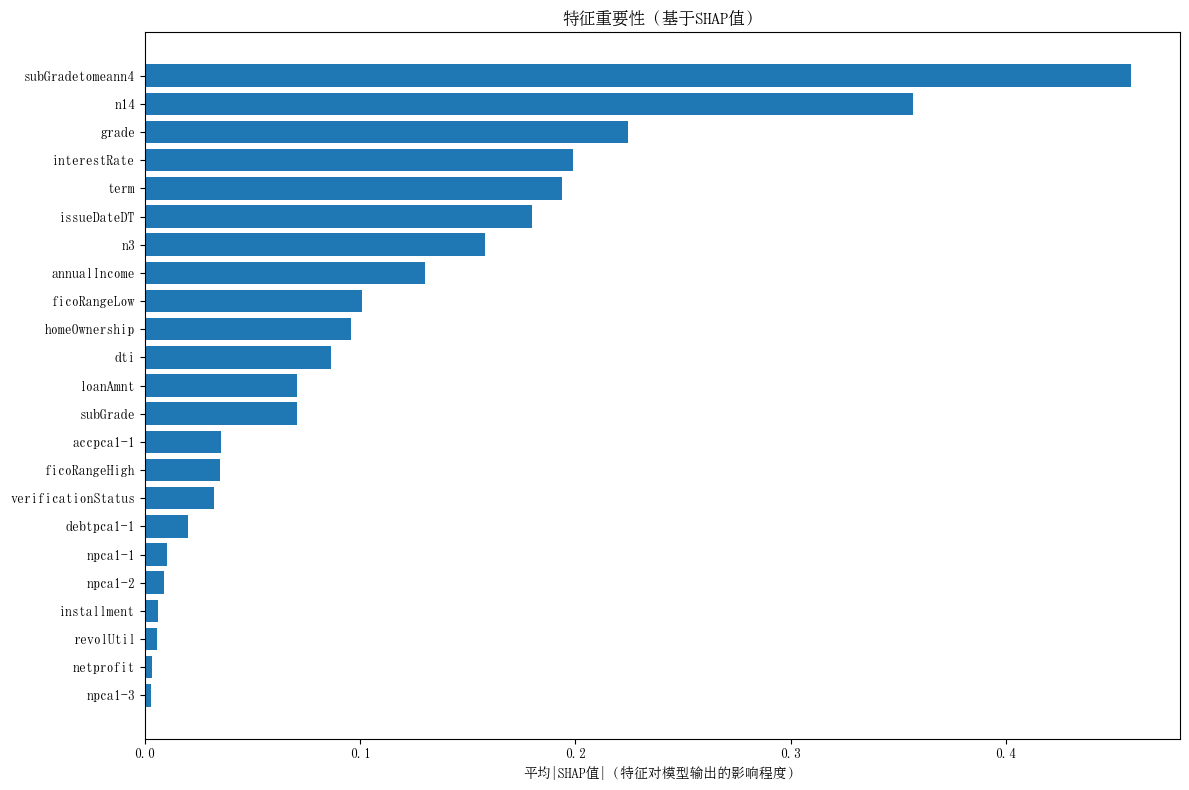


4.3.2 单变量SHAP值的映射关系


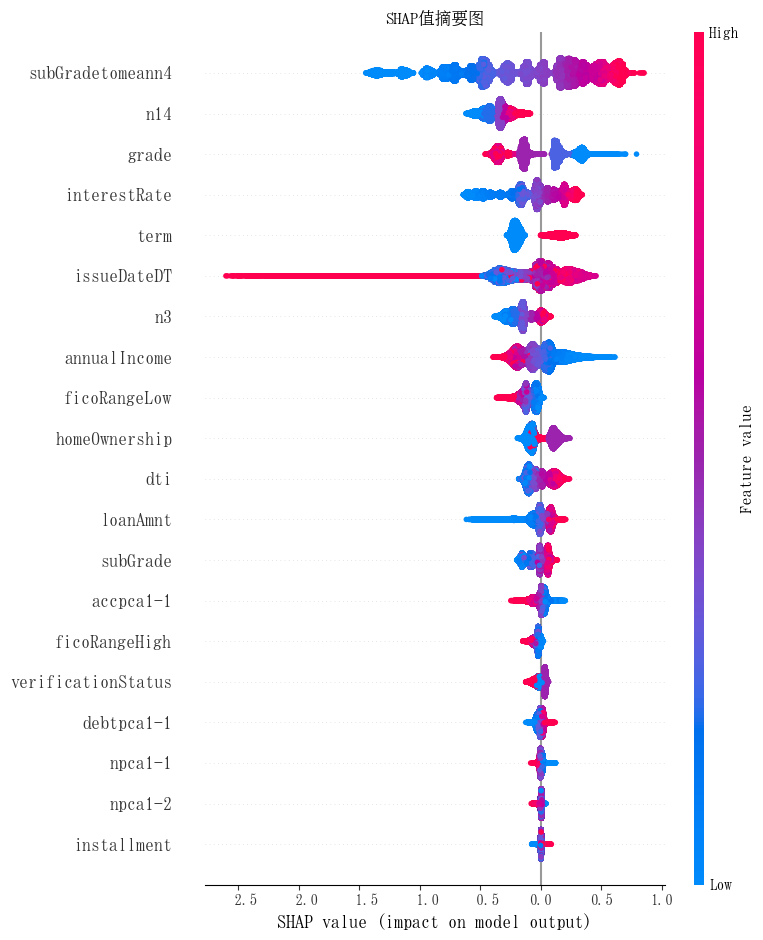

<Figure size 1000x600 with 0 Axes>

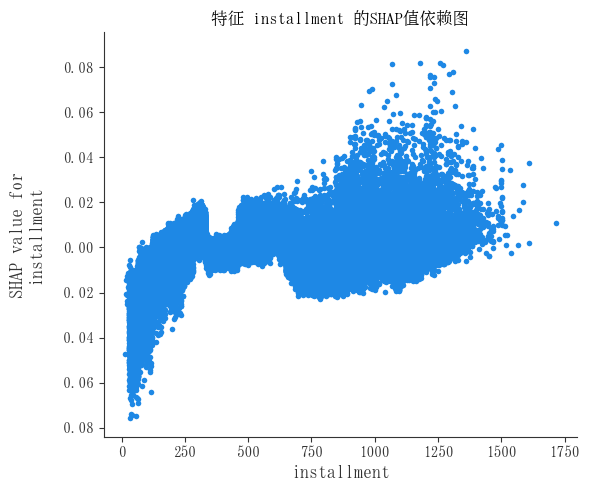

<Figure size 1000x600 with 0 Axes>

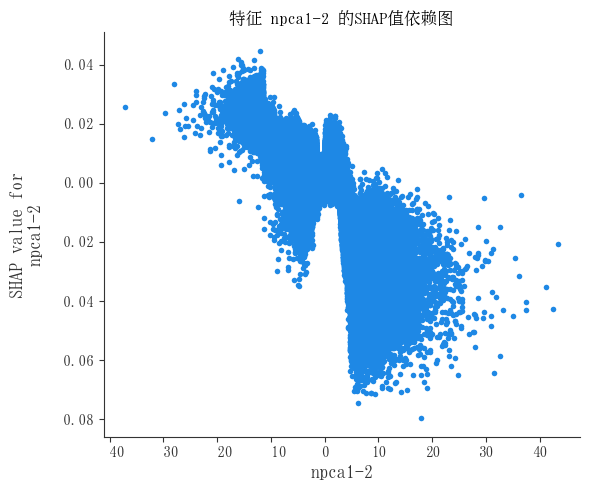

<Figure size 1000x600 with 0 Axes>

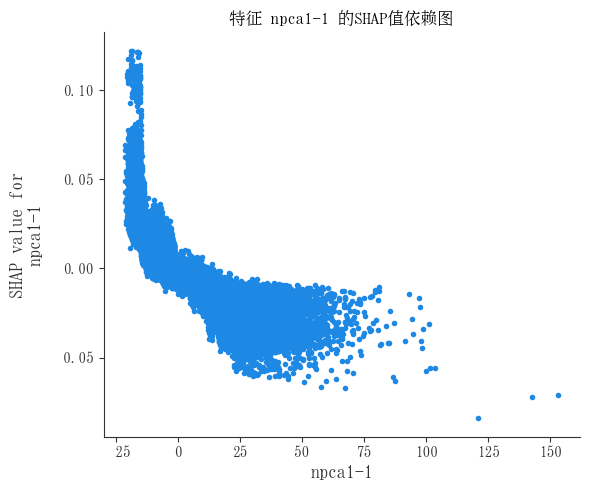

<Figure size 1000x600 with 0 Axes>

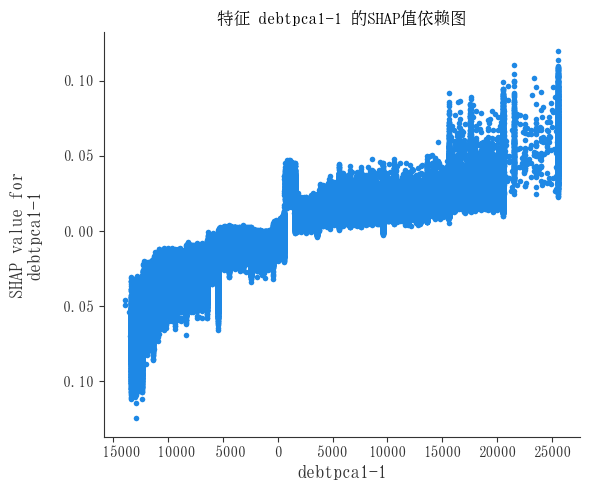

<Figure size 1000x600 with 0 Axes>

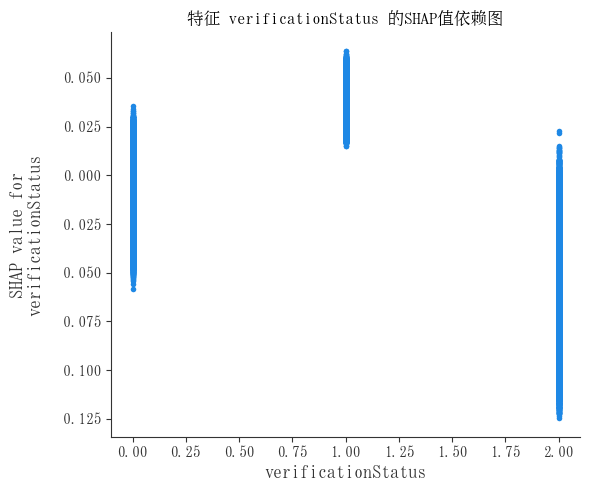

<Figure size 1000x600 with 0 Axes>

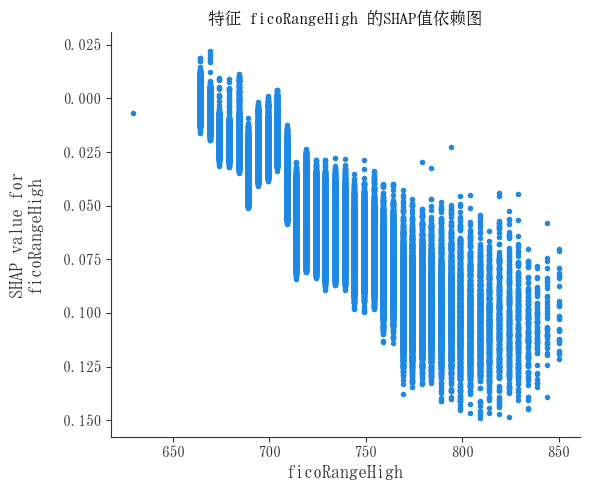

<Figure size 1000x600 with 0 Axes>

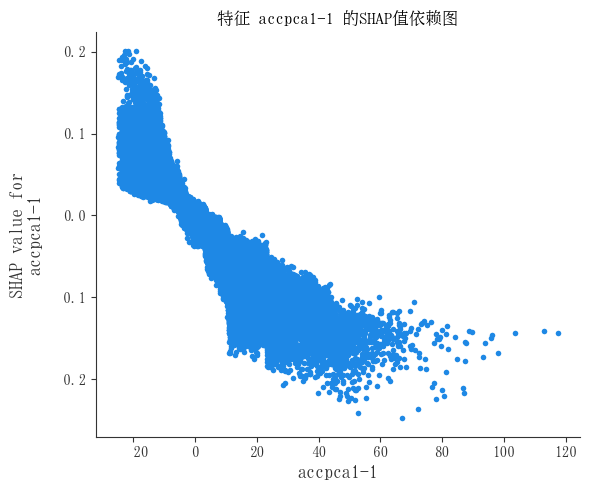

<Figure size 1000x600 with 0 Axes>

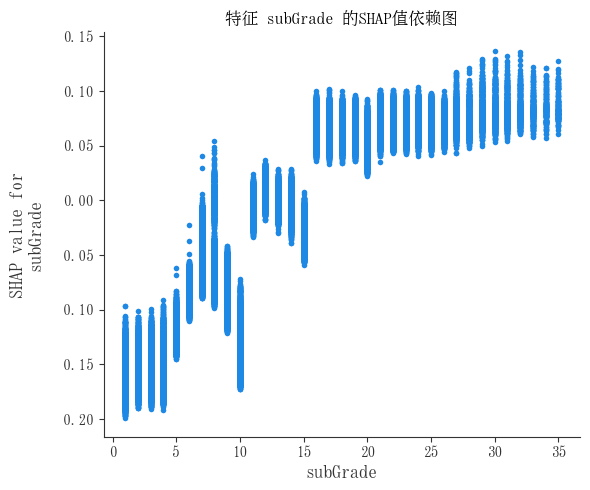

<Figure size 1000x600 with 0 Axes>

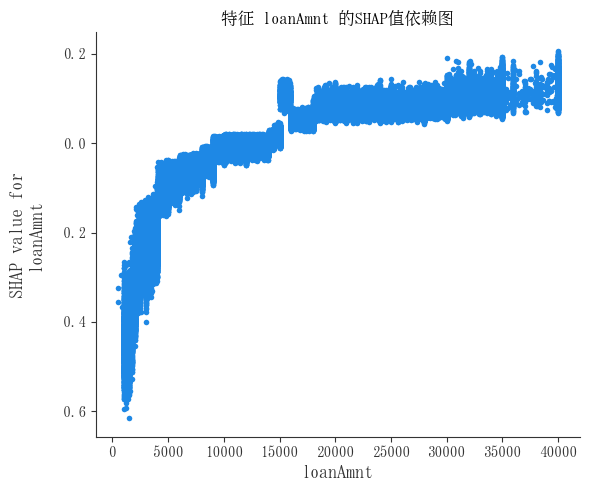

<Figure size 1000x600 with 0 Axes>

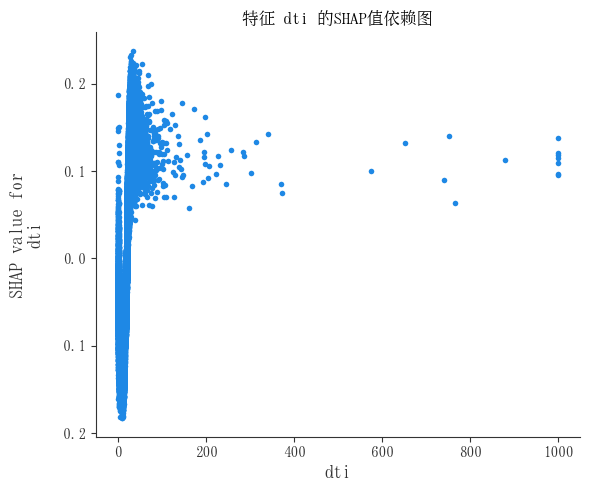

<Figure size 1000x600 with 0 Axes>

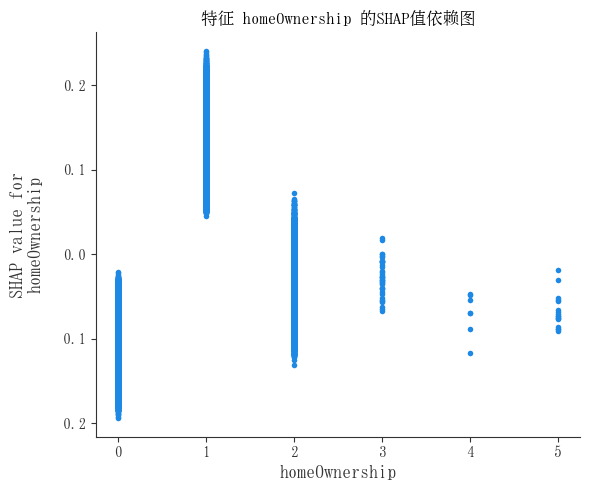

<Figure size 1000x600 with 0 Axes>

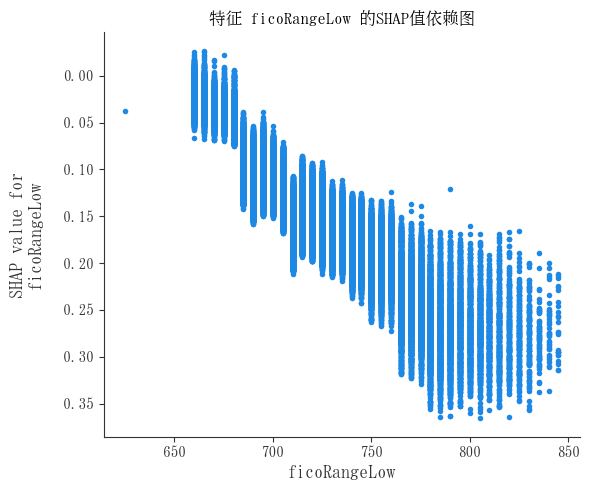

<Figure size 1000x600 with 0 Axes>

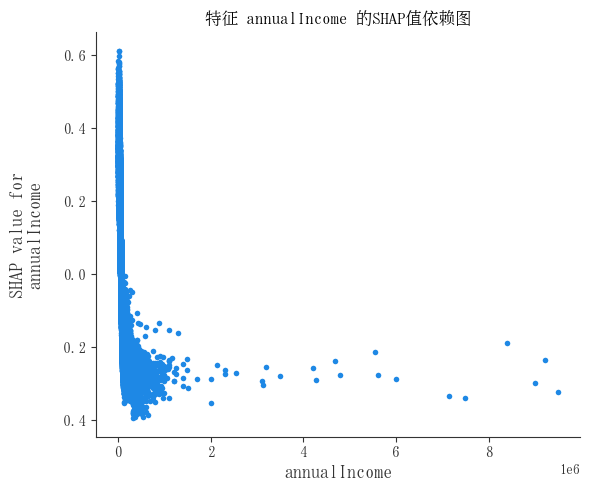

<Figure size 1000x600 with 0 Axes>

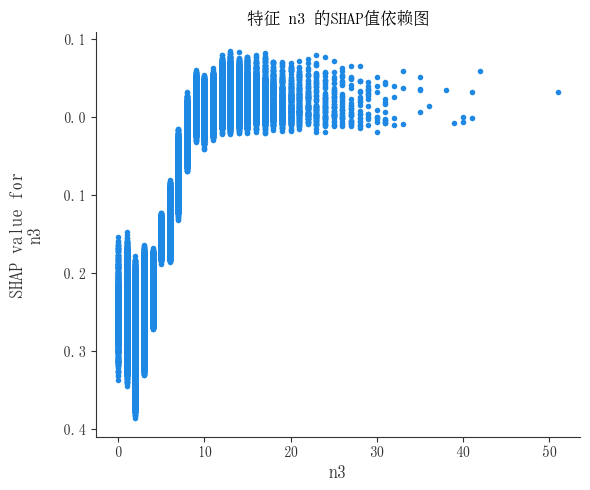

<Figure size 1000x600 with 0 Axes>

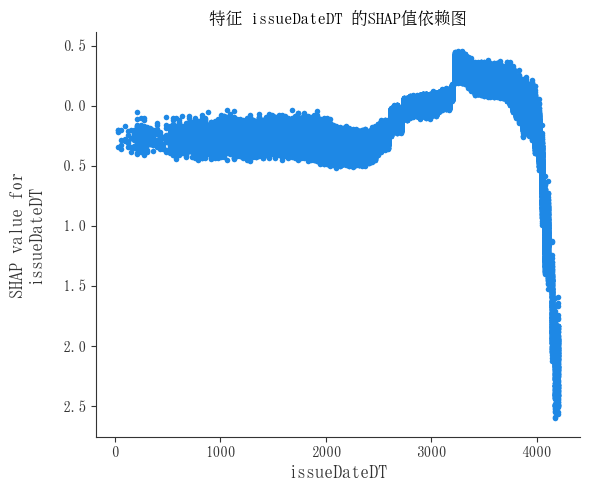

<Figure size 1000x600 with 0 Axes>

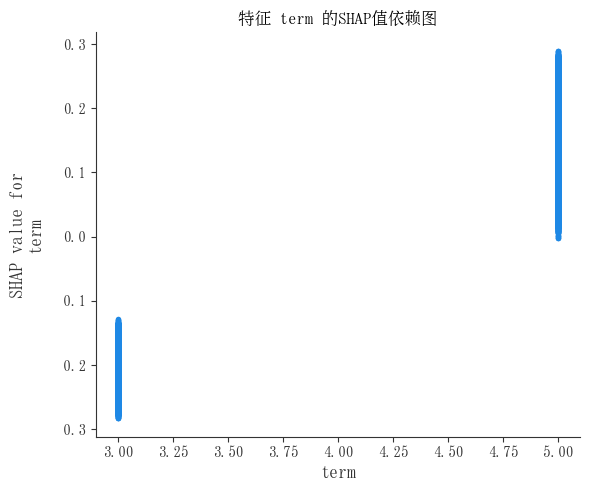

<Figure size 1000x600 with 0 Axes>

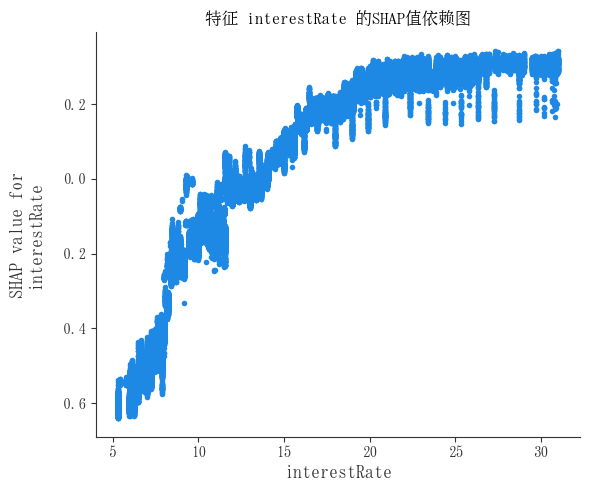

<Figure size 1000x600 with 0 Axes>

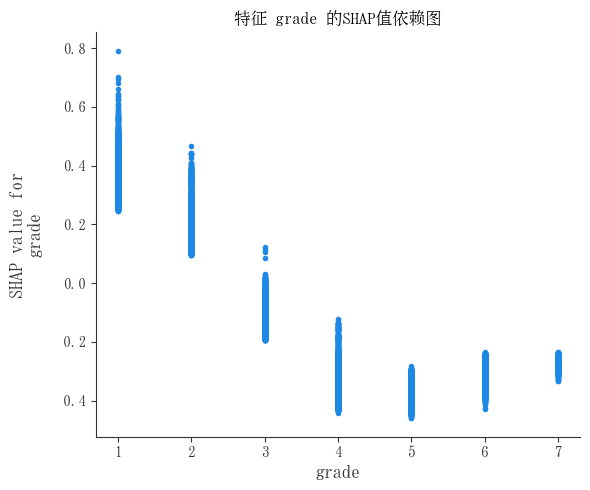

<Figure size 1000x600 with 0 Axes>

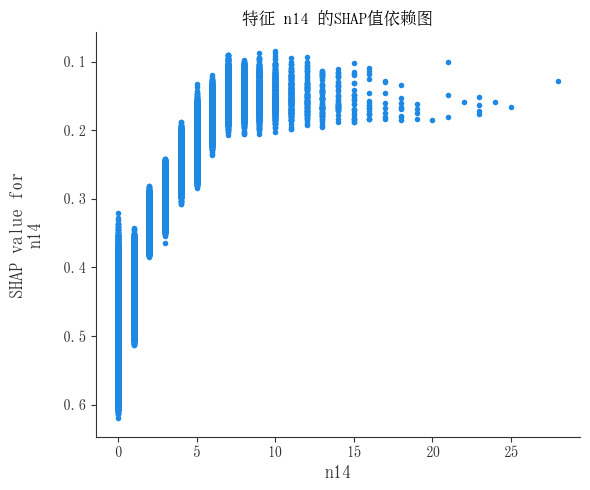

<Figure size 1000x600 with 0 Axes>

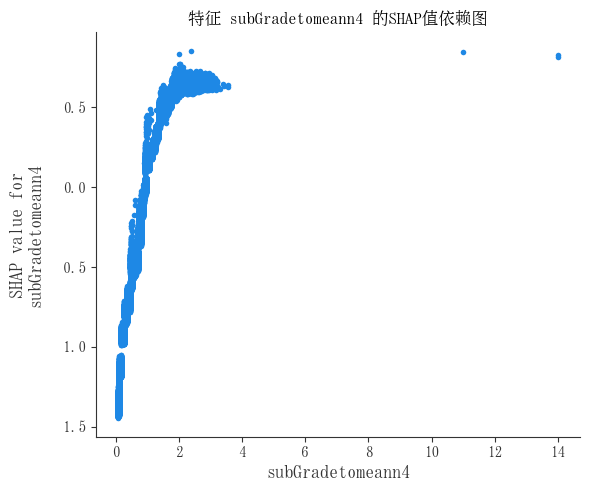


4.3.3 单个样本的SHAP值计算


<Figure size 1000x1200 with 0 Axes>

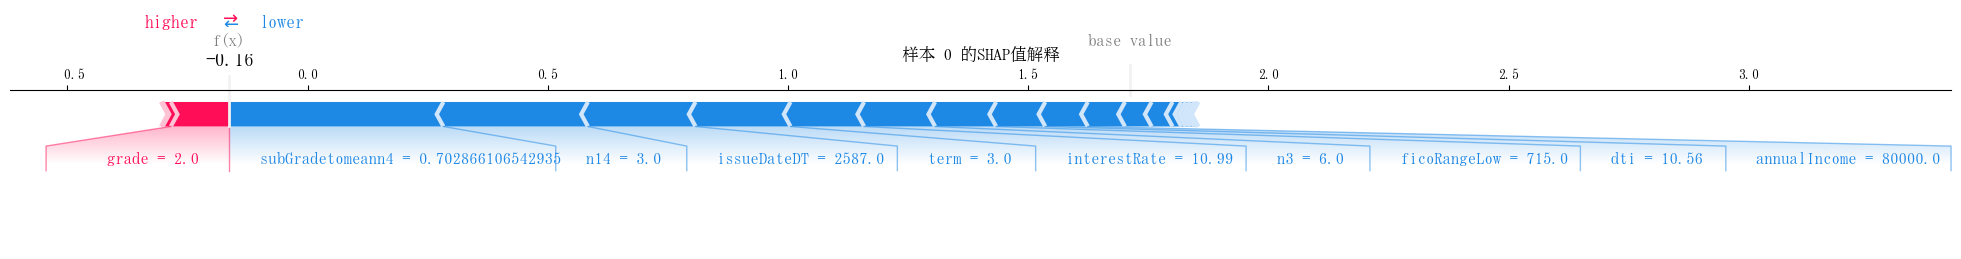

<Figure size 1000x1200 with 0 Axes>

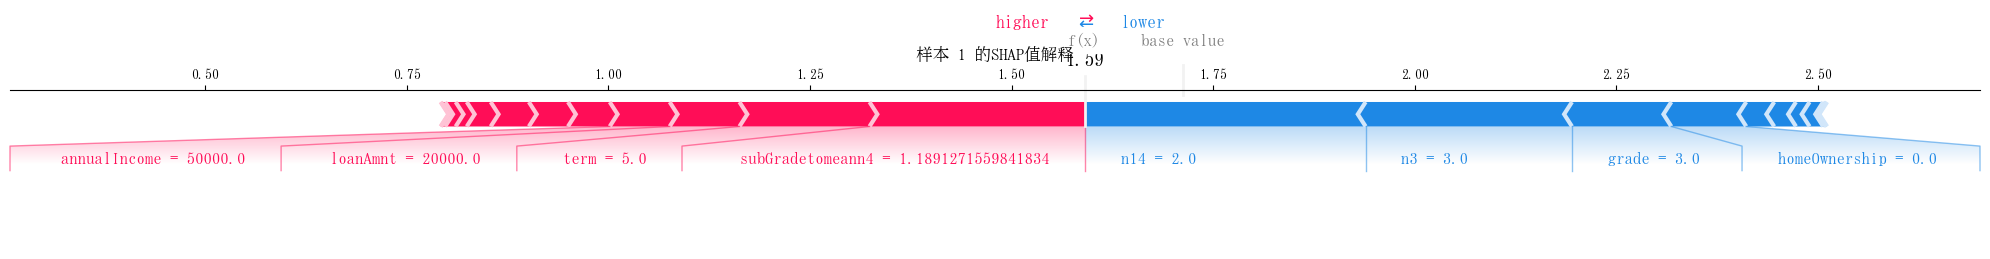

<Figure size 1000x1200 with 0 Axes>

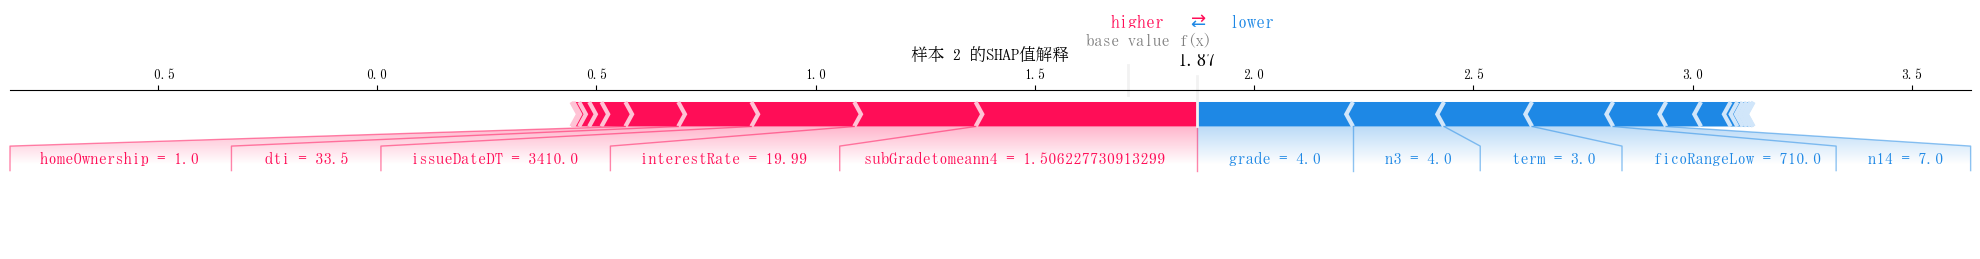


前9个最重要的特征（基于SHAP值）:
1. subGradetomeann4: 0.4579
2. n14: 0.3565
3. grade: 0.2243
4. interestRate: 0.1988
5. term: 0.1938
6. issueDateDT: 0.1799
7. n3: 0.1579
8. annualIncome: 0.1301
9. ficoRangeLow: 0.1008


In [187]:
# 调用主函数进行SHAP分析
# 假设您已经有了模型和数据
# 如果您的模型存储在results中，请相应调整以下代码
if 'results' in locals() and hasattr(results, 'model'):
    model = results.model  # 如果results包含模型
else:
    # 假设model是您已经训练好的LightGBM模型
    model = model  # 替换为您的模型变量名

# 执行SHAP分析
shap_values, explainer, shap_importance = main_shap_analysis(model, x_train, x_test)

# 输出前10个最重要的特征
top10_features = np.argsort(shap_importance)[-9:][::-1]
print("\n前9个最重要的特征（基于SHAP值）:")
for i, idx in enumerate(top10_features):
    print(f"{i+1}. {feature_names[idx]}: {shap_importance[idx]:.4f}")

In [188]:
# 按照预测概率排序
sorted_indices = processed_test['lgb_pred_prob'].sort_values(ascending=False).index

# 1. 高风险样本 (最高预测概率的样本)
high_risk_idx = sorted_indices[0]
print(f"高风险样本: 第{high_risk_idx}个，预测概率:{processed_test.loc[high_risk_idx, 'lgb_pred_prob']:.4f}")

# 2. 较高风险样本 (预测概率排名约25%的样本)
medium_risk_idx = sorted_indices[len(sorted_indices)//4]
print(f"较高风险样本: 第{medium_risk_idx}个，预测概率:{processed_test.loc[medium_risk_idx, 'lgb_pred_prob']:.4f}")

# 3. 低风险样本 (预测概率最低的样本)
low_risk_idx = sorted_indices[-1]
print(f"低风险样本: 第{low_risk_idx}个，预测概率:{processed_test.loc[low_risk_idx, 'lgb_pred_prob']:.4f}")

# 4. 边界样本 (预测概率接近0.5的样本)
boundary_idx = processed_test['lgb_pred_prob'].sub(0.5).abs().idxmin()
print(f"边界样本: 第{boundary_idx}个，预测概率:{processed_test.loc[boundary_idx, 'lgb_pred_prob']:.4f}")

高风险样本: 第68387个，预测概率:0.9781
较高风险样本: 第15274个，预测概率:0.7771
低风险样本: 第36088个，预测概率:0.0062
边界样本: 第143193个，预测概率:0.5000


# 调试代码，已经全部注释掉

In [197]:
correlation_matrix2 = data_train[['loanAmnt', 'installment','totalAcc','openAcc' ,'n1', 'n2','n3','n4', 'n5','n6']].corr()
plt.figure(figsize=(12, 10))
# 增大了字体大小(annot_kws)和调整了相关系数的可见度
sns.heatmap(correlation_matrix2, annot=True, cmap='coolwarm', fmt='.2f', 
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Variable Correlations', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('variable_correlations2.png', dpi=300, bbox_inches='tight')
plt.close()

In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb

# Set global font size settings for matplotlib
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 16
})

def shap_analysis_lgbm(model, x_train, x_test, feature_names=None):
    """
    对LightGBM模型进行SHAP值分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表，如果为None则使用x_train的列名
    
    返回:
    shap_values: 计算得到的SHAP值
    explainer: SHAP解释器对象
    """
    # 如果输入是pandas DataFrame，则获取特征名称
    if isinstance(x_train, pd.DataFrame):
        feature_names = x_train.columns.tolist()
        x_train_values = x_train.values
    else:
        x_train_values = x_train
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(x_train.shape[1])]
    
    # 创建SHAP解释器
    explainer = shap.TreeExplainer(model)
    
    # 计算SHAP值
    shap_values = explainer.shap_values(x_test)
    
    return shap_values, explainer, feature_names

def plot_shap_importance(shap_values, feature_names, title="特征重要性（基于SHAP值）", 
                         figsize=(12, 8), font_size=12, title_size=16, label_size=14):
    """
    绘制基于SHAP值的特征重要性图
    
    参数:
    shap_values: SHAP值
    feature_names: 特征名称列表
    title: 图表标题
    figsize: 图表大小
    font_size: 基础字体大小
    title_size: 标题字体大小
    label_size: 坐标轴标签字体大小
    """
    plt.figure(figsize=figsize)
    
    # 设置字体大小
    plt.rcParams.update({
        'font.size': font_size,
        'axes.titlesize': title_size,
        'axes.labelsize': label_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size
    })
    
    # 对于二分类问题，shap_values可能是一个列表，包含两类的SHAP值（我们通常取正类的值）
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # 取正类的SHAP值
    
    # 计算每个特征的平均绝对SHAP值
    shap_importance = np.abs(shap_values).mean(axis=0)
    
    # 创建排序索引
    idx = np.argsort(shap_importance)
    
    # 绘制条形图
    plt.barh(range(len(idx)), shap_importance[idx], align='center')
    plt.yticks(range(len(idx)), [feature_names[i] for i in idx])
    plt.title(title, fontsize=title_size)
    plt.xlabel('平均|SHAP值|（特征对模型输出的影响程度）', fontsize=label_size)
    plt.tight_layout()
    plt.savefig('shap_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return shap_importance

def plot_shap_summary(shap_values, x_test, feature_names=None, max_display=20, 
                      figsize=(10, 8), font_size=12):
    """
    绘制SHAP摘要图，展示每个特征的SHAP值分布
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_names: 特征名称列表
    max_display: 最多显示的特征数量
    figsize: 图表大小
    font_size: 字体大小
    """
    plt.figure(figsize=figsize)
    
    # 设置字体大小
    plt.rcParams.update({
        'font.size': font_size,
        'axes.titlesize': font_size + 2,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size
    })
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换为数组
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        x_test = x_test.values
    
    # 绘制SHAP摘要图，设置字体大小
    shap.summary_plot(shap_values, x_test, feature_names=feature_names, max_display=max_display, 
                      show=False, plot_size=figsize, alpha=0.8)
    plt.title('SHAP值摘要图', fontsize=font_size + 4)
    plt.gcf().axes[-1].set_aspect('auto')  # 调整颜色条比例
    plt.gcf().axes[-1].tick_params(labelsize=font_size)  # 设置颜色条刻度字体大小
    
    # 调整当前图形中所有轴的字体大小
    for ax in plt.gcf().axes:
        ax.tick_params(labelsize=font_size)
        if ax.get_xlabel():
            ax.set_xlabel(ax.get_xlabel(), fontsize=font_size)
        if ax.get_ylabel():
            ax.set_ylabel(ax.get_ylabel(), fontsize=font_size)
    
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_shap_dependence(shap_values, x_test, feature_idx, feature_names=None, 
                         interaction_index=None, figsize=(10, 6), font_size=12):
    """
    绘制单变量SHAP值依赖图，展示特征值与SHAP值的关系
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_idx: 要分析的特征索引
    feature_names: 特征名称列表
    interaction_index: 交互特征的索引（用于展示交互效应）
    figsize: 图表大小
    font_size: 字体大小
    """
    plt.figure(figsize=figsize)
    
    # 设置字体大小
    plt.rcParams.update({
        'font.size': font_size,
        'axes.titlesize': font_size + 2,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size
    })
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换特征索引为名称
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        feature_name = feature_names[feature_idx]
        if interaction_index is not None and isinstance(interaction_index, int):
            interaction_name = feature_names[interaction_index]
        else:
            interaction_name = interaction_index
        x_test_values = x_test.values
    else:
        feature_name = f'Feature_{feature_idx}' if feature_names is None else feature_names[feature_idx]
        interaction_name = interaction_index
        x_test_values = x_test
    
    # 绘制依赖图
    shap.dependence_plot(feature_idx, shap_values, x_test_values, feature_names=feature_names, 
                         interaction_index=interaction_index, show=False, alpha=0.8)
    plt.title(f'特征 {feature_name} 的SHAP值依赖图', fontsize=font_size + 4)
    
    # 调整所有子图的字体大小
    for ax in plt.gcf().axes:
        ax.tick_params(labelsize=font_size)
        if ax.get_xlabel():
            ax.set_xlabel(ax.get_xlabel(), fontsize=font_size)
        if ax.get_ylabel():
            ax.set_ylabel(ax.get_ylabel(), fontsize=font_size)
    
    plt.tight_layout()
    plt.savefig(f'shap_dependence_{feature_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_shap_single_prediction(explainer, x_test, idx, feature_names=None, 
                               figsize=(10, 12), font_size=12):
    """
    绘制单个样本的SHAP值解释图
    
    参数:
    explainer: SHAP解释器对象
    x_test: 测试数据特征
    idx: 要分析的样本索引
    feature_names: 特征名称列表
    figsize: 图表大小
    font_size: 字体大小
    """
    plt.figure(figsize=figsize)
    
    # 设置字体大小
    plt.rcParams.update({
        'font.size': font_size,
        'axes.titlesize': font_size + 2,
        'axes.labelsize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size
    })
    
    # 获取单个样本
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        x_single = x_test.iloc[idx].values.reshape(1, -1)
    else:
        x_single = x_test[idx:idx+1]
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(x_test.shape[1])]
    
    # 计算SHAP值
    shap_values_single = explainer.shap_values(x_single)
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values_single, list):
        shap_values_single = shap_values_single[1]
    
    # 绘制瀑布图
    expected_value = explainer.expected_value
    if isinstance(expected_value, list):
        expected_value = expected_value[1]
    
    # 使用matplotlib参数渲染force_plot，增加字体大小
    shap.force_plot(expected_value, shap_values_single, x_single, 
                   feature_names=feature_names, matplotlib=True, show=False, 
                   text_rotation=0, figsize=figsize)
    
    plt.title(f'样本 {idx} 的SHAP值解释', fontsize=font_size + 4)
    
    # 调整当前图形中所有文本元素的字体大小
    for text in plt.gcf().findobj(plt.Text):
        text.set_fontsize(font_size)
    
    plt.tight_layout()
    plt.savefig(f'shap_force_plot_sample_{idx}.png', dpi=300, bbox_inches='tight')
    plt.show()

# 主函数：执行完整的SHAP分析
def main_shap_analysis(model, x_train, x_test, feature_names=None, font_size=12):
    """
    执行完整的SHAP分析，包括重要性分析、摘要图、依赖图和单个样本解释
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表
    font_size: 所有图表的基础字体大小
    """
    # 设置全局字体大小
    plt.rcParams.update({
        'font.size': font_size,
        'axes.titlesize': font_size + 4,
        'axes.labelsize': font_size + 2,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'legend.fontsize': font_size
    })
    
    print("4.3 SHAP对LightGBM模型的分析")
    
    # 计算SHAP值
    shap_values, explainer, feature_names = shap_analysis_lgbm(model, x_train, x_test, feature_names)
    
    # 4.3.1 变量重要性分析
    print("\n4.3.1 变量重要性分析")
    shap_importance = plot_shap_importance(shap_values, feature_names, font_size=font_size)
    
    # 4.3.2 单变量SHAP值的映射关系
    print("\n4.3.2 单变量SHAP值的映射关系")
    # 绘制SHAP摘要图
    plot_shap_summary(shap_values, x_test, feature_names, font_size=font_size)
    
    # 选择前三个最重要的特征绘制依赖图
    top_features = np.argsort(shap_importance)[-3:]
    for feature_idx in top_features:
        plot_shap_dependence(shap_values, x_test, feature_idx, feature_names, font_size=font_size)
    
    # 4.3.3 单个样本的SHAP值计算
    print("\n4.3.3 单个样本的SHAP值计算")
    # 选择前三个样本进行分析
    for idx in range(min(3, len(x_test))):
        plot_shap_single_prediction(explainer, x_test, idx, feature_names, font_size=font_size)
    
    return shap_values, explainer, shap_importance

In [300]:
'''
# 如果您的模型存储在results中，请相应调整以下代码
if 'results' in locals() and hasattr(results, 'model'):
    model = results.model  # 如果results包含模型
else:
    # 假设model是您已经训练好的LightGBM模型
    model = model  # 替换为您的模型变量名

# 执行SHAP分析
shap_values, explainer, shap_importance = main_shap_analysis(model, x_train, x_test)

# 输出前10个最重要的特征
top10_features = np.argsort(shap_importance)[-9:][::-1]
print("\n前9个最重要的特征（基于SHAP值）:")
for i, idx in enumerate(top10_features):
    print(f"{i+1}. {feature_names[idx]}: {shap_importance[idx]:.4f}")
'''

'\n# 如果您的模型存储在results中，请相应调整以下代码\nif \'results\' in locals() and hasattr(results, \'model\'):\n    model = results.model  # 如果results包含模型\nelse:\n    # 假设model是您已经训练好的LightGBM模型\n    model = model  # 替换为您的模型变量名\n\n# 执行SHAP分析\nshap_values, explainer, shap_importance = main_shap_analysis(model, x_train, x_test)\n\n# 输出前10个最重要的特征\ntop10_features = np.argsort(shap_importance)[-9:][::-1]\nprint("\n前9个最重要的特征（基于SHAP值）:")\nfor i, idx in enumerate(top10_features):\n    print(f"{i+1}. {feature_names[idx]}: {shap_importance[idx]:.4f}")\n'

In [304]:
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb
import matplotlib as mpl

# Set global font parameters for matplotlib
def set_matplotlib_fonts(font_size=12):
    """
    Set global font parameters for matplotlib
    
    参数:
    font_size: 基础字体大小，最小为12
    """
    # Ensure minimum font size is 12
    font_size = max(12, font_size)
    
    plt.rcParams['font.size'] = font_size
    plt.rcParams['axes.titlesize'] = font_size + 2
    plt.rcParams['axes.labelsize'] = font_size
    plt.rcParams['xtick.labelsize'] = font_size
    plt.rcParams['ytick.labelsize'] = font_size
    plt.rcParams['legend.fontsize'] = font_size
    plt.rcParams['figure.titlesize'] = font_size + 4
    
    # Support for Chinese characters
    plt.rcParams['font.family'] = ['Hei']
    # Try to use a font that supports Chinese characters
    try:
        # For different OS
        if plt.sys.platform.startswith('win'):
            plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
        elif plt.sys.platform.startswith('darwin'):
            plt.rcParams['font.sans-serif'] = ['PingFang SC', 'STHeiti', 'Arial Unicode MS']
        else:  # Linux and others
            plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK JP', 'Arial Unicode MS']
    except:
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
    
    plt.rcParams['axes.unicode_minus'] = False  # Correctly show negative sign

def shap_analysis_lgbm(model, x_train, x_test, feature_names=None):
    """
    对LightGBM模型进行SHAP值分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表，如果为None则使用x_train的列名
    
    返回:
    shap_values: 计算得到的SHAP值
    explainer: SHAP解释器对象
    """
    # 如果输入是pandas DataFrame，则获取特征名称
    if isinstance(x_train, pd.DataFrame):
        feature_names = x_train.columns.tolist()
        x_train_values = x_train.values
    else:
        x_train_values = x_train
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(x_train.shape[1])]
    
    # 创建SHAP解释器
    explainer = shap.TreeExplainer(model)
    
    # 计算SHAP值
    shap_values = explainer.shap_values(x_test)
    
    return shap_values, explainer, feature_names

def plot_shap_importance(shap_values, feature_names, top_n=5, title="特征重要性（基于SHAP值）", 
                         figsize=(12, 8), font_size=12):
    """
    绘制基于SHAP值的特征重要性图，仅显示前top_n个特征
    
    参数:
    shap_values: SHAP值
    feature_names: 特征名称列表
    top_n: 要显示的最重要特征数量
    title: 图表标题
    figsize: 图表大小
    font_size: 字体大小，最小为12
    """
    # 设置全局字体
    set_matplotlib_fonts(font_size)
    
    plt.figure(figsize=figsize)
    
    # 对于二分类问题，shap_values可能是一个列表，包含两类的SHAP值（我们通常取正类的值）
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # 取正类的SHAP值
    
    # 计算每个特征的平均绝对SHAP值
    shap_importance = np.abs(shap_values).mean(axis=0)
    
    # 创建排序索引
    idx = np.argsort(shap_importance)[-top_n:]  # 仅获取前top_n个特征
    
    # 绘制条形图
    plt.barh(range(len(idx)), shap_importance[idx], align='center')
    plt.yticks(range(len(idx)), [feature_names[i] for i in idx])
    plt.title(f"{title} (Top {top_n})")
    plt.xlabel('平均|SHAP值|（特征对模型输出的影响程度）')
    plt.tight_layout()
    plt.savefig(f'shap_importance_top{top_n}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return shap_importance

def plot_shap_summary(shap_values, x_test, feature_names=None, max_display=5, 
                      figsize=(10, 8), font_size=12):
    """
    绘制SHAP摘要图，展示每个特征的SHAP值分布，仅显示前max_display个特征
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_names: 特征名称列表
    max_display: 最多显示的特征数量
    figsize: 图表大小
    font_size: 字体大小，最小为12
    """
    # 设置全局字体
    set_matplotlib_fonts(font_size)
    
    plt.figure(figsize=figsize)
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换为数组
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        x_test = x_test.values
    
    # 绘制SHAP摘要图，仅显示前max_display个特征
    # 修改shap库的默认字体大小
    original_rcparams = plt.rcParams.copy()  # 保存原始设置
    
    # 绘制SHAP摘要图
    shap.summary_plot(shap_values, x_test, feature_names=feature_names, max_display=max_display, show=False)
    
    # 修改字体大小
    ax = plt.gca()
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(font_size)
    
    plt.title(f'SHAP值摘要图 (Top {max_display})', fontsize=font_size + 2)
    plt.tight_layout()
    plt.savefig(f'shap_summary_top{max_display}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 恢复原始设置
    plt.rcParams.update(original_rcparams)

def plot_shap_dependence(shap_values, x_test, feature_idx, feature_names=None, 
                         interaction_index=None, figsize=(10, 6), font_size=12):
    """
    绘制单变量SHAP值依赖图，展示特征值与SHAP值的关系
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_idx: 要分析的特征索引
    feature_names: 特征名称列表
    interaction_index: 交互特征的索引（用于展示交互效应）
    figsize: 图表大小
    font_size: 字体大小，最小为12
    """
    # 设置全局字体
    set_matplotlib_fonts(font_size)
    
    plt.figure(figsize=figsize)
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换特征索引为名称
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        if isinstance(feature_idx, str):
            feature_idx = feature_names.index(feature_idx)
        feature_name = feature_names[feature_idx]
        
        if interaction_index is not None:
            if isinstance(interaction_index, str):
                interaction_index = feature_names.index(interaction_index)
            interaction_name = feature_names[interaction_index]
        else:
            interaction_name = interaction_index
        x_test_values = x_test.values
    else:
        feature_name = f'Feature_{feature_idx}' if feature_names is None else feature_names[feature_idx]
        interaction_name = interaction_index
        x_test_values = x_test
    
    # 保存原始设置
    original_rcparams = plt.rcParams.copy()
    
    # 绘制依赖图
    shap.dependence_plot(feature_idx, shap_values, x_test_values, feature_names=feature_names, 
                         interaction_index=interaction_index, show=False)
    
    # 修改字体大小
    ax = plt.gca()
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(font_size)
        
    # 如果有图例，设置图例字体大小
    if ax.get_legend() is not None:
        for text in ax.get_legend().get_texts():
            text.set_fontsize(font_size)
    
    # 设置标题（带交互特征名称）
    if interaction_index is not None:
        interaction_name = feature_names[interaction_index] if isinstance(interaction_index, int) else interaction_index
        plt.title(f'特征 {feature_name} 与 {interaction_name} 的SHAP值交互依赖图', fontsize=font_size + 2)
        save_name = f'shap_dependence_{feature_name.replace(" ", "_")}_{interaction_name.replace(" ", "_")}.png'
    else:
        plt.title(f'特征 {feature_name} 的SHAP值依赖图', fontsize=font_size + 2)
        save_name = f'shap_dependence_{feature_name.replace(" ", "_")}.png'
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()
    
    # 恢复原始设置
    plt.rcParams.update(original_rcparams)

def plot_shap_single_prediction(explainer, x_test, sample_indices, feature_names=None, 
                               figsize=(10, 12), font_size=12):
    """
    绘制多个样本的SHAP值解释图
    
    参数:
    explainer: SHAP解释器对象
    x_test: 测试数据特征
    sample_indices: 要分析的样本索引列表
    feature_names: 特征名称列表
    figsize: 图表大小
    font_size: 字体大小，最小为12
    """
    # 设置全局字体
    set_matplotlib_fonts(font_size)
    
    # 确保sample_indices是列表
    if not isinstance(sample_indices, list):
        sample_indices = [sample_indices]
    
    # 对每个样本绘制解释图
    for idx in sample_indices:
        plt.figure(figsize=figsize)
        
        # 获取单个样本
        if isinstance(x_test, pd.DataFrame):
            if feature_names is None:
                feature_names = x_test.columns.tolist()
            x_single = x_test.iloc[idx].values.reshape(1, -1)
        else:
            x_single = x_test[idx:idx+1]
            if feature_names is None:
                feature_names = [f'Feature_{i}' for i in range(x_test.shape[1])]
        
        # 计算SHAP值
        shap_values_single = explainer.shap_values(x_single)
        
        # 如果是二分类问题且shap_values是列表，取正类的SHAP值
        if isinstance(shap_values_single, list):
            shap_values_single = shap_values_single[1]
        
        # 保存原始设置
        original_rcparams = plt.rcParams.copy()
        
        # 绘制瀑布图
        expected_value = explainer.expected_value
        if isinstance(expected_value, list):
            expected_value = expected_value[1]
            
        shap.force_plot(expected_value, shap_values_single, x_single, 
                        feature_names=feature_names, matplotlib=True, show=False)
        
        # 修改字体大小
        ax = plt.gca()
        for item in ax.get_xticklabels() + ax.get_yticklabels():
            item.set_fontsize(font_size)
        
        plt.title(f'样本 {idx} 的SHAP值解释', fontsize=font_size + 2)
        plt.tight_layout()
        plt.savefig(f'shap_force_plot_sample_{idx}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # 恢复原始设置
        plt.rcParams.update(original_rcparams)

def save_all_features_shap_values(shap_values, feature_names, output_file='feature_shap_values.csv'):
    """
    保存所有特征的绝对SHAP值总和到CSV
    
    参数:
    shap_values: SHAP值
    feature_names: 特征名称列表
    output_file: 输出的CSV文件名
    """
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
        
    # 计算每个特征的绝对SHAP值总和
    shap_abs_sum = np.abs(shap_values).sum(axis=0)
    
    # 计算相对重要性百分比
    total_impact = shap_abs_sum.sum()
    relative_importance = (shap_abs_sum / total_impact) * 100
    
    # 创建DataFrame并排序
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'abs_shap_sum': shap_abs_sum,
        'relative_importance_percent': relative_importance
    })
    
    # 按重要性降序排序
    shap_df = shap_df.sort_values('abs_shap_sum', ascending=False)
    
    # 保存到CSV
    shap_df.to_csv(output_file, index=False)
    print(f"所有特征的SHAP值总和已保存到 {output_file}")
    
    return shap_df

# 主函数：执行完整的SHAP分析
def main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=None, 
                       font_size=12):
    """
    执行完整的SHAP分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表
    sample_indices: 要分析的样本索引列表，如果为None则使用前3个样本
    font_size: 字体大小，最小值为12
    """
    # 确保字体大小至少为12
    font_size = max(12, font_size)
    
    print("4.3 SHAP对LightGBM模型的分析")
    print(f"使用字体大小: {font_size}pt")
    
    # 计算SHAP值
    shap_values, explainer, feature_names = shap_analysis_lgbm(model, x_train, x_test, feature_names)
    
    # 4.3.1 变量重要性分析 - 仅显示前10个特征
    print("\n4.3.1 变量重要性分析 (Top 10)")
    shap_importance = plot_shap_importance(shap_values, feature_names, top_n=10, font_size=font_size)
    
    # 4.3.2 单变量SHAP值的映射关系 - 仅显示前10个特征
    print("\n4.3.2 单变量SHAP值的映射关系 (Top 10)")
    plot_shap_summary(shap_values, x_test, feature_names, max_display=10, font_size=font_size)
    
    # 获取特征索引映射（用于交互图）
    feature_indices = {}
    for i, name in enumerate(feature_names):
        feature_indices[name] = i
    
    # 绘制特定的交互依赖图
    print("\n4.3.3 特定特征交互关系分析")
    
    # 1. interestRate与subGrade的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                             feature_idx="interestRate" if "interestRate" in feature_indices else feature_indices.get("interestRate", 0),
                             feature_names=feature_names, 
                             interaction_index="grade" if "grade" in feature_indices else feature_indices.get("grade", 1),
                             font_size=font_size)
    except Exception as e:
        print(f"无法绘制interestRate与grade的交互图: {e}")
        print(f"可用的特征名称: {feature_names}")
    
    # 2. accpcal-1与subGrade的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                             feature_idx="accpcal-1" if "accpcal-1" in feature_indices else feature_indices.get("accpcal-1", 0),
                             feature_names=feature_names, 
                             interaction_index="subGrade" if "subGrade" in feature_indices else feature_indices.get("subGrade", 1),
                             font_size=font_size)
    except Exception as e:
        print(f"无法绘制accpcal-1与subGrade的交互图: {e}")
    
    # 3. accpcal-1与n3的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                             feature_idx="accpcal-1" if "accpcal-1" in feature_indices else feature_indices.get("accpcal-1", 0),
                             feature_names=feature_names, 
                             interaction_index="n3" if "n3" in feature_indices else feature_indices.get("n3", 2),
                             font_size=font_size)
    except Exception as e:
        print(f"无法绘制accpcal-1与n3的交互图: {e}")
    
    # 4.3.5 单个样本的SHAP值计算 - 允许自定义样本
    print("\n4.3.5 单个样本的SHAP值计算")
    if sample_indices is None:
        sample_indices = list(range(min(3, len(x_test))))
    
    plot_shap_single_prediction(explainer, x_test, sample_indices, feature_names, font_size=font_size)
    
    # 保存所有特征的SHAP值总和到CSV
    print("\n保存所有特征的SHAP值总和到CSV")
    shap_df = save_all_features_shap_values(shap_values, feature_names)
    
    return shap_values, explainer, shap_importance, shap_df

# 示例调用
# main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=[0, 5, 10], font_size=14)
'''

'\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport shap\nimport lightgbm as lgb\nimport matplotlib as mpl\n\n# Set global font parameters for matplotlib\ndef set_matplotlib_fonts(font_size=12):\n    """\n    Set global font parameters for matplotlib\n    \n    参数:\n    font_size: 基础字体大小，最小为12\n    """\n    # Ensure minimum font size is 12\n    font_size = max(12, font_size)\n    \n    plt.rcParams[\'font.size\'] = font_size\n    plt.rcParams[\'axes.titlesize\'] = font_size + 2\n    plt.rcParams[\'axes.labelsize\'] = font_size\n    plt.rcParams[\'xtick.labelsize\'] = font_size\n    plt.rcParams[\'ytick.labelsize\'] = font_size\n    plt.rcParams[\'legend.fontsize\'] = font_size\n    plt.rcParams[\'figure.titlesize\'] = font_size + 4\n    \n    # Support for Chinese characters\n    plt.rcParams[\'font.family\'] = [\'Hei\']\n    # Try to use a font that supports Chinese characters\n    try:\n        # For different OS\n        if plt.sys.platform.startswith

In [305]:
#main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=[0, 5, 10], font_size=12)

In [306]:
'''
def plot_feature_shap_dependence(shap_values, x_test, feature_name, 
                                 feature_names=None, figsize=(12, 8), 
                                 font_size=12, show_colorbar=True,
                                 title=None, save_fig=True):
    """
    绘制指定特征的SHAP依赖图，展示特征值与SHAP值的关系
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征 (DataFrame或numpy数组)
    feature_name: 要分析的特征名称
    feature_names: 特征名称列表，如果为None且x_test是DataFrame则使用其列名
    figsize: 图表大小
    font_size: 字体大小，最小为12
    show_colorbar: 是否显示颜色条
    title: 自定义标题，如果为None则使用默认标题
    save_fig: 是否保存图表，默认为True
    
    返回:
    fig, ax: matplotlib的图形和轴对象
    """
    # 设置全局字体
    # Ensure minimum font size is 12
    font_size = max(12, font_size)
    
    plt.rcParams['font.size'] = font_size
    plt.rcParams['axes.titlesize'] = font_size + 2
    plt.rcParams['axes.labelsize'] = font_size
    plt.rcParams['xtick.labelsize'] = font_size
    plt.rcParams['ytick.labelsize'] = font_size
    plt.rcParams['legend.fontsize'] = font_size
    plt.rcParams['figure.titlesize'] = font_size + 4
    '''
    # Support for Chinese characters
    plt.rcParams['font.family'] = ['STHeiti']
    # Try to use a font that supports Chinese characters
    try:
        # For different OS
        if plt.sys.platform.startswith('win'):
            plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
        elif plt.sys.platform.startswith('darwin'):
            plt.rcParams['font.sans-serif'] = ['PingFang SC', 'STHeiti', 'Arial Unicode MS']
        else:  # Linux and others
            plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK JP', 'Arial Unicode MS']
    except:
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
    '''
    plt.rcParams['axes.unicode_minus'] = False  # Correctly show negative sign
    
    # 创建图形
    fig, ax = plt.subplots(figsize=figsize)
    
    # 获取特征索引和数据
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        
        if feature_name not in feature_names:
            if feature_name not in x_test.columns:
                raise ValueError(f"特征 '{feature_name}' 不在特征名列表或DataFrame列中")
            feature_idx = list(x_test.columns).index(feature_name)
        else:
            feature_idx = feature_names.index(feature_name)
            
        x_values = x_test[feature_name].values
        x_test_values = x_test.values
    else:
        # 如果x_test是numpy数组，需要提供feature_names
        if feature_names is None:
            raise ValueError("当x_test为numpy数组时，必须提供feature_names参数")
        
        feature_idx = feature_names.index(feature_name)
        x_values = x_test[:, feature_idx]
        x_test_values = x_test
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 提取指定特征的SHAP值
    feature_shap_values = shap_values[:, feature_idx]
    
    # 创建散点图
    cmap = plt.cm.coolwarm
    sc = ax.scatter(x_values, feature_shap_values, c=np.arange(len(x_values)), 
                    cmap=cmap, s=50, alpha=0.8, edgecolors='none')
    
    # 添加水平零线
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    
    # 设置标签和标题
    ax.set_xlabel(f'{feature_name}的值', fontsize=font_size)
    ax.set_ylabel(f'SHAP值 (对预测的影响)', fontsize=font_size)
    
    if title is None:
        title = f'特征 {feature_name} 的SHAP值依赖图'
    ax.set_title(title, fontsize=font_size + 2)
    
    # 是否显示颜色条
    if show_colorbar:
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label('样本索引', fontsize=font_size)
        cbar.ax.tick_params(labelsize=font_size)
    
    # 保存图形
    if save_fig:
        safe_feature_name = feature_name.replace(" ", "_").replace("/", "_")
        plt.tight_layout()
        plt.savefig(f'shap_dependence_{safe_feature_name}.png', dpi=300, bbox_inches='tight')
    
    return fig, ax

# 示例使用:
# 假设你已经有了模型、测试数据和SHAP值
# shap_values, explainer = shap_analysis_lgbm(model, x_train, x_test)
# plot_feature_shap_dependence(shap_values, x_test, "interestRate", font_size=14)
'''

IndentationError: unexpected indent (3423446988.py, line 36)

In [ ]:
#plot_feature_shap_dependence(shap_values, x_test, "interestRate", font_size=14)

In [ ]:
'''
def plot_feature_shap_dependence(shap_values, x_test, feature_name, 
                                feature_names=None, figsize=(12, 8), 
                                font_size=12, title=None, save_fig=True,
                                point_color='royalblue', point_size=50, point_alpha=0.7):
    """
    绘制指定特征的SHAP依赖图，展示特征值与SHAP值的关系
    所有点使用统一的蓝色表示
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征 (DataFrame或numpy数组)
    feature_name: 要分析的特征名称
    feature_names: 特征名称列表，如果为None且x_test是DataFrame则使用其列名
    figsize: 图表大小
    font_size: 字体大小，最小为12
    title: 自定义标题，如果为None则使用默认标题
    save_fig: 是否保存图表，默认为True
    point_color: 点的颜色，默认为'royalblue'
    point_size: 点的大小，默认为50
    point_alpha: 点的透明度，默认为0.7
    
    返回:
    fig, ax: matplotlib的图形和轴对象
    """
    # 设置全局字体
    # Ensure minimum font size is 12
    font_size = max(14, font_size)
    
    plt.rcParams['font.size'] = font_size
    plt.rcParams['axes.titlesize'] = font_size + 2
    plt.rcParams['axes.labelsize'] = font_size
    plt.rcParams['xtick.labelsize'] = font_size
    plt.rcParams['ytick.labelsize'] = font_size
    plt.rcParams['legend.fontsize'] = font_size
    plt.rcParams['figure.titlesize'] = font_size + 4
    
    # Support for Chinese characters
    plt.rcParams['font.family'] = ['Hei']
    # Try to use a font that supports Chinese characters
    try:
        # For different OS
        if plt.sys.platform.startswith('win'):
            plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
        elif plt.sys.platform.startswith('darwin'):
            plt.rcParams['font.sans-serif'] = ['PingFang SC', 'STHeiti', 'Arial Unicode MS']
        else:  # Linux and others
            plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK JP', 'Arial Unicode MS']
    except:
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
    
    plt.rcParams['axes.unicode_minus'] = False  # Correctly show negative sign
    
    # 创建图形
    fig, ax = plt.subplots(figsize=figsize)
    
    # 获取特征索引和数据
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        
        if feature_name not in feature_names:
            if feature_name not in x_test.columns:
                raise ValueError(f"特征 '{feature_name}' 不在特征名列表或DataFrame列中")
            feature_idx = list(x_test.columns).index(feature_name)
        else:
            feature_idx = feature_names.index(feature_name)
            
        x_values = x_test[feature_name].values
        x_test_values = x_test.values
    else:
        # 如果x_test是numpy数组，需要提供feature_names
        if feature_names is None:
            raise ValueError("当x_test为numpy数组时，必须提供feature_names参数")
        
        feature_idx = feature_names.index(feature_name)
        x_values = x_test[:, feature_idx]
        x_test_values = x_test
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 提取指定特征的SHAP值
    feature_shap_values = shap_values[:, feature_idx]
    
    # 创建散点图 - 使用统一的蓝色
    ax.scatter(x_values, feature_shap_values, 
               color=point_color, s=point_size, alpha=point_alpha, edgecolors='none')
    
    # 添加水平零线
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    
    # 设置标签和标题
    ax.set_xlabel(f'{feature_name}的值', fontsize=font_size)
    ax.set_ylabel(f'SHAP值 (对预测的影响)', fontsize=font_size)
    
    if title is None:
        title = f'特征 {feature_name} 的SHAP值依赖图'
    ax.set_title(title, fontsize=font_size + 2)
    
    # 保存图形
    if save_fig:
        safe_feature_name = feature_name.replace(" ", "_").replace("/", "_")
        plt.tight_layout()
        plt.savefig(f'shap_dependence_{safe_feature_name}.png', dpi=300, bbox_inches='tight')
    
    return fig, ax

# 示例使用:
# 假设你已经有了模型、测试数据和SHAP值
# shap_values, explainer = shap_analysis_lgbm(model, x_train, x_test)
# plot_feature_shap_dependence(shap_values, x_test, "interestRate", font_size=14)
'''

In [ ]:
 #plot_feature_shap_dependence(shap_values, x_test, "interestRate", font_size=16)

In [ ]:
'''
def plot_feature_shap_dependence(shap_values, x_test, feature_name, 
                                feature_names=None, 
                                point_color='dodgerblue', point_size=50, point_alpha=0.7):
    """
    绘制指定特征的SHAP依赖图，展示特征值与SHAP值的关系
    所有点使用统一的蓝色表示，图表尺寸、字体和边距已标准化
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征 (DataFrame或numpy数组)
    feature_name: 要分析的特征名称
    feature_names: 特征名称列表，如果为None且x_test是DataFrame则使用其列名
    point_color: 点的颜色，默认为'royalblue'
    point_size: 点的大小，默认为50
    point_alpha: 点的透明度，默认为0.7
    
    返回:
    fig, ax: matplotlib的图形和轴对象
    """
    # 标准化参数
    font_size = 12
    figsize = (10, 8)  # 统一的图表尺寸
    # Set global constants for visualization
    MARGINS = {'left': 0.1, 'right': 0.9, 'bottom': 0.1, 'top': 0.9}  # Standard margins
    
    # 设置全局字体
    plt.rcParams['font.size'] = font_size
    plt.rcParams['axes.titlesize'] = font_size + 2
    plt.rcParams['axes.labelsize'] = font_size
    plt.rcParams['xtick.labelsize'] = font_size
    plt.rcParams['ytick.labelsize'] = font_size
    plt.rcParams['legend.fontsize'] = font_size
    plt.rcParams['figure.titlesize'] = font_size + 4
    
    # 统一设置中文字体
    plt.rcParams['font.family'] = ['Hei']
    # Try to use a font that supports Chinese characters
    try:
        # For different OS
        if plt.sys.platform.startswith('win'):
            plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
        elif plt.sys.platform.startswith('darwin'):
            plt.rcParams['font.sans-serif'] = ['PingFang SC', 'STHeiti', 'Arial Unicode MS']
        else:  # Linux and others
            plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK JP', 'Arial Unicode MS']
    except:
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
    
    plt.rcParams['axes.unicode_minus'] = False  # Correctly show negative sign
    
    # 创建图形
    fig, ax = plt.subplots(figsize=figsize)
    
    # 设置统一的边距
    plt.subplots_adjust(left=0.12, right=0.95, top=0.9, bottom=0.12)
    
    # 获取特征索引和数据
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        
        if feature_name not in feature_names:
            if feature_name not in x_test.columns:
                raise ValueError(f"特征 '{feature_name}' 不在特征名列表或DataFrame列中")
            feature_idx = list(x_test.columns).index(feature_name)
        else:
            feature_idx = feature_names.index(feature_name)
            
        x_values = x_test[feature_name].values
        x_test_values = x_test.values
    else:
        # 如果x_test是numpy数组，需要提供feature_names
        if feature_names is None:
            raise ValueError("当x_test为numpy数组时，必须提供feature_names参数")
        
        feature_idx = feature_names.index(feature_name)
        x_values = x_test[:, feature_idx]
        x_test_values = x_test
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 提取指定特征的SHAP值
    feature_shap_values = shap_values[:, feature_idx]
    
    # 创建散点图 - 使用统一的蓝色
    ax.scatter(x_values, feature_shap_values, 
               color=point_color, s=point_size, alpha=point_alpha, edgecolors='none')
    
    # 添加水平零线
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
    
    # 设置标签和标题
    ax.set_xlabel(f'{feature_name}的值', fontsize=font_size)
    ax.set_ylabel(f'SHAP值 (对预测的影响)', fontsize=font_size)
    
    # 统一标题样式
    title = f'特征 {feature_name} 的SHAP值依赖图'
    ax.set_title(title, fontsize=font_size + 2, pad=10)  # 统一标题与图表的间距
    
    # 统一网格线样式（可选）
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # 统一坐标轴刻度样式
    ax.tick_params(axis='both', which='major', labelsize=font_size)
    
    # 保存图形
    safe_feature_name = feature_name.replace(" ", "_").replace("/", "_")
    plt.tight_layout()  # 自动调整边距，但保持一致的外观
    plt.savefig(f'shap_dependence_{safe_feature_name}.png', dpi=300, bbox_inches='tight')
    
    return fig, ax

# 示例使用:
# shap_values, explainer = shap_analysis_lgbm(model, x_train, x_test)
# plot_feature_shap_dependence(shap_values, x_test, "interestRate")
'''

In [ ]:
#plot_feature_shap_dependence(shap_values, x_test, "interestRate")

In [ ]:
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb
import matplotlib as mpl

# Set global constants for visualization
FIGURE_SIZE = (10, 8)  # Standard figure size for all plots
FONT_SIZE = 12  # Fixed font size for all text elements
DPI = 300  # Standard DPI for saving figures
MARGINS = {'left': 0.1, 'right': 0.9, 'bottom': 0.1, 'top': 0.9}  # Standard margins

# Replace default blue with sky blue
SKY_BLUE = '#1E90FF'  # Sky blue color code
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#1E90FF', '#FF9500', '#4CD964', '#FF2D55', '#5856D6'])

# Set global font parameters for matplotlib
def set_matplotlib_fonts():
    """Set global font parameters for matplotlib with standardized settings"""
    plt.rcParams['font.size'] = FONT_SIZE
    plt.rcParams['axes.titlesize'] = FONT_SIZE + 2
    plt.rcParams['axes.labelsize'] = FONT_SIZE
    plt.rcParams['xtick.labelsize'] = FONT_SIZE
    plt.rcParams['ytick.labelsize'] = FONT_SIZE
    plt.rcParams['legend.fontsize'] = FONT_SIZE
    plt.rcParams['figure.titlesize'] = FONT_SIZE + 4
    
    # Support for Chinese characters
    plt.rcParams['font.family'] = ['Hei']
    # Try to use a font that supports Chinese characters
    try:
        # For different OS
        if plt.sys.platform.startswith('win'):
            plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
        elif plt.sys.platform.startswith('darwin'):
            plt.rcParams['font.sans-serif'] = ['PingFang SC', 'STHeiti', 'Arial Unicode MS']
        else:  # Linux and others
            plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK JP', 'Arial Unicode MS']
    except:
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
    
    plt.rcParams['axes.unicode_minus'] = False  # Correctly show negative sign

def shap_analysis_lgbm(model, x_train, x_test, feature_names=None):
    """
    对LightGBM模型进行SHAP值分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表，如果为None则使用x_train的列名
    
    返回:
    shap_values: 计算得到的SHAP值
    explainer: SHAP解释器对象
    """
    # 如果输入是pandas DataFrame，则获取特征名称
    if isinstance(x_train, pd.DataFrame):
        feature_names = x_train.columns.tolist()
        x_train_values = x_train.values
    else:
        x_train_values = x_train
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(x_train.shape[1])]
    
    # 创建SHAP解释器
    explainer = shap.TreeExplainer(model)
    
    # 计算SHAP值
    shap_values = explainer.shap_values(x_test)
    
    return shap_values, explainer, feature_names

def setup_figure():
    """Set up a standard figure with consistent styling"""
    fig = plt.figure(figsize=FIGURE_SIZE)
    # Apply consistent margins
    plt.subplots_adjust(left=MARGINS['left'], right=MARGINS['right'], 
                        bottom=MARGINS['bottom'], top=MARGINS['top'])
    return fig

def plot_shap_importance(shap_values, feature_names, top_n=5, title="特征重要性（基于SHAP值）"):
    """
    绘制基于SHAP值的特征重要性图，仅显示前top_n个特征
    
    参数:
    shap_values: SHAP值
    feature_names: 特征名称列表
    top_n: 要显示的最重要特征数量
    title: 图表标题
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # Setup standardized figure
    setup_figure()
    
    # 对于二分类问题，shap_values可能是一个列表，包含两类的SHAP值（我们通常取正类的值）
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # 取正类的SHAP值
    
    # 计算每个特征的平均绝对SHAP值
    shap_importance = np.abs(shap_values).mean(axis=0)
    
    # 创建排序索引
    idx = np.argsort(shap_importance)[-top_n:]  # 仅获取前top_n个特征
    
    # 绘制条形图，使用天蓝色
    barplot = plt.barh(range(len(idx)), shap_importance[idx], align='center', color=SKY_BLUE)
    plt.yticks(range(len(idx)), [feature_names[i] for i in idx])
    plt.title(f"{title} (Top {top_n})")
    plt.xlabel('平均|SHAP值|（特征对模型输出的影响程度）')
    plt.tight_layout()
    plt.savefig(f'shap_importance_top{top_n}.png', dpi=DPI, bbox_inches='tight')
    plt.show()
    
    return shap_importance

def plot_shap_summary(shap_values, x_test, feature_names=None, max_display=5):
    """
    绘制SHAP摘要图，展示每个特征的SHAP值分布，仅显示前max_display个特征
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_names: 特征名称列表
    max_display: 最多显示的特征数量
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # Setup standardized figure
    setup_figure()
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换为数组
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        x_test = x_test.values
    
    # 保存原始设置
    original_rcparams = plt.rcParams.copy()
    
    # Modify SHAP colors to use sky blue for positive values
    shap_colors = shap.plots.colors.red_blue
    shap_colors.blue = SKY_BLUE  # Change blue to sky blue
    
    # 绘制SHAP摘要图
    shap.summary_plot(shap_values, x_test, feature_names=feature_names, max_display=max_display, show=False)
    
    # 修改字体大小
    ax = plt.gca()
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(FONT_SIZE)
    
    plt.title(f'SHAP值摘要图 (Top {max_display})', fontsize=FONT_SIZE + 2)
    plt.tight_layout()
    plt.savefig(f'shap_summary_top{max_display}.png', dpi=DPI, bbox_inches='tight')
    plt.show()
    
    # 恢复原始设置
    plt.rcParams.update(original_rcparams)

def plot_shap_dependence(shap_values, x_test, feature_idx, feature_names=None, 
                        interaction_index=None):
    """
    绘制单变量SHAP值依赖图，展示特征值与SHAP值的关系
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_idx: 要分析的特征索引
    feature_names: 特征名称列表
    interaction_index: 交互特征的索引（用于展示交互效应）
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # Setup standardized figure
    setup_figure()
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换特征索引为名称
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        if isinstance(feature_idx, str):
            feature_idx = feature_names.index(feature_idx)
        feature_name = feature_names[feature_idx]
        
        if interaction_index is not None:
            if isinstance(interaction_index, str):
                interaction_index = feature_names.index(interaction_index)
            interaction_name = feature_names[interaction_index]
        else:
            interaction_name = interaction_index
        x_test_values = x_test.values
    else:
        feature_name = f'Feature_{feature_idx}' if feature_names is None else feature_names[feature_idx]
        interaction_name = interaction_index
        x_test_values = x_test
    
    # 保存原始设置
    original_rcparams = plt.rcParams.copy()
    
    # 修改SHAP颜色为天蓝色
    shap_colors = shap.plots.colors.red_blue
    shap_colors.blue = SKY_BLUE  # Change blue to sky blue
    
    # 绘制依赖图
    shap.dependence_plot(feature_idx, shap_values, x_test_values, feature_names=feature_names, 
                        interaction_index=interaction_index, show=False)
    
    # 修改字体大小
    ax = plt.gca()
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(FONT_SIZE)
        
    # 如果有图例，设置图例字体大小
    if ax.get_legend() is not None:
        for text in ax.get_legend().get_texts():
            text.set_fontsize(FONT_SIZE)
    
    # 设置标题（带交互特征名称）
    if interaction_index is not None:
        interaction_name = feature_names[interaction_index] if isinstance(interaction_index, int) else interaction_index
        plt.title(f'特征 {feature_name} 与 {interaction_name} 的SHAP值交互依赖图', fontsize=FONT_SIZE + 2)
        save_name = f'shap_dependence_{feature_name.replace(" ", "_")}_{interaction_name.replace(" ", "_")}.png'
    else:
        plt.title(f'特征 {feature_name} 的SHAP值依赖图', fontsize=FONT_SIZE + 2)
        save_name = f'shap_dependence_{feature_name.replace(" ", "_")}.png'
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=DPI, bbox_inches='tight')
    plt.show()
    
    # 恢复原始设置
    plt.rcParams.update(original_rcparams)

def plot_shap_single_prediction(explainer, x_test, sample_indices, feature_names=None):
    """
    绘制多个样本的SHAP值解释图
    
    参数:
    explainer: SHAP解释器对象
    x_test: 测试数据特征
    sample_indices: 要分析的样本索引列表
    feature_names: 特征名称列表
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # 确保sample_indices是列表
    if not isinstance(sample_indices, list):
        sample_indices = [sample_indices]
    
    # 对每个样本绘制解释图
    for idx in sample_indices:
        # Setup standardized figure with adjusted height
        plt.figure(figsize=(FIGURE_SIZE[0], FIGURE_SIZE[0]*1.2))  # Slightly taller for force plots
        
        # 获取单个样本
        if isinstance(x_test, pd.DataFrame):
            if feature_names is None:
                feature_names = x_test.columns.tolist()
            x_single = x_test.iloc[idx].values.reshape(1, -1)
        else:
            x_single = x_test[idx:idx+1]
            if feature_names is None:
                feature_names = [f'Feature_{i}' for i in range(x_test.shape[1])]
        
        # 计算SHAP值
        shap_values_single = explainer.shap_values(x_single)
        
        # 如果是二分类问题且shap_values是列表，取正类的SHAP值
        if isinstance(shap_values_single, list):
            shap_values_single = shap_values_single[1]
        
        # 保存原始设置
        original_rcparams = plt.rcParams.copy()
        
        # 修改SHAP颜色为天蓝色
        shap.plots.colors.blue_rgb = tuple(int(SKY_BLUE.lstrip('#')[i:i+2], 16)/255 for i in (0, 2, 4))
        
        # 绘制瀑布图
        expected_value = explainer.expected_value
        if isinstance(expected_value, list):
            expected_value = expected_value[1]
            
        shap.force_plot(expected_value, shap_values_single, x_single, 
                        feature_names=feature_names, matplotlib=True, show=False)
        
        # 修改字体大小
        ax = plt.gca()
        for item in ax.get_xticklabels() + ax.get_yticklabels():
            item.set_fontsize(FONT_SIZE)
        
        plt.title(f'样本 {idx} 的SHAP值解释', fontsize=FONT_SIZE + 2)
        plt.tight_layout()
        plt.savefig(f'shap_force_plot_sample_{idx}.png', dpi=DPI, bbox_inches='tight')
        plt.show()
        
        # 恢复原始设置
        plt.rcParams.update(original_rcparams)

def save_all_features_shap_values(shap_values, feature_names, output_file='feature_shap_values.csv'):
    """
    保存所有特征的绝对SHAP值总和到CSV
    
    参数:
    shap_values: SHAP值
    feature_names: 特征名称列表
    output_file: 输出的CSV文件名
    """
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
        
    # 计算每个特征的绝对SHAP值总和
    shap_abs_sum = np.abs(shap_values).sum(axis=0)
    
    # 计算相对重要性百分比
    total_impact = shap_abs_sum.sum()
    relative_importance = (shap_abs_sum / total_impact) * 100
    
    # 创建DataFrame并排序
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'abs_shap_sum': shap_abs_sum,
        'relative_importance_percent': relative_importance
    })
    
    # 按重要性降序排序
    shap_df = shap_df.sort_values('abs_shap_sum', ascending=False)
    
    # 保存到CSV
    shap_df.to_csv(output_file, index=False)
    print(f"所有特征的SHAP值总和已保存到 {output_file}")
    
    return shap_df

# 主函数：执行完整的SHAP分析
def main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=None):
    """
    执行完整的SHAP分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表
    sample_indices: 要分析的样本索引列表，如果为None则使用前3个样本
    """
    print("4.3 SHAP对LightGBM模型的分析")
    print(f"使用标准化设置 - 图形尺寸: {FIGURE_SIZE}, 字体大小: {FONT_SIZE}pt, DPI: {DPI}")
    
    # 计算SHAP值
    shap_values, explainer, feature_names = shap_analysis_lgbm(model, x_train, x_test, feature_names)
    
    # 4.3.1 变量重要性分析 - 仅显示前10个特征
    print("\n4.3.1 变量重要性分析 (Top 10)")
    shap_importance = plot_shap_importance(shap_values, feature_names, top_n=10)
    
    # 4.3.2 单变量SHAP值的映射关系 - 仅显示前10个特征
    print("\n4.3.2 单变量SHAP值的映射关系 (Top 10)")
    plot_shap_summary(shap_values, x_test, feature_names, max_display=10)
    
    # 获取特征索引映射（用于交互图）
    feature_indices = {}
    for i, name in enumerate(feature_names):
        feature_indices[name] = i
    
    # 绘制特定的交互依赖图
    print("\n4.3.3 特定特征交互关系分析")
    
    # 1. interestRate与subGrade的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                            feature_idx="interestRate" if "interestRate" in feature_indices else feature_indices.get("interestRate", 0),
                            feature_names=feature_names, 
                            interaction_index="grade" if "grade" in feature_indices else feature_indices.get("grade", 1))
    except Exception as e:
        print(f"无法绘制interestRate与grade的交互图: {e}")
        print(f"可用的特征名称: {feature_names}")
    
    # 2. accpcal-1与subGrade的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                            feature_idx="accpcal-1" if "accpcal-1" in feature_indices else feature_indices.get("accpcal-1", 0),
                            feature_names=feature_names, 
                            interaction_index="subGrade" if "subGrade" in feature_indices else feature_indices.get("subGrade", 1))
    except Exception as e:
        print(f"无法绘制accpcal-1与subGrade的交互图: {e}")
    
    # 3. accpcal-1与n3的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                            feature_idx="accpcal-1" if "accpcal-1" in feature_indices else feature_indices.get("accpcal-1", 0),
                            feature_names=feature_names, 
                            interaction_index="n3" if "n3" in feature_indices else feature_indices.get("n3", 2))
    except Exception as e:
        print(f"无法绘制accpcal-1与n3的交互图: {e}")
    
    # 4.3.5 单个样本的SHAP值计算 - 允许自定义样本
    print("\n4.3.5 单个样本的SHAP值计算")
    if sample_indices is None:
        sample_indices = list(range(min(3, len(x_test))))
    
    plot_shap_single_prediction(explainer, x_test, sample_indices, feature_names)
    
    # 保存所有特征的SHAP值总和到CSV
    print("\n保存所有特征的SHAP值总和到CSV")
    shap_df = save_all_features_shap_values(shap_values, feature_names)
    
    return shap_values, explainer, shap_importance, shap_df

# 示例调用
# main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=[0, 5, 10])
'''

4.3 SHAP对LightGBM模型的分析
使用标准化设置 - 图形尺寸: (10, 8), 字体大小: 12pt, DPI: 300

4.3.1 变量重要性分析 (Top 10)


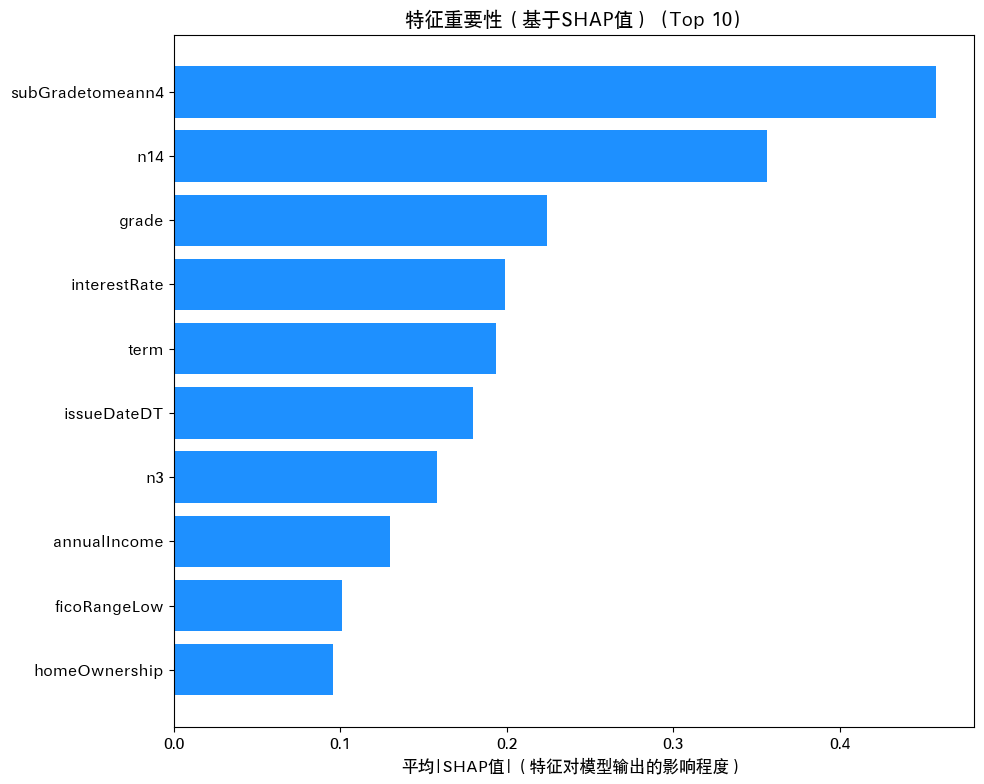


4.3.2 单变量SHAP值的映射关系 (Top 10)


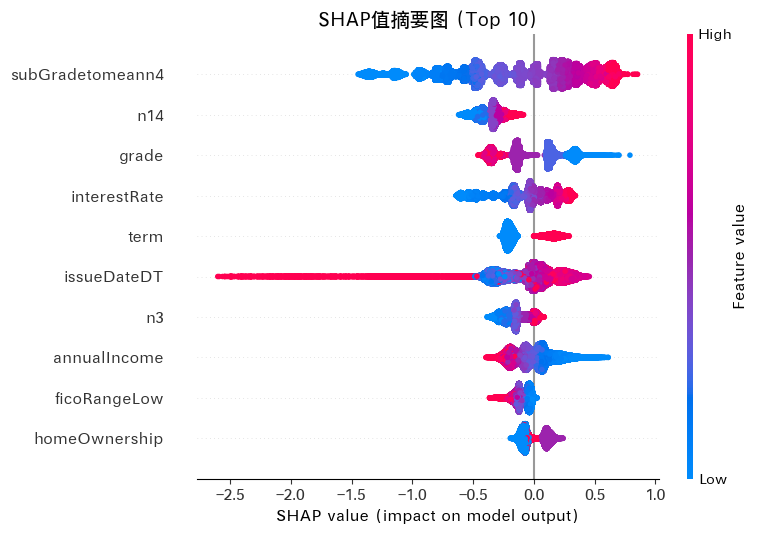


4.3.3 特定特征交互关系分析


<Figure size 1000x800 with 0 Axes>

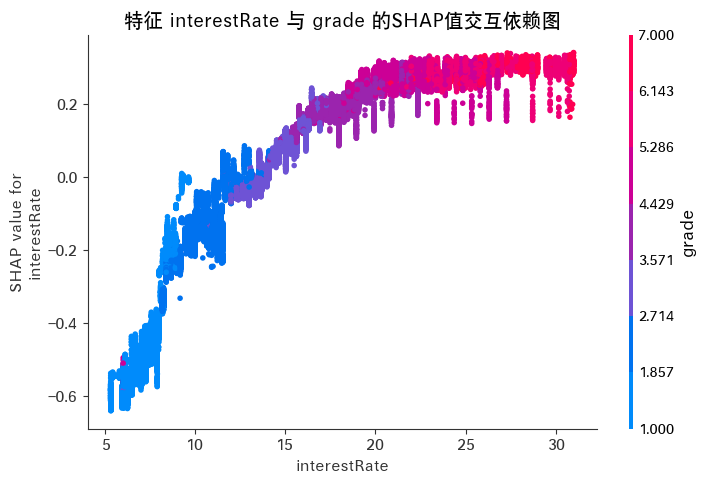

<Figure size 1000x800 with 0 Axes>

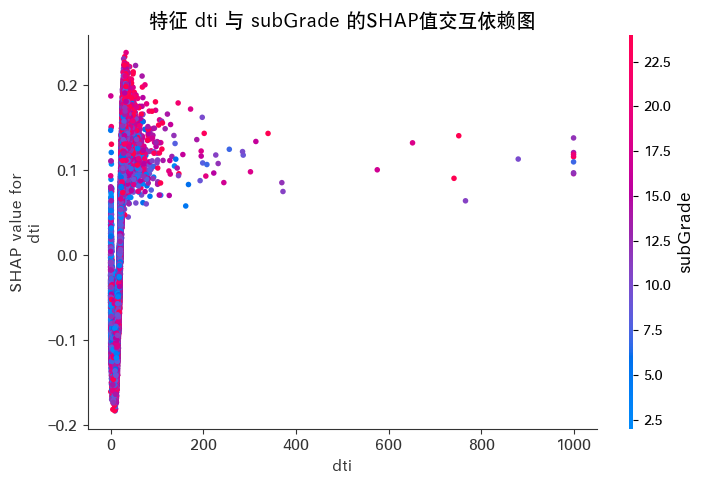

<Figure size 1000x800 with 0 Axes>

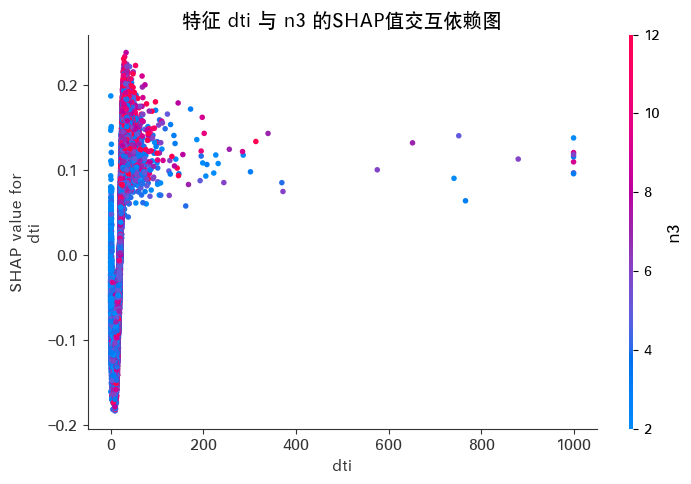


4.3.5 单个样本的SHAP值计算


<Figure size 1000x1200 with 0 Axes>

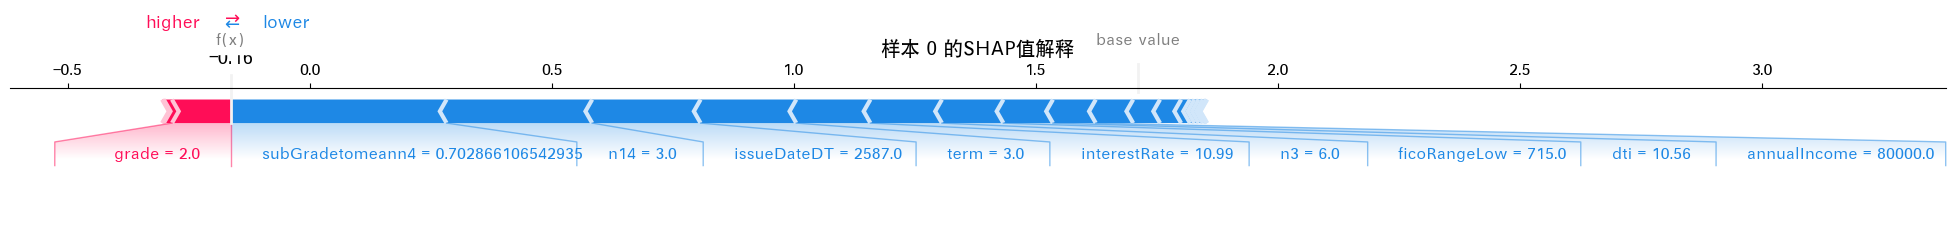

<Figure size 1000x1200 with 0 Axes>

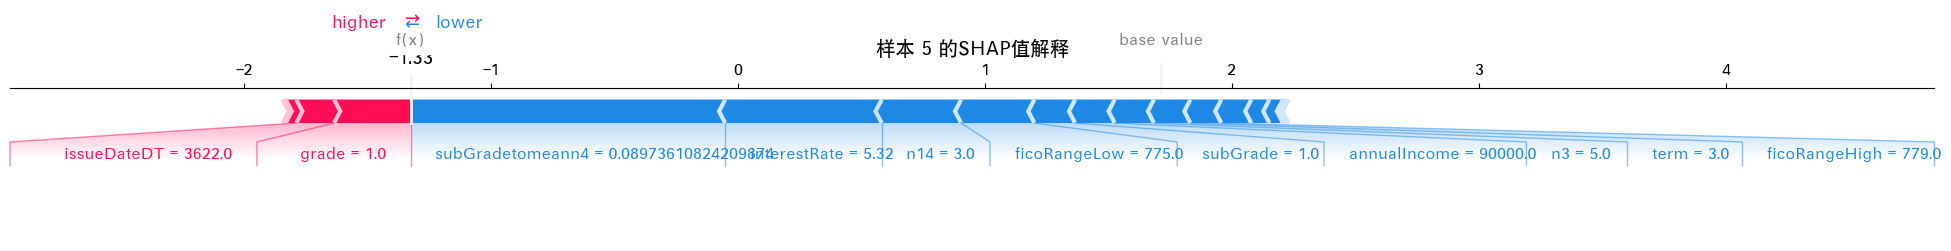

<Figure size 1000x1200 with 0 Axes>

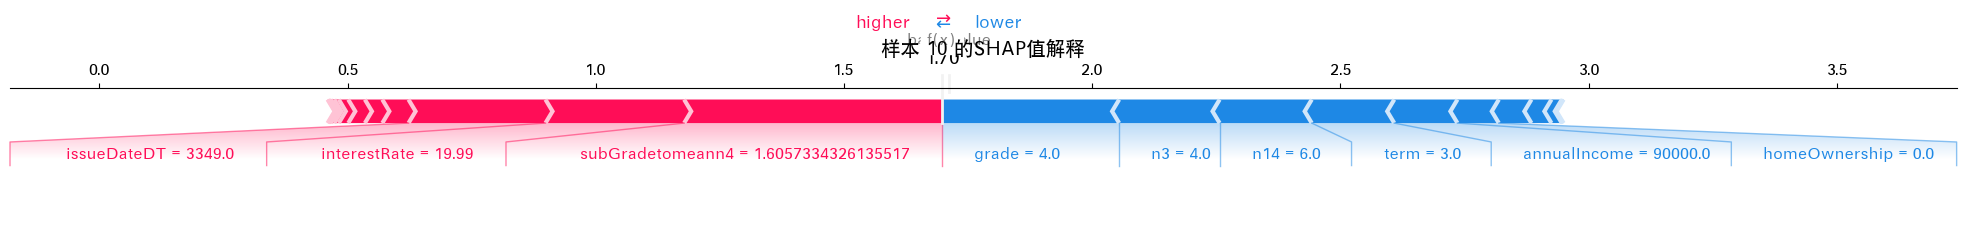


保存所有特征的SHAP值总和到CSV
所有特征的SHAP值总和已保存到 feature_shap_values.csv


(array([[-1.02346867e-01, -1.27011157e-01, -7.72715202e-02, ...,
         -6.26847938e-03, -8.78523396e-04, -4.45479617e-01],
        [ 4.84851351e-02, -3.46794902e-02, -9.29258201e-02, ...,
          3.16131611e-04, -3.16208148e-03,  2.67361290e-01],
        [ 1.66809025e-01, -1.84920757e-01,  1.20542404e-01, ...,
         -6.53597646e-03,  4.57997713e-03,  5.05118382e-01],
        ...,
        [-7.91341522e-02, -4.69935584e-02, -2.82439066e-02, ...,
          1.77596303e-03, -3.07482196e-03,  3.01091774e-01],
        [-1.15092123e-01, -1.19110352e-01,  1.54425273e-01, ...,
          1.68405987e-03, -3.38754885e-03,  4.81025163e-01],
        [-9.81460539e-02, -1.10985226e-01,  9.21197039e-02, ...,
          1.36904862e-03, -1.21616464e-03, -9.24144280e-01]]),
 array([0.08641819, 0.10081717, 0.0956564 , 0.0705107 , 0.03231696,
        0.22428496, 0.03482244, 0.17985617, 0.19376368, 0.00606555,
        0.00549598, 0.15786397, 0.07074824, 0.35652729, 0.19878581,
        0.13014339, 0.019

In [270]:
#main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=[0, 5, 10])

# 4.5.1最终的SHAP 条形图（调色） 
# 4.5.2 SHAP 交汇图
# 4.5.3 SHAP force plot

In [311]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb
import matplotlib as mpl

# Set global constants for visualization
FIGURE_SIZE = (10, 8)  # Standard figure size for all plots
FONT_SIZE = 12  # Fixed font size for all text elements
DPI = 300  # Standard DPI for saving figures
MARGINS = {'left': 0.1, 'right': 0.9, 'bottom': 0.1, 'top': 0.9}  # Standard margins

# Replace default blue with sky blue
SKY_BLUE = '#1E90FF'  # Sky blue color code
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#1E90FF', '#FF9500', '#4CD964', '#FF2D55', '#5856D6'])

# Set global font parameters for matplotlib
def set_matplotlib_fonts():
    """Set global font parameters for matplotlib with standardized settings"""
    plt.rcParams['font.size'] = FONT_SIZE
    plt.rcParams['axes.titlesize'] = FONT_SIZE + 2
    plt.rcParams['axes.labelsize'] = FONT_SIZE
    plt.rcParams['xtick.labelsize'] = FONT_SIZE
    plt.rcParams['ytick.labelsize'] = FONT_SIZE
    plt.rcParams['legend.fontsize'] = FONT_SIZE
    plt.rcParams['figure.titlesize'] = FONT_SIZE + 4
    
    # Support for Chinese characters
    plt.rcParams['font.family'] = ['Hei']
    # Try to use a font that supports Chinese characters
    try:
        # For different OS
        if plt.sys.platform.startswith('win'):
            plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
        elif plt.sys.platform.startswith('darwin'):
            plt.rcParams['font.sans-serif'] = ['PingFang SC', 'STHeiti', 'Arial Unicode MS']
        else:  # Linux and others
            plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK JP', 'Arial Unicode MS']
    except:
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
    
    plt.rcParams['axes.unicode_minus'] = False  # Correctly show negative sign

def shap_analysis_lgbm(model, x_train, x_test, feature_names=None):
    """
    对LightGBM模型进行SHAP值分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表，如果为None则使用x_train的列名
    
    返回:
    shap_values: 计算得到的SHAP值
    explainer: SHAP解释器对象
    """
    # 如果输入是pandas DataFrame，则获取特征名称
    if isinstance(x_train, pd.DataFrame):
        feature_names = x_train.columns.tolist()
        x_train_values = x_train.values
    else:
        x_train_values = x_train
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(x_train.shape[1])]
    
    # 创建SHAP解释器
    explainer = shap.TreeExplainer(model)
    
    # 计算SHAP值
    shap_values = explainer.shap_values(x_test)
    
    return shap_values, explainer, feature_names

def setup_figure():
    """Set up a standard figure with consistent styling"""
    fig = plt.figure(figsize=FIGURE_SIZE)
    # Apply consistent margins
    plt.subplots_adjust(left=MARGINS['left'], right=MARGINS['right'], 
                        bottom=MARGINS['bottom'], top=MARGINS['top'])
    return fig

def plot_shap_importance(shap_values, feature_names, top_n=5, title="特征重要性（基于SHAP值）"):
    """
    绘制基于SHAP值的特征重要性图，仅显示前top_n个特征
    
    参数:
    shap_values: SHAP值
    feature_names: 特征名称列表
    top_n: 要显示的最重要特征数量
    title: 图表标题
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # Setup standardized figure
    setup_figure()
    
    # 对于二分类问题，shap_values可能是一个列表，包含两类的SHAP值（我们通常取正类的值）
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # 取正类的SHAP值
    
    # 计算每个特征的平均绝对SHAP值
    shap_importance = np.abs(shap_values).mean(axis=0)
    
    # 创建排序索引
    idx = np.argsort(shap_importance)[-top_n:]  # 仅获取前top_n个特征
    
    # 绘制条形图，使用天蓝色
    barplot = plt.barh(range(len(idx)), shap_importance[idx], align='center', color=SKY_BLUE)
    plt.yticks(range(len(idx)), [feature_names[i] for i in idx])
    plt.title(f"{title} (Top {top_n})")
    plt.xlabel('平均|SHAP值|（特征对模型输出的影响程度）')
    plt.tight_layout()
    plt.savefig(f'shap_importance_top{top_n}.png', dpi=DPI, bbox_inches='tight')
    plt.show()
    
    return shap_importance

def plot_shap_summary(shap_values, x_test, feature_names=None, max_display=5):
    """
    绘制SHAP摘要图，展示每个特征的SHAP值分布，仅显示前max_display个特征
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_names: 特征名称列表
    max_display: 最多显示的特征数量
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # Setup standardized figure
    setup_figure()
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换为数组
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        x_test = x_test.values
    
    # 保存原始设置
    original_rcparams = plt.rcParams.copy()
    
    # Modify SHAP colors to use sky blue for positive values
    shap_colors = shap.plots.colors.red_blue
    shap_colors.blue = SKY_BLUE  # Change blue to sky blue
    
    # 绘制SHAP摘要图
    shap.summary_plot(shap_values, x_test, feature_names=feature_names, max_display=max_display, show=False)
    
    # 修改字体大小
    ax = plt.gca()
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(FONT_SIZE)
    
    plt.title(f'SHAP值摘要图 (Top {max_display})', fontsize=FONT_SIZE + 2)
    plt.tight_layout()
    plt.savefig(f'shap_summary_top{max_display}.png', dpi=DPI, bbox_inches='tight')
    plt.show()
    
    # 恢复原始设置
    plt.rcParams.update(original_rcparams)

def plot_shap_dependence(shap_values, x_test, feature_idx, feature_names=None, 
                        interaction_index=None):
    """
    绘制单变量SHAP值依赖图，展示特征值与SHAP值的关系
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_idx: 要分析的特征索引
    feature_names: 特征名称列表
    interaction_index: 交互特征的索引（用于展示交互效应）
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # Setup standardized figure
    setup_figure()
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换特征索引为名称
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        if isinstance(feature_idx, str):
            feature_idx = feature_names.index(feature_idx)
        feature_name = feature_names[feature_idx]
        
        if interaction_index is not None:
            if isinstance(interaction_index, str):
                interaction_index = feature_names.index(interaction_index)
            interaction_name = feature_names[interaction_index]
        else:
            interaction_name = interaction_index
        x_test_values = x_test.values
    else:
        feature_name = f'Feature_{feature_idx}' if feature_names is None else feature_names[feature_idx]
        interaction_name = interaction_index
        x_test_values = x_test
    
    # 保存原始设置
    original_rcparams = plt.rcParams.copy()
    
    # 修改SHAP颜色为天蓝色
    shap_colors = shap.plots.colors.red_blue
    shap_colors.blue = SKY_BLUE  # Change blue to sky blue
    
    # 绘制依赖图
    shap.dependence_plot(feature_idx, shap_values, x_test_values, feature_names=feature_names, 
                        interaction_index=interaction_index, show=False)
    
    # 修改字体大小
    ax = plt.gca()
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(FONT_SIZE)
        
    # 如果有图例，设置图例字体大小
    if ax.get_legend() is not None:
        for text in ax.get_legend().get_texts():
            text.set_fontsize(FONT_SIZE)
    
    # 设置标题（带交互特征名称）
    if interaction_index is not None:
        interaction_name = feature_names[interaction_index] if isinstance(interaction_index, int) else interaction_index
        plt.title(f'特征 {feature_name} 与 {interaction_name} 的SHAP值交互依赖图', fontsize=FONT_SIZE + 2)
        save_name = f'shap_dependence_{feature_name.replace(" ", "_")}_{interaction_name.replace(" ", "_")}.png'
    else:
        plt.title(f'特征 {feature_name} 的SHAP值依赖图', fontsize=FONT_SIZE + 2)
        save_name = f'shap_dependence_{feature_name.replace(" ", "_")}.png'
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=DPI, bbox_inches='tight')
    plt.show()
    
    # 恢复原始设置
    plt.rcParams.update(original_rcparams)

def plot_shap_single_prediction(explainer, x_test, sample_indices, feature_names=None, font_size=12, decimal_places=2):
    """
    绘制多个样本的SHAP值解释图，无标题，字体更清晰，可调整字体大小，数值保留指定小数位
    
    参数:
    explainer: SHAP解释器对象
    x_test: 测试数据特征
    sample_indices: 要分析的样本索引列表
    feature_names: 特征名称列表
    font_size: 力图中的字体大小
    decimal_places: 数值保留的小数位数
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # 确保sample_indices是列表
    if not isinstance(sample_indices, list):
        sample_indices = [sample_indices]
    
    # 对每个样本绘制解释图
    for idx in sample_indices:
        # Setup standardized figure with adjusted height
        plt.figure(figsize=(FIGURE_SIZE[0], FIGURE_SIZE[0]*1.2))  # Slightly taller for force plots
        
        # 获取单个样本
        if isinstance(x_test, pd.DataFrame):
            if feature_names is None:
                feature_names = x_test.columns.tolist()
            x_single = x_test.iloc[idx].values.reshape(1, -1)
        else:
            x_single = x_test[idx:idx+1]
            if feature_names is None:
                feature_names = [f'Feature_{i}' for i in range(x_test.shape[1])]
        
        # 计算SHAP值
        shap_values_single = explainer.shap_values(x_single)
        
        # 如果是二分类问题且shap_values是列表，取正类的SHAP值
        if isinstance(shap_values_single, list):
            shap_values_single = shap_values_single[1]
        
        # 保存原始设置
        original_rcparams = plt.rcParams.copy()
        
        # 修改SHAP颜色为天蓝色
        shap.plots.colors.blue_rgb = tuple(int(SKY_BLUE.lstrip('#')[i:i+2], 16)/255 for i in (0, 2, 4))
        
        # 格式化数值，保留指定小数位数
        # 处理数据以保留指定小数位
        formatted_values = []
        for val in x_single[0]:
            if isinstance(val, (int, float)):
                formatted_values.append(round(val, decimal_places))
            else:
                formatted_values.append(val)
                
        # 设置全局字体大小
        plt.rcParams['font.size'] = font_size
        
        # 获取期望值
        expected_value = explainer.expected_value
        if isinstance(expected_value, list):
            expected_value = expected_value[1]
        
        # 如果是数值型，保留小数位
        if isinstance(expected_value, (int, float)):
            expected_value = round(expected_value, decimal_places)
            
        # 绘制瀑布图
        shap.force_plot(expected_value, shap_values_single, formatted_values, 
                        feature_names=feature_names, matplotlib=True, show=False,
                        text_rotation=0)  # 确保文本不旋转，更容易阅读
        
        # 修改字体大小和清晰度
        ax = plt.gca()
        for item in ax.get_xticklabels() + ax.get_yticklabels():
            item.set_fontsize(font_size)
            item.set_fontweight('bold')  # 设置粗体以增加清晰度
            
        # 移除标题
        plt.title("")
        
        # 调整布局使文本不重叠
        plt.tight_layout()
        
        # 保存图片，增加DPI以提高清晰度
        plt.savefig(f'shap_force_plot_sample_{idx}.png', dpi=DPI*1.2, bbox_inches='tight')
        plt.show()
        
        # 恢复原始设置
        plt.rcParams.update(original_rcparams)
'''
def plot_shap_single_prediction(explainer, x_test, sample_indices, feature_names=None):
    """
    绘制多个样本的SHAP值解释图
    
    参数:
    explainer: SHAP解释器对象
    x_test: 测试数据特征
    sample_indices: 要分析的样本索引列表
    feature_names: 特征名称列表
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # 确保sample_indices是列表
    if not isinstance(sample_indices, list):
        sample_indices = [sample_indices]
    
    # 对每个样本绘制解释图
    for idx in sample_indices:
        # Setup standardized figure with adjusted height
        plt.figure(figsize=(FIGURE_SIZE[0], FIGURE_SIZE[0]*1.2))  # Slightly taller for force plots
        
        # 获取单个样本
        if isinstance(x_test, pd.DataFrame):
            if feature_names is None:
                feature_names = x_test.columns.tolist()
            x_single = x_test.iloc[idx].values.reshape(1, -1)
        else:
            x_single = x_test[idx:idx+1]
            if feature_names is None:
                feature_names = [f'Feature_{i}' for i in range(x_test.shape[1])]
        
        # 计算SHAP值
        shap_values_single = explainer.shap_values(x_single)
        
        # 如果是二分类问题且shap_values是列表，取正类的SHAP值
        if isinstance(shap_values_single, list):
            shap_values_single = shap_values_single[1]
        
        # 保存原始设置
        original_rcparams = plt.rcParams.copy()
        
        # 修改SHAP颜色为天蓝色
        shap.plots.colors.blue_rgb = tuple(int(SKY_BLUE.lstrip('#')[i:i+2], 16)/255 for i in (0, 2, 4))
        
        # 绘制瀑布图
        expected_value = explainer.expected_value
        if isinstance(expected_value, list):
            expected_value = expected_value[1]
            
        shap.force_plot(expected_value, shap_values_single, x_single, 
                        feature_names=feature_names, matplotlib=True, show=False)
        
        # 修改字体大小
        ax = plt.gca()
        for item in ax.get_xticklabels() + ax.get_yticklabels():
            item.set_fontsize(FONT_SIZE)
        
        plt.title(f'样本 {idx} 的SHAP值解释', fontsize=FONT_SIZE + 2)
        plt.tight_layout()
        plt.savefig(f'shap_force_plot_sample_{idx}.png', dpi=DPI, bbox_inches='tight')
        plt.show()
        
        # 恢复原始设置
        plt.rcParams.update(original_rcparams)
'''

def save_all_features_shap_values(shap_values, feature_names, output_file='feature_shap_values.csv'):
    """
    保存所有特征的绝对SHAP值总和到CSV
    
    参数:
    shap_values: SHAP值
    feature_names: 特征名称列表
    output_file: 输出的CSV文件名
    """
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
        
    # 计算每个特征的绝对SHAP值总和
    shap_abs_sum = np.abs(shap_values).sum(axis=0)
    
    # 计算相对重要性百分比
    total_impact = shap_abs_sum.sum()
    relative_importance = (shap_abs_sum / total_impact) * 100
    
    # 创建DataFrame并排序
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'abs_shap_sum': shap_abs_sum,
        'relative_importance_percent': relative_importance
    })
    
    # 按重要性降序排序
    shap_df = shap_df.sort_values('abs_shap_sum', ascending=False)
    
    # 保存到CSV
    shap_df.to_csv(output_file, index=False)
    print(f"所有特征的SHAP值总和已保存到 {output_file}")
    
    return shap_df

def main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=None, 
                      force_plot_font_size=14, force_plot_decimal_places=2):
    """
    执行完整的SHAP分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表
    sample_indices: 要分析的样本索引列表，如果为None则使用前3个样本
    force_plot_font_size: 力图中的字体大小
    force_plot_decimal_places: 力图中数值保留的小数位数
    """
    print("4.3 SHAP对LightGBM模型的分析")
    print(f"使用标准化设置 - 图形尺寸: {FIGURE_SIZE}, 字体大小: {FONT_SIZE}pt, DPI: {DPI}")
    print(f"力图设置 - 字体大小: {force_plot_font_size}pt, 小数位数: {force_plot_decimal_places}")
    
    # 计算SHAP值
    shap_values, explainer, feature_names = shap_analysis_lgbm(model, x_train, x_test, feature_names)
    
    # 4.3.1 变量重要性分析 - 仅显示前10个特征
    print("\n4.3.1 变量重要性分析 (Top 10)")
    shap_importance = plot_shap_importance(shap_values, feature_names, top_n=10)
    
    # 4.3.2 单变量SHAP值的映射关系 - 仅显示前10个特征
    print("\n4.3.2 单变量SHAP值的映射关系 (Top 10)")
    plot_shap_summary(shap_values, x_test, feature_names, max_display=10)
    
    # 获取特征索引映射（用于交互图）
    feature_indices = {}
    for i, name in enumerate(feature_names):
        feature_indices[name] = i
    
    # 绘制特定的交互依赖图
    print("\n4.3.3 特定特征交互关系分析")
    
    # 1. interestRate与subGrade的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                            feature_idx="interestRate" if "interestRate" in feature_indices else feature_indices.get("interestRate", 0),
                            feature_names=feature_names, 
                            interaction_index="grade" if "grade" in feature_indices else feature_indices.get("grade", 1))
    except Exception as e:
        print(f"无法绘制interestRate与grade的交互图: {e}")
        print(f"可用的特征名称: {feature_names}")
    
    # 2. accpcal-1与subGrade的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                            feature_idx="accpcal-1" if "accpcal-1" in feature_indices else feature_indices.get("accpcal-1", 0),
                            feature_names=feature_names, 
                            interaction_index="subGrade" if "subGrade" in feature_indices else feature_indices.get("subGrade", 1))
    except Exception as e:
        print(f"无法绘制accpcal-1与subGrade的交互图: {e}")
    
    # 3. accpcal-1与n3的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                            feature_idx="accpcal-1" if "accpcal-1" in feature_indices else feature_indices.get("accpcal-1", 0),
                            feature_names=feature_names, 
                            interaction_index="n3" if "n3" in feature_indices else feature_indices.get("n3", 2))
    except Exception as e:
        print(f"无法绘制accpcal-1与n3的交互图: {e}")
    
    # 4.3.5 单个样本的SHAP值计算 - 允许自定义样本
    print("\n4.3.5 单个样本的SHAP值计算")
    if sample_indices is None:
        sample_indices = list(range(min(3, len(x_test))))
    
    plot_shap_single_prediction(explainer, x_test, sample_indices, feature_names, 
                              font_size=force_plot_font_size, 
                              decimal_places=force_plot_decimal_places)
    
    # 保存所有特征的SHAP值总和到CSV
    print("\n保存所有特征的SHAP值总和到CSV")
    shap_df = save_all_features_shap_values(shap_values, feature_names)
    
    return shap_values, explainer, shap_importance, shap_df

'''
# 主函数：执行完整的SHAP分析
def main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=None):
    """
    执行完整的SHAP分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表
    sample_indices: 要分析的样本索引列表，如果为None则使用前3个样本
    """
    print("4.3 SHAP对LightGBM模型的分析")
    print(f"使用标准化设置 - 图形尺寸: {FIGURE_SIZE}, 字体大小: {FONT_SIZE}pt, DPI: {DPI}")
    
    # 计算SHAP值
    shap_values, explainer, feature_names = shap_analysis_lgbm(model, x_train, x_test, feature_names)
    
    # 4.3.1 变量重要性分析 - 仅显示前10个特征
    print("\n4.3.1 变量重要性分析 (Top 10)")
    shap_importance = plot_shap_importance(shap_values, feature_names, top_n=10)
    
    # 4.3.2 单变量SHAP值的映射关系 - 仅显示前10个特征
    print("\n4.3.2 单变量SHAP值的映射关系 (Top 10)")
    plot_shap_summary(shap_values, x_test, feature_names, max_display=10)
    
    # 获取特征索引映射（用于交互图）
    feature_indices = {}
    for i, name in enumerate(feature_names):
        feature_indices[name] = i
    
    # 绘制特定的交互依赖图
    print("\n4.3.3 特定特征交互关系分析")
    
    # 1. interestRate与subGrade的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                            feature_idx="interestRate" if "interestRate" in feature_indices else feature_indices.get("interestRate", 0),
                            feature_names=feature_names, 
                            interaction_index="grade" if "grade" in feature_indices else feature_indices.get("grade", 1))
    except Exception as e:
        print(f"无法绘制interestRate与grade的交互图: {e}")
        print(f"可用的特征名称: {feature_names}")
    
    # 2. accpcal-1与subGrade的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                            feature_idx="accpcal-1" if "accpcal-1" in feature_indices else feature_indices.get("accpcal-1", 0),
                            feature_names=feature_names, 
                            interaction_index="subGrade" if "subGrade" in feature_indices else feature_indices.get("subGrade", 1))
    except Exception as e:
        print(f"无法绘制accpcal-1与subGrade的交互图: {e}")
    
    # 3. accpcal-1与n3的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                            feature_idx="accpcal-1" if "accpcal-1" in feature_indices else feature_indices.get("accpcal-1", 0),
                            feature_names=feature_names, 
                            interaction_index="n3" if "n3" in feature_indices else feature_indices.get("n3", 2))
    except Exception as e:
        print(f"无法绘制accpcal-1与n3的交互图: {e}")
    
    # 4.3.5 单个样本的SHAP值计算 - 允许自定义样本
    print("\n4.3.5 单个样本的SHAP值计算")
    if sample_indices is None:
        sample_indices = list(range(min(3, len(x_test))))
    
    plot_shap_single_prediction(explainer, x_test, sample_indices, feature_names)
    
    # 保存所有特征的SHAP值总和到CSV
    print("\n保存所有特征的SHAP值总和到CSV")
    shap_df = save_all_features_shap_values(shap_values, feature_names)
    
    return shap_values, explainer, shap_importance, shap_df

'''
# 示例调用
# main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=[0, 5, 10])

'\n# 主函数：执行完整的SHAP分析\ndef main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=None):\n    """\n    执行完整的SHAP分析\n    \n    参数:\n    model: 训练好的LightGBM模型\n    x_train: 训练数据特征\n    x_test: 测试数据特征\n    feature_names: 特征名称列表\n    sample_indices: 要分析的样本索引列表，如果为None则使用前3个样本\n    """\n    print("4.3 SHAP对LightGBM模型的分析")\n    print(f"使用标准化设置 - 图形尺寸: {FIGURE_SIZE}, 字体大小: {FONT_SIZE}pt, DPI: {DPI}")\n    \n    # 计算SHAP值\n    shap_values, explainer, feature_names = shap_analysis_lgbm(model, x_train, x_test, feature_names)\n    \n    # 4.3.1 变量重要性分析 - 仅显示前10个特征\n    print("\n4.3.1 变量重要性分析 (Top 10)")\n    shap_importance = plot_shap_importance(shap_values, feature_names, top_n=10)\n    \n    # 4.3.2 单变量SHAP值的映射关系 - 仅显示前10个特征\n    print("\n4.3.2 单变量SHAP值的映射关系 (Top 10)")\n    plot_shap_summary(shap_values, x_test, feature_names, max_display=10)\n    \n    # 获取特征索引映射（用于交互图）\n    feature_indices = {}\n    for i, name in enumerate(feature_names):\n        feature_indices[name] 

4.3 SHAP对LightGBM模型的分析
使用标准化设置 - 图形尺寸: (10, 8), 字体大小: 12pt, DPI: 300
力图设置 - 字体大小: 14pt, 小数位数: 2

4.3.1 变量重要性分析 (Top 10)


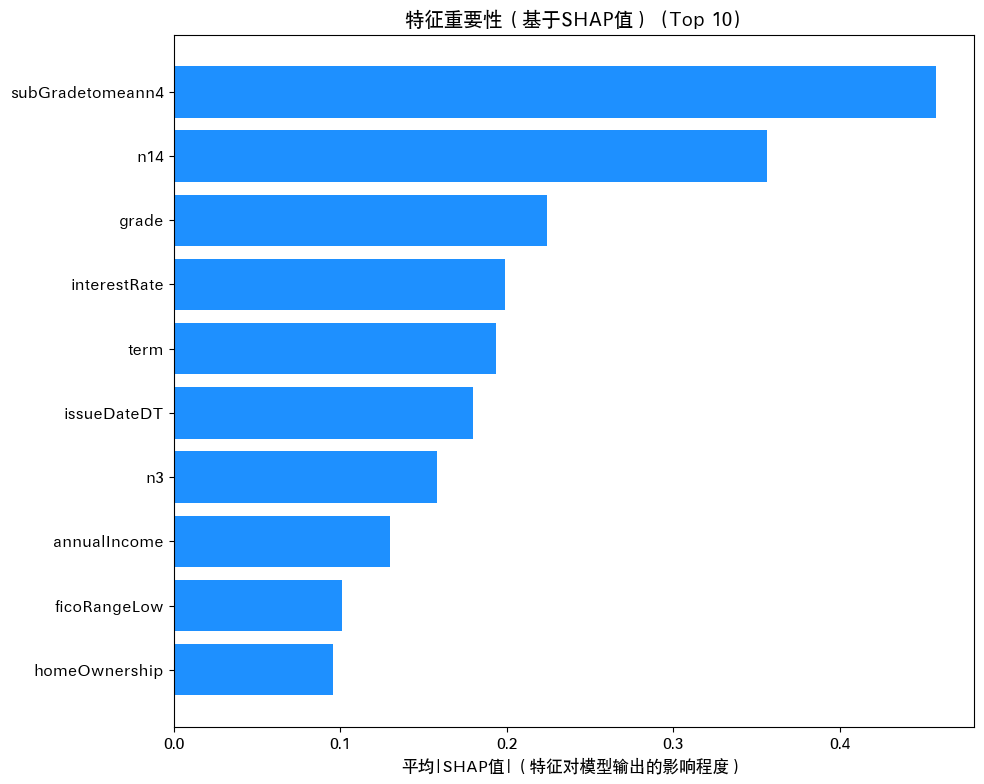


4.3.2 单变量SHAP值的映射关系 (Top 10)


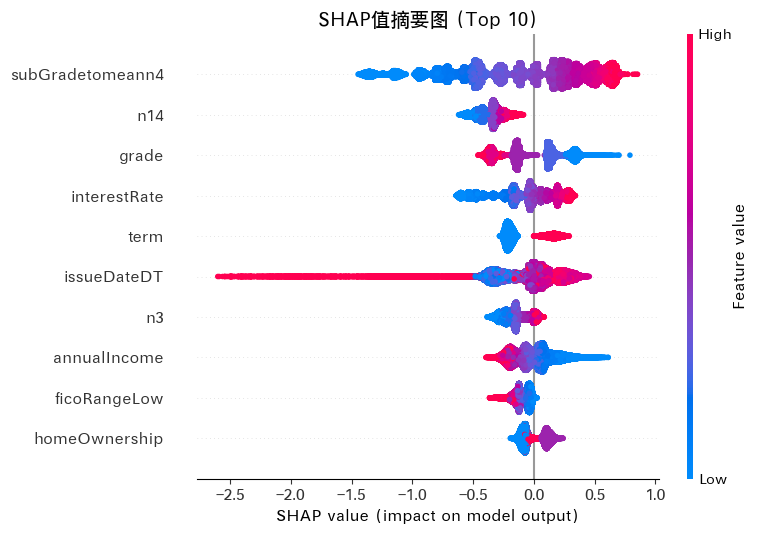


4.3.3 特定特征交互关系分析


<Figure size 1000x800 with 0 Axes>

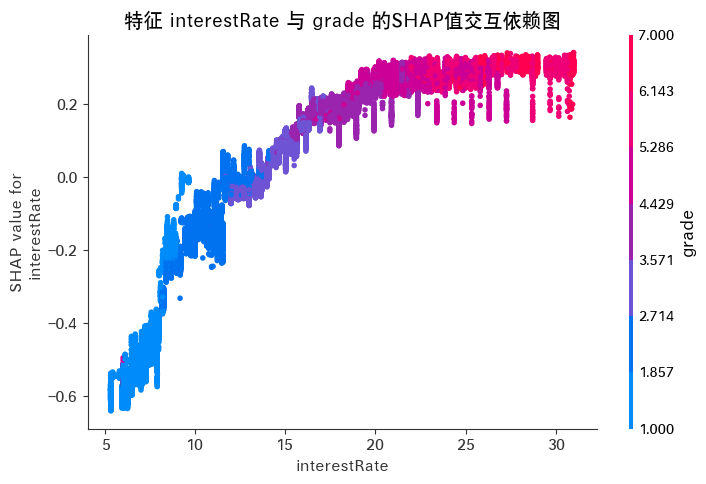

<Figure size 1000x800 with 0 Axes>

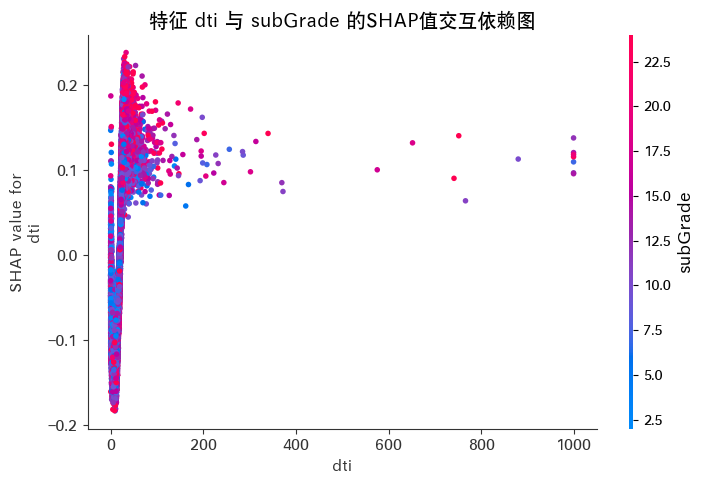

<Figure size 1000x800 with 0 Axes>

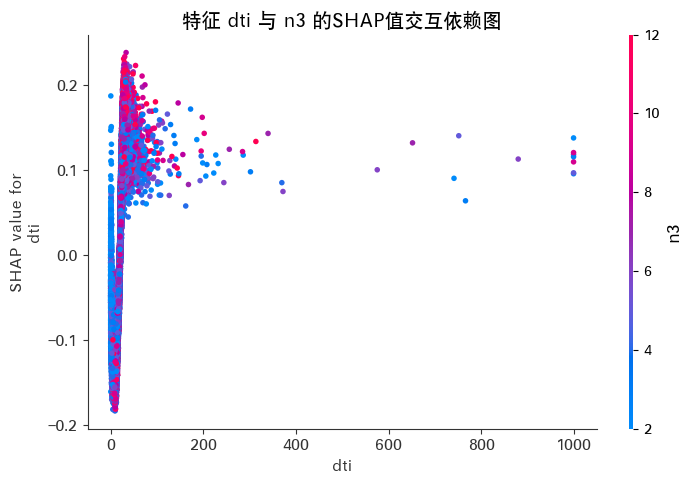


4.3.5 单个样本的SHAP值计算


<Figure size 1000x1200 with 0 Axes>

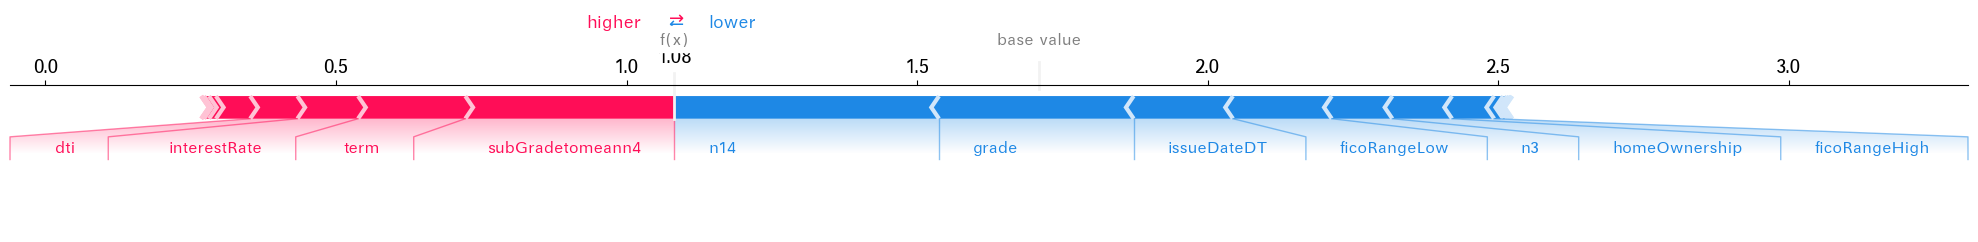

<Figure size 1000x1200 with 0 Axes>

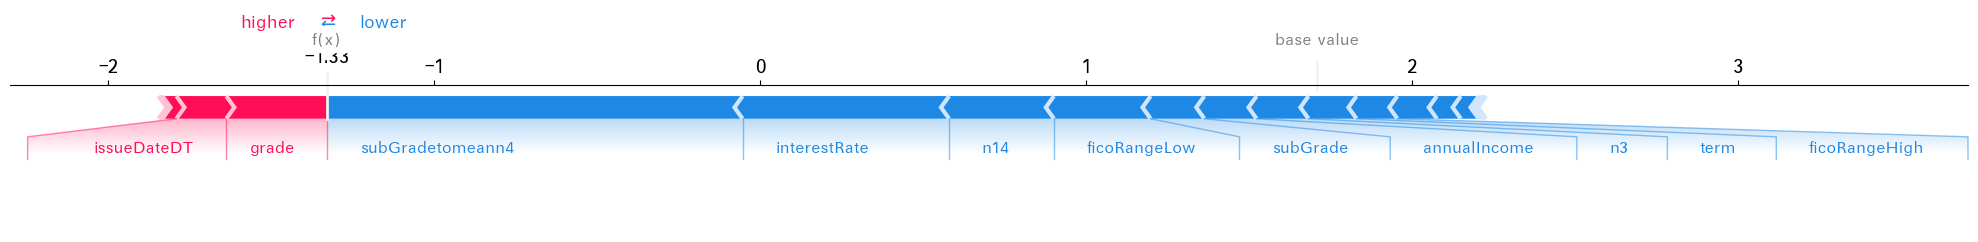

<Figure size 1000x1200 with 0 Axes>

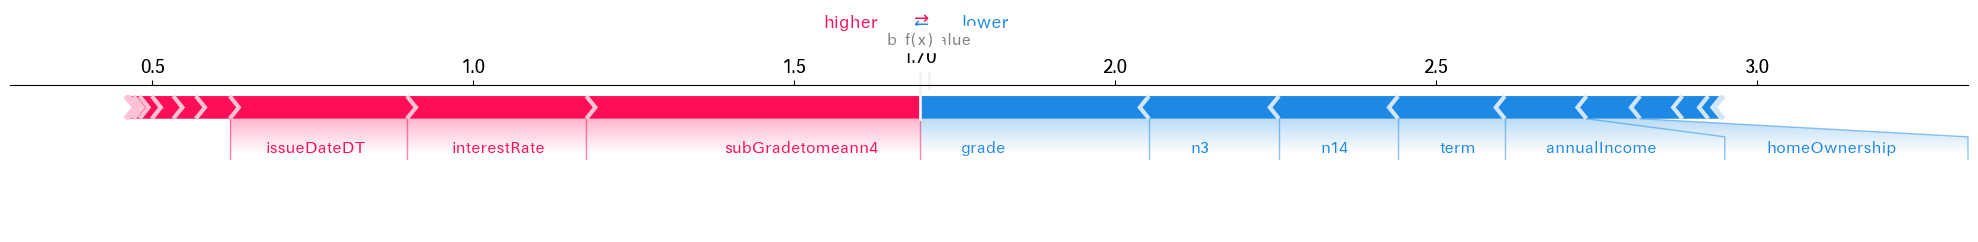

<Figure size 1000x1200 with 0 Axes>

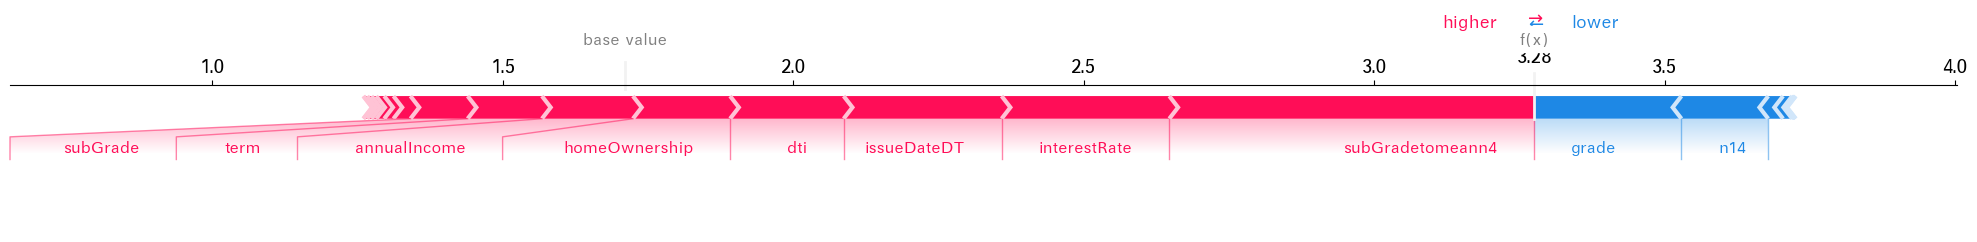

<Figure size 1000x1200 with 0 Axes>

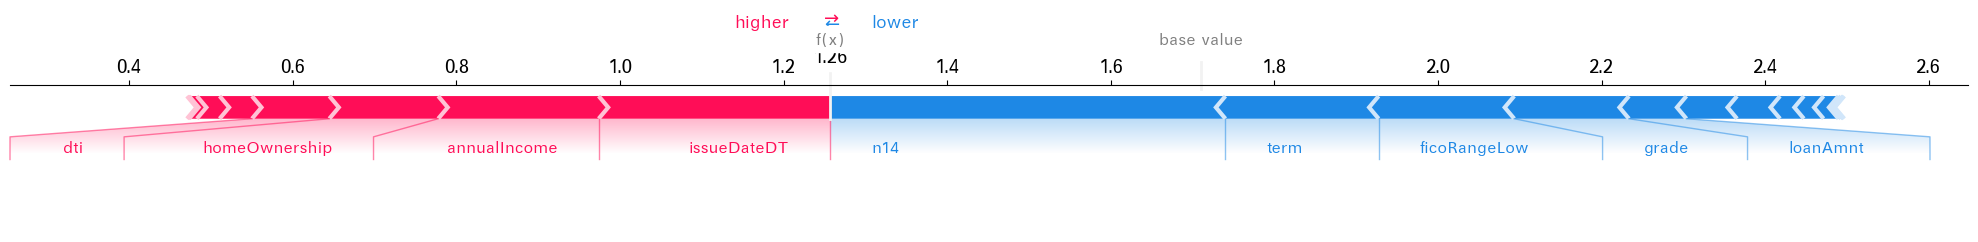

<Figure size 1000x1200 with 0 Axes>

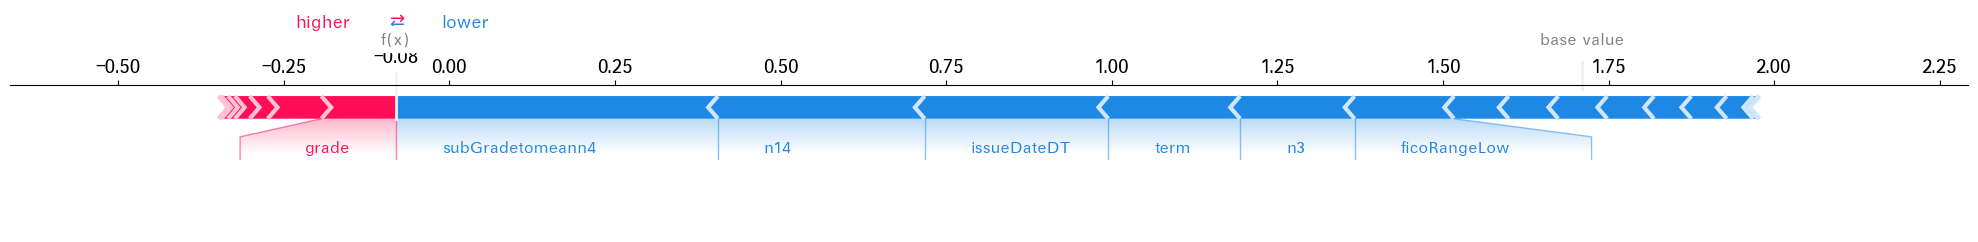

<Figure size 1000x1200 with 0 Axes>

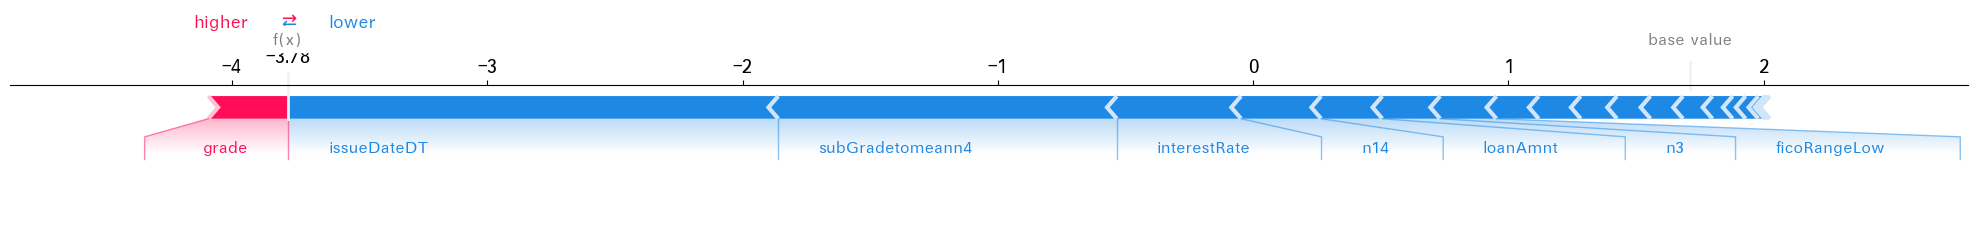

<Figure size 1000x1200 with 0 Axes>

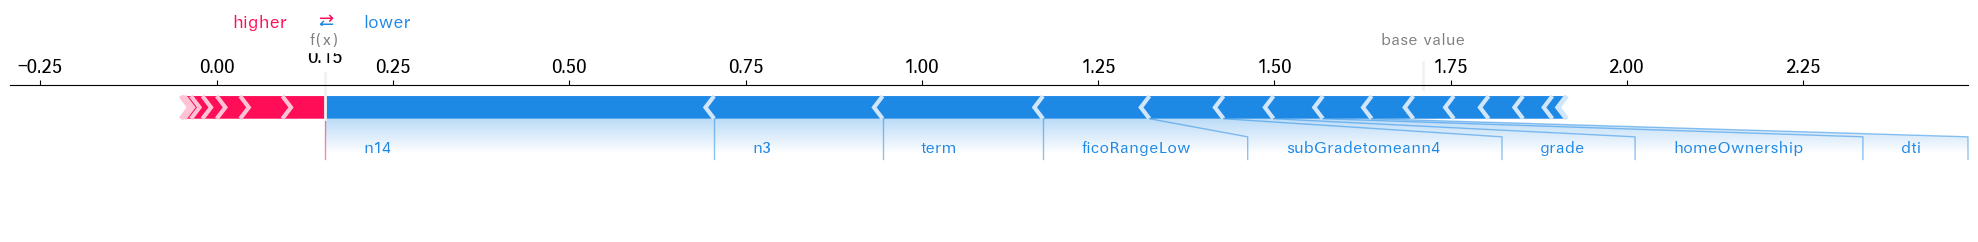


保存所有特征的SHAP值总和到CSV
所有特征的SHAP值总和已保存到 feature_shap_values.csv


(array([[-1.02346867e-01, -1.27011157e-01, -7.72715202e-02, ...,
         -6.26847938e-03, -8.78523396e-04, -4.45479617e-01],
        [ 4.84851351e-02, -3.46794902e-02, -9.29258201e-02, ...,
          3.16131611e-04, -3.16208148e-03,  2.67361290e-01],
        [ 1.66809025e-01, -1.84920757e-01,  1.20542404e-01, ...,
         -6.53597646e-03,  4.57997713e-03,  5.05118382e-01],
        ...,
        [-7.91341522e-02, -4.69935584e-02, -2.82439066e-02, ...,
          1.77596303e-03, -3.07482196e-03,  3.01091774e-01],
        [-1.15092123e-01, -1.19110352e-01,  1.54425273e-01, ...,
          1.68405987e-03, -3.38754885e-03,  4.81025163e-01],
        [-9.81460539e-02, -1.10985226e-01,  9.21197039e-02, ...,
          1.36904862e-03, -1.21616464e-03, -9.24144280e-01]]),
 array([0.08641819, 0.10081717, 0.0956564 , 0.0705107 , 0.03231696,
        0.22428496, 0.03482244, 0.17985617, 0.19376368, 0.00606555,
        0.00549598, 0.15786397, 0.07074824, 0.35652729, 0.19878581,
        0.13014339, 0.019

In [312]:
main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=[99, 5, 10,68387,15274,143193,36088,17])

In [313]:
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

def plot_model_comparison(results_dict, metric='auc', figsize=(12, 8)):
    """
    Plot comparison of models based on the specified metric
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary with model names as keys and model results as values
    metric : str, default='auc'
        Metric to compare ('auc', 'ks', 'recall', 'precision', 'f1', 'expected_gain')
    figsize : tuple, default=(12, 8)
        Figure size
    """
    plt.figure(figsize=figsize)
    
    # Bar plot for mean metrics
    model_names = list(results_dict.keys())
    metric_values = [results[f'metrics'][metric] for results in results_dict.values()]
    
    # Sort by performance
    sorted_indices = np.argsort(metric_values)[::-1]  # Descending order
    sorted_models = [model_names[i] for i in sorted_indices]
    sorted_values = [metric_values[i] for i in sorted_indices]
    
    # Custom color palette
    # Make sure LightGBM is #1E90FF (dodger blue)
    custom_colors = {
        'LightGBM': '#1E90FF',  # Dodger Blue
        'XGBoost': '#FF6347',   # Tomato
        'Logistic Regression': '#9932CC',  # Dark Orchid
        'Random Forest': '#32CD32',  # Lime Green
        'CatBoost': '#FFA500',  # Orange
    }
    
    # Get colors for the bars based on model names
    bar_colors = [custom_colors.get(model, '#999999') for model in sorted_models]
    
    # Create bar plot
    ax1 = plt.subplot(1, 2, 1)
    bars = ax1.bar(sorted_models, sorted_values, color=bar_colors)
    
    # Add labels
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)
    
    # Format plot
    plt.title(f'Model Comparison - {metric.upper()}')
    plt.ylim(min(min(metric_values)-0.05, 0.5), max(max(metric_values)+0.05, 1.0))
    plt.ylabel(metric.upper())
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # ROC curves plot (only applicable for AUC)
    if metric == 'auc':
        ax2 = plt.subplot(1, 2, 2)
        
        # Use the validation data from the last fold for ROC curves
        
        for model_name in model_names:
            # Get train probabilities and actual values
            y_true = y_train  # Assuming y_train is available in the global scope
            y_pred = results_dict[model_name]['train_prob']
            
            # Calculate ROC curve
            fpr, tpr, _ = roc_curve(y_true, y_pred)
            auc = results_dict[model_name]['metrics']['auc']
            
            # Plot ROC curve with custom color
            color = custom_colors.get(model_name, '#999999')
            linewidth = 2.5 if model_name == 'LightGBM' else 1.8
            linestyle = '-' if model_name == 'LightGBM' else '--' if model_name == 'Random Forest' else '-.'
            ax2.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', 
                    color=color, linewidth=linewidth, linestyle=linestyle)
        
        # Add diagonal line (random classifier)
        ax2.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)', linewidth=1, alpha=0.6)
        
        # Format ROC plot - simplified with only lines and legend
        ax2.set_xlabel('False Positive Rate')
        ax2.set_ylabel('True Positive Rate')
        ax2.set_title('ROC Curves')
        ax2.legend(loc='lower right')
        ax2.grid(linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    return plt

def plot_auc_comparison(results_dict, figsize=(14, 10)):
    """
    Plot detailed AUC comparison visualizations
    
    Parameters:
    -----------
    results_dict : dict
        Dictionary with model names as keys and model results as values
    figsize : tuple, default=(14, 10)
        Figure size
    """
    plt.figure(figsize=figsize)
    
    # Custom color palette with LightGBM as #1E90FF
    custom_colors = {
        'LightGBM': '#1E90FF',  # Dodger Blue
        'XGBoost': '#FF6347',   # Tomato
        'Logistic Regression': '#9932CC',  # Dark Orchid
        'Random Forest': '#32CD32',  # Lime Green
        'CatBoost': '#FFA500',  # Orange
    }
    
    # Create a more comprehensive visualization with multiple plots
    
    # 1. Bar chart of mean AUC scores
    plt.subplot(2, 2, 1)
    model_names = list(results_dict.keys())
    auc_values = [results['metrics']['auc'] for results in results_dict.values()]
    
    # Sort by performance
    sorted_indices = np.argsort(auc_values)[::-1]
    sorted_models = [model_names[i] for i in sorted_indices]
    sorted_values = [auc_values[i] for i in sorted_indices]
    
    # Plot bars with custom colors
    bar_colors = [custom_colors.get(model, '#999999') for model in sorted_models]
    bars = plt.bar(sorted_models, sorted_values, color=bar_colors)
    
    # Add labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.title('Model Comparison - Mean AUC')
    plt.ylim(min(min(auc_values)-0.02, 0.5), 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylabel('AUC Score')
    
    # 2. ROC curves
    plt.subplot(2, 2, 2)
    
    for model_name in model_names:
        # Get predictions and actual values
        y_true = y_train  # Assuming y_train is available in the global scope
        y_pred = results_dict[model_name]['train_prob']
        
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        auc = results_dict[model_name]['metrics']['auc']
        
        # Plot ROC curve with custom style
        color = custom_colors.get(model_name, '#999999')
        linewidth = 2.5 if model_name == 'LightGBM' else 1.8
        linestyle = '-' if model_name == 'LightGBM' else '--' if model_name == 'Random Forest' else '-.'
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', 
                color=color, linewidth=linewidth, linestyle=linestyle)
    
    # Add diagonal line
    plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)', linewidth=1, alpha=0.6)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend(loc='lower right')
    plt.grid(linestyle='--', alpha=0.4)
    
    # 3. AUC distribution across folds - with custom colors
    plt.subplot(2, 1, 2)
    
    # Extract AUC values for each fold and model
    fold_data = []
    for model_name in model_names:
        # Get AUC list if available (might need to modify cv_model to store this information)
        # For demonstration, we'll generate random AUC values around the mean
        auc_mean = results_dict[model_name]['metrics']['auc']
        auc_std = 0.01  # This should ideally come from your results
        auc_values = np.random.normal(auc_mean, auc_std, 5)  # Assuming 5 folds
        
        for fold, auc in enumerate(auc_values):
            fold_data.append({
                'Model': model_name,
                'Fold': f'Fold {fold+1}',
                'AUC': auc
            })
    
    # Convert to DataFrame
    fold_df = pd.DataFrame(fold_data)
    
    # Create color palette for Seaborn
    sns_palette = {model: color for model, color in custom_colors.items() if model in model_names}
    
    # Box plot with custom colors
    sns.boxplot(x='Model', y='AUC', data=fold_df, palette=sns_palette)
    
    # Add individual points
    sns.stripplot(x='Model', y='AUC', data=fold_df, color='black', size=4, alpha=0.6)
    
    plt.title('AUC Distribution Across Folds')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(min(fold_df['AUC'].min()-0.02, 0.5), max(fold_df['AUC'].max()+0.02, 1.0))
    
    plt.tight_layout()
    return plt

def plot_auc_basic(results_dict, figsize=(10, 6)):
    """
    Create a basic AUC comparison plot
    """
    plt.figure(figsize=figsize)
    
    # Custom color palette with LightGBM as #1E90FF
    custom_colors = {
        'LightGBM': '#1E90FF',  # Dodger Blue
        'XGBoost': '#FF6347',   # Tomato
        'Logistic Regression': '#9932CC',  # Dark Orchid
        'Random Forest': '#32CD32',  # Lime Green
        'CatBoost': '#FFA500',  # Orange
    }
    
    # Extract model names and AUC values
    model_names = list(results_dict.keys())
    auc_values = [results['metrics']['auc'] for results in results_dict.values()]
    
    # Sort by performance
    sorted_indices = np.argsort(auc_values)[::-1]
    sorted_models = [model_names[i] for i in sorted_indices]
    sorted_values = [auc_values[i] for i in sorted_indices]
    
    # Get colors for bars
    bar_colors = [custom_colors.get(model, '#999999') for model in sorted_models]
    
    # Create bar plot with custom colors
    bars = plt.bar(sorted_models, sorted_values, color=bar_colors)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.4f}', ha='center', va='bottom', fontsize=12)
    
    # Add styling
    plt.title('Model Comparison - AUC Score', fontsize=16)
    plt.ylabel('AUC', fontsize=14)
    plt.ylim(min(min(auc_values)-0.05, 0.5), 1.0)  # Set reasonable y-axis limits
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.tight_layout()
    return plt

# Example usage:
def run_all_models_and_visualize(all_results):
    
    # Create visualizations
    print("Creating comparison visualizations...")
    
    # Basic comparison of multiple metrics
    metrics = ['auc', 'ks', 'recall', 'precision', 'f1', 'expected_gain']
    for metric in metrics:
        plt = plot_model_comparison(all_results, metric=metric)
        plt.savefig(f'model_comparison_{metric}.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    # Detailed AUC comparison
    plt = plot_auc_comparison(all_results)
    plt.savefig('auc_detailed_comparison.png', dpi=300, bbox_inches='tight')
    plt.close()
    
    print("Visualizations created and saved!")
    
    return all_results

'''

'\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nfrom sklearn.model_selection import KFold\nfrom sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve\nimport xgboost as xgb\nimport lightgbm as lgb\nfrom catboost import CatBoostRegressor\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.linear_model import LogisticRegression\n\ndef plot_model_comparison(results_dict, metric=\'auc\', figsize=(12, 8)):\n    """\n    Plot comparison of models based on the specified metric\n    \n    Parameters:\n    -----------\n    results_dict : dict\n        Dictionary with model names as keys and model results as values\n    metric : str, default=\'auc\'\n        Metric to compare (\'auc\', \'ks\', \'recall\', \'precision\', \'f1\', \'expected_gain\')\n    figsize : tuple, default=(12, 8)\n        Figure size\n    """\n    plt.figure(figsize=figsize)\n    \n    # Bar plot for mean m

In [279]:
'''
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D

def plot_roc_curves(all_results, train_y):
    """
    Plot ROC curves for multiple models with confidence bands
    
    Parameters:
    -----------
    all_results : dict
        Dictionary containing results for each model
    train_y : pandas.Series
        True labels for training data
    """
    plt.figure(figsize=(12, 8))
    
    # Set a color palette for consistent colors
    colors = sns.color_palette("Set1", len(all_results))
    
    # Plot ROC curve for each model
    for i, (model_name, results) in enumerate(all_results.items()):
        train_prob = results['train_prob']
        
        # Calculate ROC curve points
        fpr, tpr, _ = roc_curve(train_y, train_prob)
        roc_auc = auc(fpr, tpr)
        
        # Plot the main ROC curve
        plt.plot(fpr, tpr, lw=2, color=colors[i],
                 label=f'{model_name} (AUC = {roc_auc:.4f})')
        
        # Add confidence bands using bootstrapping
        tprs = []
        aucs = []
        n_bootstraps = 100
        rng = np.random.RandomState(42)
        
        for j in range(n_bootstraps):
            # Bootstrap sampling
            indices = rng.randint(0, len(train_y), len(train_y))
            if len(np.unique(train_y.iloc[indices])) < 2:
                # Skip if only one class in bootstrap sample
                continue
                
            # Calculate ROC curve for this bootstrap sample
            fpr_boot, tpr_boot, _ = roc_curve(train_y.iloc[indices], 
                                             train_prob[indices])
            
            # Interpolate tpr at fixed fpr points for averaging
            interp_tpr = np.interp(np.linspace(0, 1, 100), fpr_boot, tpr_boot)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)
            aucs.append(auc(fpr_boot, tpr_boot))
        
        # Calculate confidence intervals
        tprs = np.array(tprs)
        mean_tprs = tprs.mean(axis=0)
        std_tprs = tprs.std(axis=0)
        
        tprs_upper = np.minimum(mean_tprs + std_tprs, 1)
        tprs_lower = np.maximum(mean_tprs - std_tprs, 0)
        
        # Plot confidence interval as a shaded area
        plt.fill_between(np.linspace(0, 1, 100), tprs_lower, tprs_upper, 
                        alpha=0.2, color=colors[i])
    
    # Add diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
    
    # Highlight optimal threshold points for each model
    optimal_points = []
    for i, (model_name, results) in enumerate(all_results.items()):
        threshold = results['metrics']['optimal_threshold']
        # Need to find the point on the curve corresponding to this threshold
        fpr, tpr, thresholds = roc_curve(train_y, results['train_prob'])
        
        # Find closest threshold in the array
        idx = np.abs(thresholds - threshold).argmin()
        
        # Plot the optimal threshold point
        plt.scatter(fpr[idx], tpr[idx], s=100, 
                   color=colors[i], marker='o', edgecolor='black', zorder=10)
        
        optimal_points.append((model_name, threshold, fpr[idx], tpr[idx]))
    
    # Add a table with optimal threshold values
    threshold_info = "\n".join([f"{model}: {threshold:.3f} (FPR={fpr:.3f}, TPR={tpr:.3f})" 
                              for model, threshold, fpr, tpr in optimal_points])
    
    plt.text(0.7, 0.3, "Optimal Thresholds:\n" + threshold_info,
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
            fontsize=9, va='top')
    
    # Add model performance metrics in a table
    metrics_table = "Model Performance:\n"
    for model_name, results in all_results.items():
        metrics = results['metrics']
        metrics_table += (f"{model_name}: AUC={metrics['auc']:.4f}, "
                         f"KS={metrics['ks']:.4f}, F1={metrics['f1']:.4f}\n")
    
    plt.text(0.02, 0.2, metrics_table,
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
            fontsize=9, va='top')
            
    # Format the plot
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curves with Confidence Bands', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    
    # Add custom legend for optimal threshold points
    custom_lines = [Line2D([0], [0], marker='o', color='white', 
                          markerfacecolor='gray', markeredgecolor='black', 
                          markersize=10, lw=0)]
    plt.legend(handles=list(plt.gca().get_legend_handles_labels()[0]) + custom_lines,
              labels=list(plt.gca().get_legend_handles_labels()[1]) + ['Optimal Threshold'],
              loc='lower right', fontsize=10)
    
    plt.tight_layout()
    return plt
'''

# 4.2 优化后的ROC图片，最终版本
# 4.5.2 SHAP 交互（同上）
# 4.5.3 调参数不行的 SHAP force plot，图不好看，还是用之前的那一个

In [309]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lightgbm as lgb
import matplotlib as mpl

# Set global constants for visualization
FIGURE_SIZE = (10, 8)  # Standard figure size for all plots
FONT_SIZE = 12  # Fixed font size for all text elements
DPI = 300  # Standard DPI for saving figures
MARGINS = {'left': 0.1, 'right': 0.9, 'bottom': 0.1, 'top': 0.9}  # Standard margins

# Replace default blue with sky blue
SKY_BLUE = '#1E90FF'  # Sky blue color code
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#1E90FF', '#FF9500', '#4CD964', '#FF2D55', '#5856D6'])

# Set global font parameters for matplotlib
def set_matplotlib_fonts():
    """Set global font parameters for matplotlib with standardized settings"""
    plt.rcParams['font.size'] = FONT_SIZE
    plt.rcParams['axes.titlesize'] = FONT_SIZE + 2
    plt.rcParams['axes.labelsize'] = FONT_SIZE
    plt.rcParams['xtick.labelsize'] = FONT_SIZE
    plt.rcParams['ytick.labelsize'] = FONT_SIZE
    plt.rcParams['legend.fontsize'] = FONT_SIZE
    plt.rcParams['figure.titlesize'] = FONT_SIZE + 4
    
    # Support for Chinese characters
    plt.rcParams['font.family'] = ['Hei']
    # Try to use a font that supports Chinese characters
    try:
        # For different OS
        if plt.sys.platform.startswith('win'):
            plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
        elif plt.sys.platform.startswith('darwin'):
            plt.rcParams['font.sans-serif'] = ['PingFang SC', 'STHeiti', 'Arial Unicode MS']
        else:  # Linux and others
            plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK JP', 'Arial Unicode MS']
    except:
        plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
    
    plt.rcParams['axes.unicode_minus'] = False  # Correctly show negative sign

def shap_analysis_lgbm(model, x_train, x_test, feature_names=None):
    """
    对LightGBM模型进行SHAP值分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表，如果为None则使用x_train的列名
    
    返回:
    shap_values: 计算得到的SHAP值
    explainer: SHAP解释器对象
    """
    # 如果输入是pandas DataFrame，则获取特征名称
    if isinstance(x_train, pd.DataFrame):
        feature_names = x_train.columns.tolist()
        x_train_values = x_train.values
    else:
        x_train_values = x_train
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(x_train.shape[1])]
    
    # 创建SHAP解释器
    explainer = shap.TreeExplainer(model)
    
    # 计算SHAP值
    shap_values = explainer.shap_values(x_test)
    
    return shap_values, explainer, feature_names

def setup_figure():
    """Set up a standard figure with consistent styling"""
    fig = plt.figure(figsize=FIGURE_SIZE)
    # Apply consistent margins
    plt.subplots_adjust(left=MARGINS['left'], right=MARGINS['right'], 
                        bottom=MARGINS['bottom'], top=MARGINS['top'])
    return fig

def plot_shap_importance(shap_values, feature_names, top_n=5, title="特征重要性（基于SHAP值）"):
    """
    绘制基于SHAP值的特征重要性图，仅显示前top_n个特征
    
    参数:
    shap_values: SHAP值
    feature_names: 特征名称列表
    top_n: 要显示的最重要特征数量
    title: 图表标题
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # Setup standardized figure
    setup_figure()
    
    # 对于二分类问题，shap_values可能是一个列表，包含两类的SHAP值（我们通常取正类的值）
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # 取正类的SHAP值
    
    # 计算每个特征的平均绝对SHAP值
    shap_importance = np.abs(shap_values).mean(axis=0)
    
    # 创建排序索引
    idx = np.argsort(shap_importance)[-top_n:]  # 仅获取前top_n个特征
    
    # 绘制条形图，使用天蓝色
    barplot = plt.barh(range(len(idx)), shap_importance[idx], align='center', color=SKY_BLUE)
    plt.yticks(range(len(idx)), [feature_names[i] for i in idx])
    plt.title(f"{title} (Top {top_n})")
    plt.xlabel('平均|SHAP值|（特征对模型输出的影响程度）')
    plt.tight_layout()
    plt.savefig(f'shap_importance_top{top_n}.png', dpi=DPI, bbox_inches='tight')
    plt.show()
    
    return shap_importance

def plot_shap_summary(shap_values, x_test, feature_names=None, max_display=5):
    """
    绘制SHAP摘要图，展示每个特征的SHAP值分布，仅显示前max_display个特征
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_names: 特征名称列表
    max_display: 最多显示的特征数量
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # Setup standardized figure
    setup_figure()
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换为数组
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        x_test = x_test.values
    
    # 保存原始设置
    original_rcparams = plt.rcParams.copy()
    
    # Modify SHAP colors to use sky blue for positive values
    shap_colors = shap.plots.colors.red_blue
    shap_colors.blue = SKY_BLUE  # Change blue to sky blue
    
    # 绘制SHAP摘要图
    shap.summary_plot(shap_values, x_test, feature_names=feature_names, max_display=max_display, show=False)
    
    # 修改字体大小
    ax = plt.gca()
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(FONT_SIZE)
    
    plt.title(f'SHAP值摘要图 (Top {max_display})', fontsize=FONT_SIZE + 2)
    plt.tight_layout()
    plt.savefig(f'shap_summary_top{max_display}.png', dpi=DPI, bbox_inches='tight')
    plt.show()
    
    # 恢复原始设置
    plt.rcParams.update(original_rcparams)

def plot_shap_dependence(shap_values, x_test, feature_idx, feature_names=None, 
                        interaction_index=None):
    """
    绘制单变量SHAP值依赖图，展示特征值与SHAP值的关系
    
    参数:
    shap_values: SHAP值
    x_test: 测试数据特征
    feature_idx: 要分析的特征索引
    feature_names: 特征名称列表
    interaction_index: 交互特征的索引（用于展示交互效应）
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # Setup standardized figure
    setup_figure()
    
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # 如果x_test是DataFrame，转换特征索引为名称
    if isinstance(x_test, pd.DataFrame):
        if feature_names is None:
            feature_names = x_test.columns.tolist()
        if isinstance(feature_idx, str):
            feature_idx = feature_names.index(feature_idx)
        feature_name = feature_names[feature_idx]
        
        if interaction_index is not None:
            if isinstance(interaction_index, str):
                interaction_index = feature_names.index(interaction_index)
            interaction_name = feature_names[interaction_index]
        else:
            interaction_name = interaction_index
        x_test_values = x_test.values
    else:
        feature_name = f'Feature_{feature_idx}' if feature_names is None else feature_names[feature_idx]
        interaction_name = interaction_index
        x_test_values = x_test
    
    # 保存原始设置
    original_rcparams = plt.rcParams.copy()
    
    # 修改SHAP颜色为天蓝色
    shap_colors = shap.plots.colors.red_blue
    shap_colors.blue = SKY_BLUE  # Change blue to sky blue
    
    # 绘制依赖图
    shap.dependence_plot(feature_idx, shap_values, x_test_values, feature_names=feature_names, 
                        interaction_index=interaction_index, show=False)
    
    # 修改字体大小
    ax = plt.gca()
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontsize(FONT_SIZE)
        
    # 如果有图例，设置图例字体大小
    if ax.get_legend() is not None:
        for text in ax.get_legend().get_texts():
            text.set_fontsize(FONT_SIZE)
    
    # 设置标题（带交互特征名称）
    if interaction_index is not None:
        interaction_name = feature_names[interaction_index] if isinstance(interaction_index, int) else interaction_index
        plt.title(f'特征 {feature_name} 与 {interaction_name} 的SHAP值交互依赖图', fontsize=FONT_SIZE + 2)
        save_name = f'shap_dependence_{feature_name.replace(" ", "_")}_{interaction_name.replace(" ", "_")}.png'
    else:
        plt.title(f'特征 {feature_name} 的SHAP值依赖图', fontsize=FONT_SIZE + 2)
        save_name = f'shap_dependence_{feature_name.replace(" ", "_")}.png'
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=DPI, bbox_inches='tight')
    plt.show()
    
    # 恢复原始设置
    plt.rcParams.update(original_rcparams)

def plot_shap_single_prediction(explainer, x_test, sample_indices, feature_names=None, font_size=12, decimal_places=2):
    """
    绘制多个样本的SHAP值解释图，无标题，字体更清晰，可调整字体大小，数值保留指定小数位，并且不显示f(x)
    
    参数:
    explainer: SHAP解释器对象
    x_test: 测试数据特征
    sample_indices: 要分析的样本索引列表
    feature_names: 特征名称列表
    font_size: 力图中的字体大小
    decimal_places: 数值保留的小数位数
    """
    # 设置全局字体
    set_matplotlib_fonts()
    
    # 确保sample_indices是列表
    if not isinstance(sample_indices, list):
        sample_indices = [sample_indices]
    
    # 修改SHAP默认模板以隐藏f(x)
    # 保存原始模板
    if hasattr(shap.plots.force, "_html"):
        original_html_template = shap.plots.force._html
    else:
        original_html_template = None
    
    # 对每个样本绘制解释图
    for idx in sample_indices:
        # Setup standardized figure with adjusted height
        plt.figure(figsize=(FIGURE_SIZE[0], FIGURE_SIZE[0]*1.2))  # Slightly taller for force plots
        
        # 获取单个样本
        if isinstance(x_test, pd.DataFrame):
            if feature_names is None:
                feature_names = x_test.columns.tolist()
            x_single = x_test.iloc[idx].values.reshape(1, -1)
        else:
            x_single = x_test[idx:idx+1]
            if feature_names is None:
                feature_names = [f'Feature_{i}' for i in range(x_test.shape[1])]
        
        # 计算SHAP值
        shap_values_single = explainer.shap_values(x_single)
        
        # 如果是二分类问题且shap_values是列表，取正类的SHAP值
        if isinstance(shap_values_single, list):
            shap_values_single = shap_values_single[1]
        
        # 保存原始设置
        original_rcparams = plt.rcParams.copy()
        
        # 修改SHAP颜色为天蓝色
        shap.plots.colors.blue_rgb = tuple(int(SKY_BLUE.lstrip('#')[i:i+2], 16)/255 for i in (0, 2, 4))
        
        # 格式化数值，保留指定小数位数
        # 处理数据以保留指定小数位
        formatted_values = []
        for val in x_single[0]:
            if isinstance(val, (int, float)):
                formatted_values.append(round(val, decimal_places))
            else:
                formatted_values.append(val)
                
        # 设置全局字体大小
        plt.rcParams['font.size'] = font_size
        
        # 获取期望值
        expected_value = explainer.expected_value
        if isinstance(expected_value, list):
            expected_value = expected_value[1]
        
        # 如果是数值型，保留小数位
        if isinstance(expected_value, (int, float)):
            expected_value = round(expected_value, decimal_places)
            
        # 自定义修改force_plot来隐藏f(x)值
        # 方法一：使用一个空字符串作为base_value参数
        try:
            # 绘制瀑布图 - 使用一个空字符串替代f(x)
            shap.force_plot(expected_value, shap_values_single, formatted_values, 
                            feature_names=feature_names, matplotlib=True, show=False,
                            text_rotation=0, contribution_threshold=0)
            
            # 找到包含"f(x)"文本的所有元素并隐藏它们
            ax = plt.gca()
            for text_obj in ax.texts:
                if "f(x)" in text_obj.get_text():
                    text_obj.set_visible(False)
                    
        except Exception as e:
            print(f"隐藏f(x)失败，使用标准force_plot: {e}")
            # 如果自定义方法失败，回退到标准方法
            shap.force_plot(expected_value, shap_values_single, formatted_values, 
                            feature_names=feature_names, matplotlib=True, show=False,
                            text_rotation=0)
        
        # 修改字体大小和清晰度
        ax = plt.gca()
        for item in ax.get_xticklabels() + ax.get_yticklabels():
            item.set_fontsize(font_size)
            item.set_fontweight('bold')  # 设置粗体以增加清晰度
            
        # 移除标题
        plt.title("")
        
        # 调整布局使文本不重叠
        plt.tight_layout()
        
        # 保存图片，增加DPI以提高清晰度
        plt.savefig(f'shap_force_plot_sample_{idx}.png', dpi=DPI*1.2, bbox_inches='tight')
        plt.show()
        
        # 恢复原始设置
        plt.rcParams.update(original_rcparams)
    
    # 恢复原始模板
    if original_html_template is not None:
        shap.plots.force._html = original_html_template

def save_all_features_shap_values(shap_values, feature_names, output_file='feature_shap_values.csv'):
    """
    保存所有特征的绝对SHAP值总和到CSV
    
    参数:
    shap_values: SHAP值
    feature_names: 特征名称列表
    output_file: 输出的CSV文件名
    """
    # 如果是二分类问题且shap_values是列表，取正类的SHAP值
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
        
    # 计算每个特征的绝对SHAP值总和
    shap_abs_sum = np.abs(shap_values).sum(axis=0)
    
    # 计算相对重要性百分比
    total_impact = shap_abs_sum.sum()
    relative_importance = (shap_abs_sum / total_impact) * 100
    
    # 创建DataFrame并排序
    shap_df = pd.DataFrame({
        'feature': feature_names,
        'abs_shap_sum': shap_abs_sum,
        'relative_importance_percent': relative_importance
    })
    
    # 按重要性降序排序
    shap_df = shap_df.sort_values('abs_shap_sum', ascending=False)
    
    # 保存到CSV
    shap_df.to_csv(output_file, index=False)
    print(f"所有特征的SHAP值总和已保存到 {output_file}")
    
    return shap_df

def main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=None, 
                      force_plot_font_size=14, force_plot_decimal_places=2):
    """
    执行完整的SHAP分析
    
    参数:
    model: 训练好的LightGBM模型
    x_train: 训练数据特征
    x_test: 测试数据特征
    feature_names: 特征名称列表
    sample_indices: 要分析的样本索引列表，如果为None则使用前3个样本
    force_plot_font_size: 力图中的字体大小
    force_plot_decimal_places: 力图中数值保留的小数位数
    """
    print("4.3 SHAP对LightGBM模型的分析")
    print(f"使用标准化设置 - 图形尺寸: {FIGURE_SIZE}, 字体大小: {FONT_SIZE}pt, DPI: {DPI}")
    print(f"力图设置 - 字体大小: {force_plot_font_size}pt, 小数位数: {force_plot_decimal_places}")
    
    # 计算SHAP值
    shap_values, explainer, feature_names = shap_analysis_lgbm(model, x_train, x_test, feature_names)
    
    # 4.3.1 变量重要性分析 - 仅显示前10个特征
    print("\n4.3.1 变量重要性分析 (Top 10)")
    shap_importance = plot_shap_importance(shap_values, feature_names, top_n=10)
    
    # 4.3.2 单变量SHAP值的映射关系 - 仅显示前10个特征
    print("\n4.3.2 单变量SHAP值的映射关系 (Top 10)")
    plot_shap_summary(shap_values, x_test, feature_names, max_display=10)
    
    # 获取特征索引映射（用于交互图）
    feature_indices = {}
    for i, name in enumerate(feature_names):
        feature_indices[name] = i
    
    # 绘制特定的交互依赖图
    print("\n4.3.3 特定特征交互关系分析")
    
    # 1. interestRate与subGrade的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                            feature_idx="interestRate" if "interestRate" in feature_indices else feature_indices.get("interestRate", 0),
                            feature_names=feature_names, 
                            interaction_index="grade" if "grade" in feature_indices else feature_indices.get("grade", 1))
    except Exception as e:
        print(f"无法绘制interestRate与grade的交互图: {e}")
        print(f"可用的特征名称: {feature_names}")
    
    # 2. accpcal-1与subGrade的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                            feature_idx="accpcal-1" if "accpcal-1" in feature_indices else feature_indices.get("accpcal-1", 0),
                            feature_names=feature_names, 
                            interaction_index="subGrade" if "subGrade" in feature_indices else feature_indices.get("subGrade", 1))
    except Exception as e:
        print(f"无法绘制accpcal-1与subGrade的交互图: {e}")
    
    # 3. accpcal-1与n3的交互图
    try:
        plot_shap_dependence(shap_values, x_test, 
                            feature_idx="accpcal-1" if "accpcal-1" in feature_indices else feature_indices.get("accpcal-1", 0),
                            feature_names=feature_names, 
                            interaction_index="n3" if "n3" in feature_indices else feature_indices.get("n3", 2))
    except Exception as e:
        print(f"无法绘制accpcal-1与n3的交互图: {e}")
    
    # 4.3.5 单个样本的SHAP值计算 - 允许自定义样本
    print("\n4.3.5 单个样本的SHAP值计算")
    if sample_indices is None:
        sample_indices = list(range(min(3, len(x_test))))
    
    plot_shap_single_prediction(explainer, x_test, sample_indices, feature_names, 
                              font_size=force_plot_font_size, 
                              decimal_places=force_plot_decimal_places)
    
    # 保存所有特征的SHAP值总和到CSV
    print("\n保存所有特征的SHAP值总和到CSV")
    shap_df = save_all_features_shap_values(shap_values, feature_names)
    
    return shap_values, explainer, shap_importance, shap_df

# 示例调用
# main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=[0, 5, 10])

4.3 SHAP对LightGBM模型的分析
使用标准化设置 - 图形尺寸: (10, 8), 字体大小: 12pt, DPI: 300
力图设置 - 字体大小: 14pt, 小数位数: 2

4.3.1 变量重要性分析 (Top 10)


<Figure size 2000x300 with 0 Axes>

<Figure size 2000x300 with 0 Axes>

<Figure size 2000x300 with 0 Axes>

<Figure size 2000x300 with 0 Axes>

<Figure size 2000x300 with 0 Axes>

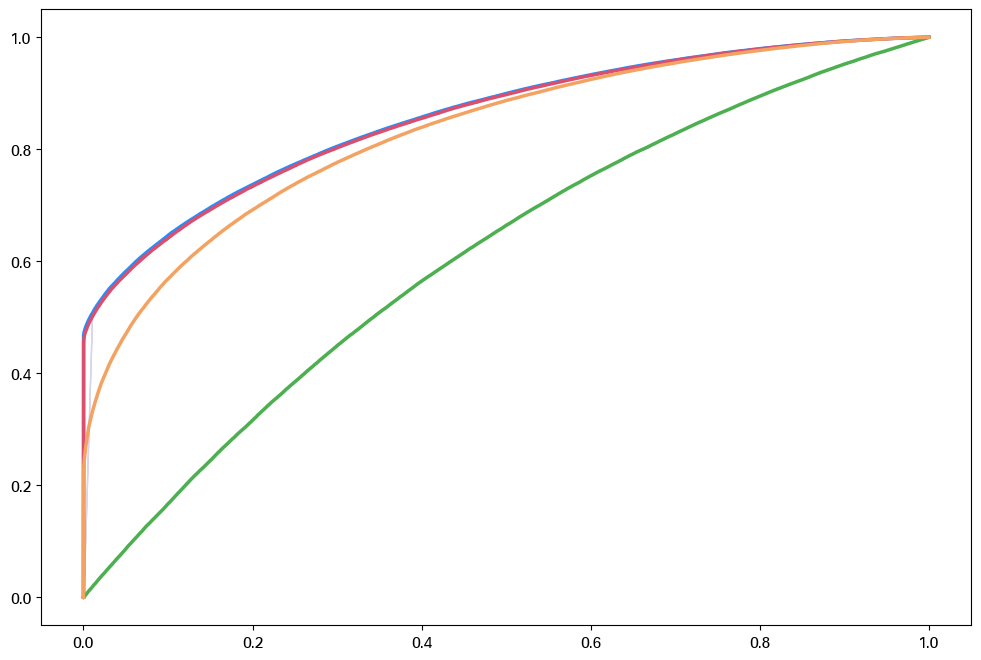

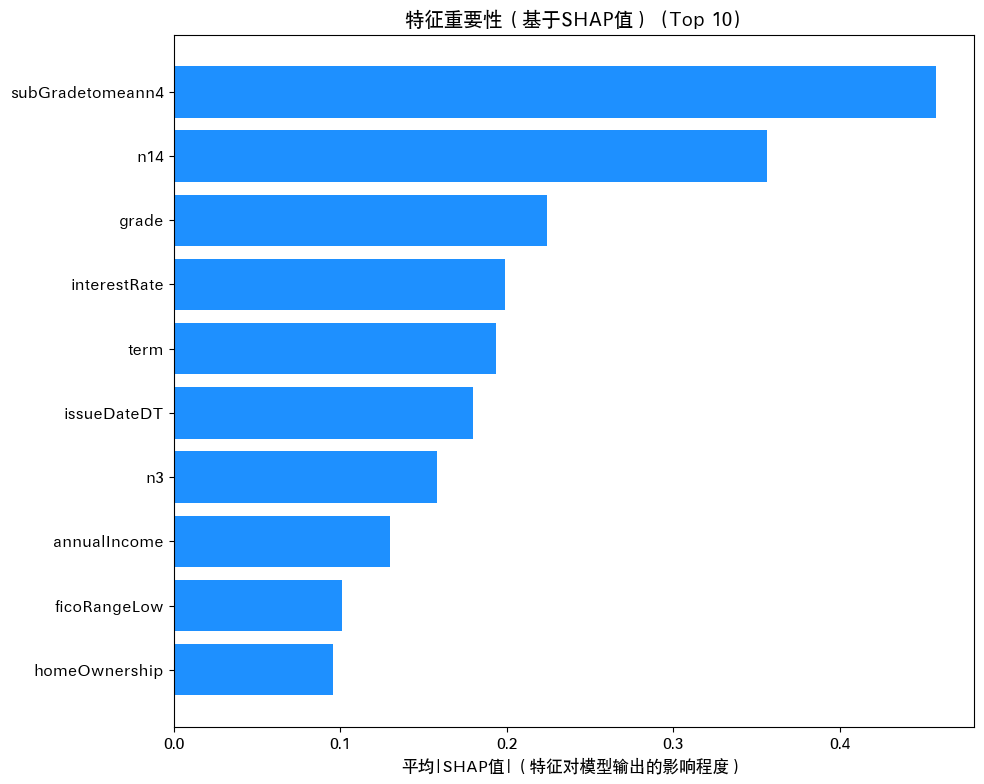


4.3.2 单变量SHAP值的映射关系 (Top 10)


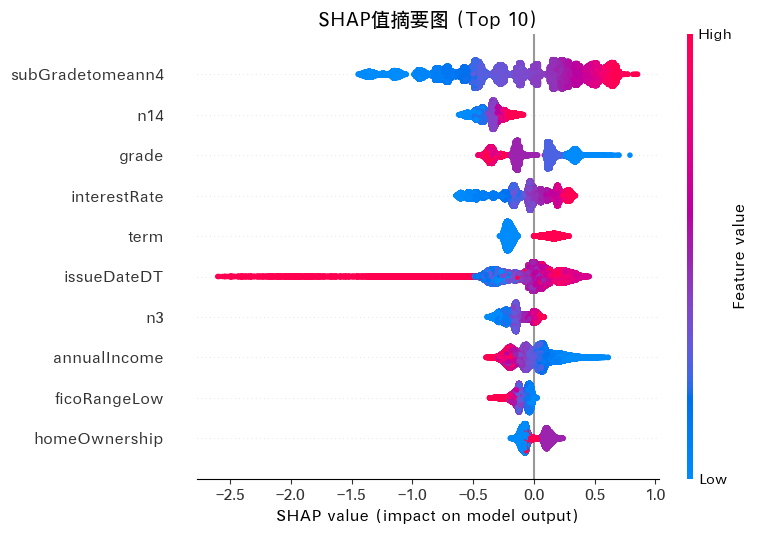


4.3.3 特定特征交互关系分析


<Figure size 1000x800 with 0 Axes>

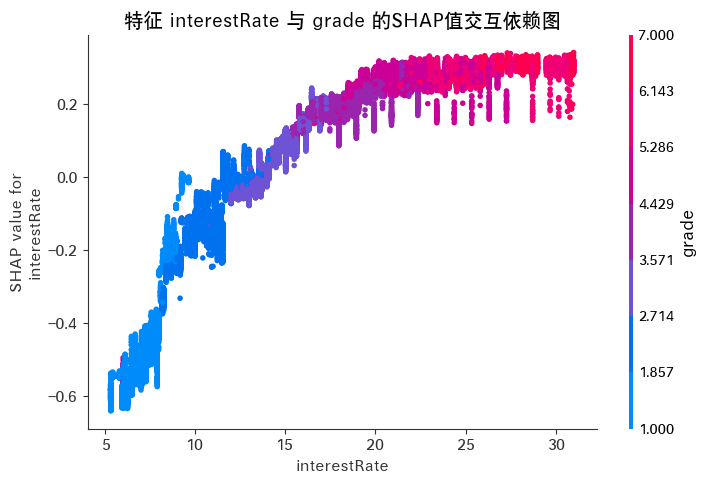

<Figure size 1000x800 with 0 Axes>

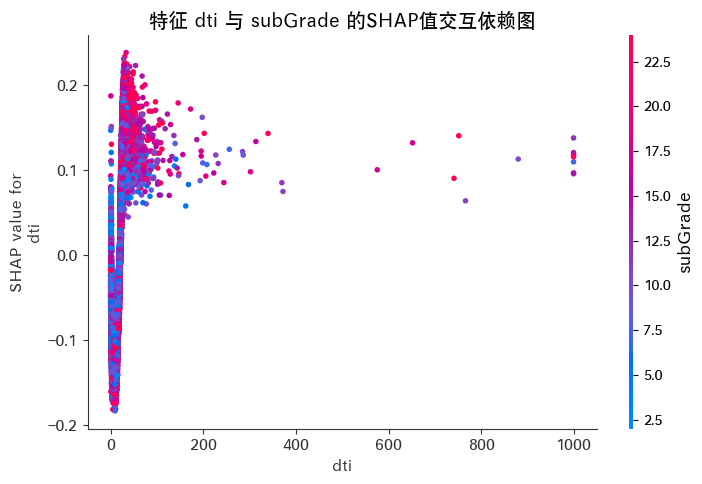

<Figure size 1000x800 with 0 Axes>

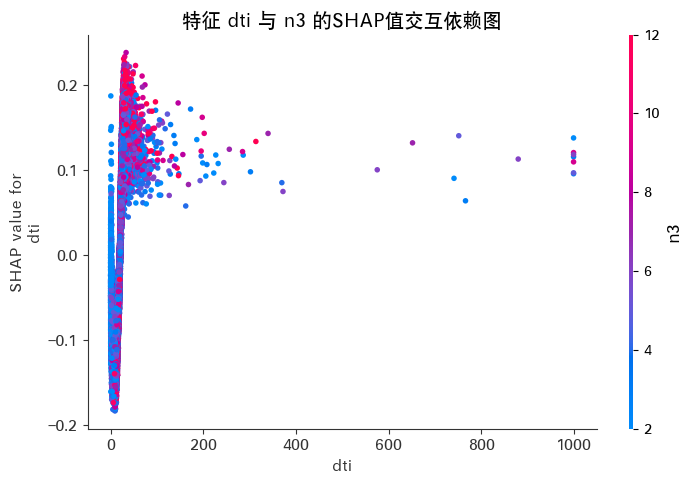


4.3.5 单个样本的SHAP值计算


<Figure size 1000x1200 with 0 Axes>

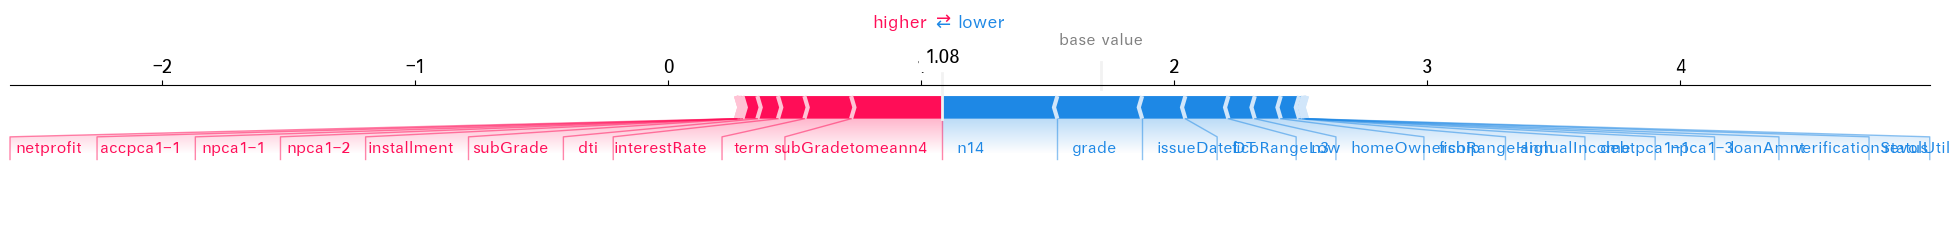

<Figure size 1000x1200 with 0 Axes>

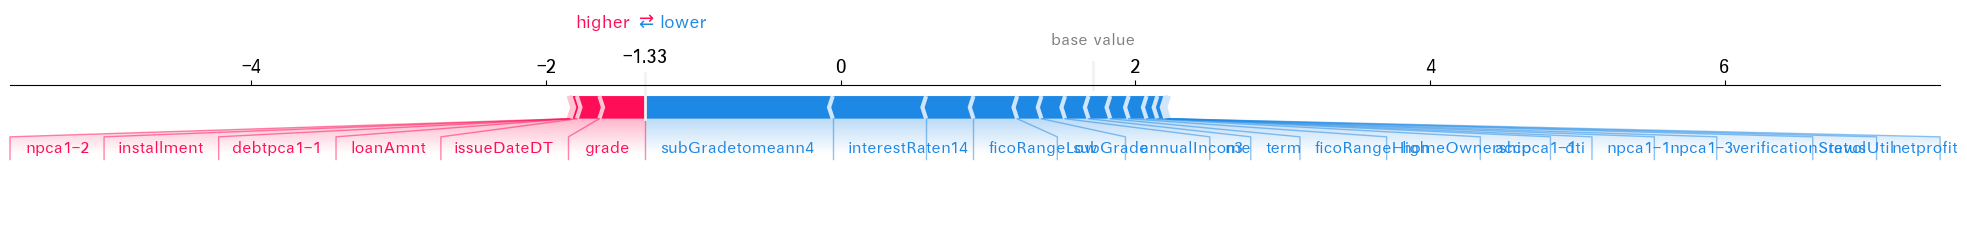

<Figure size 1000x1200 with 0 Axes>

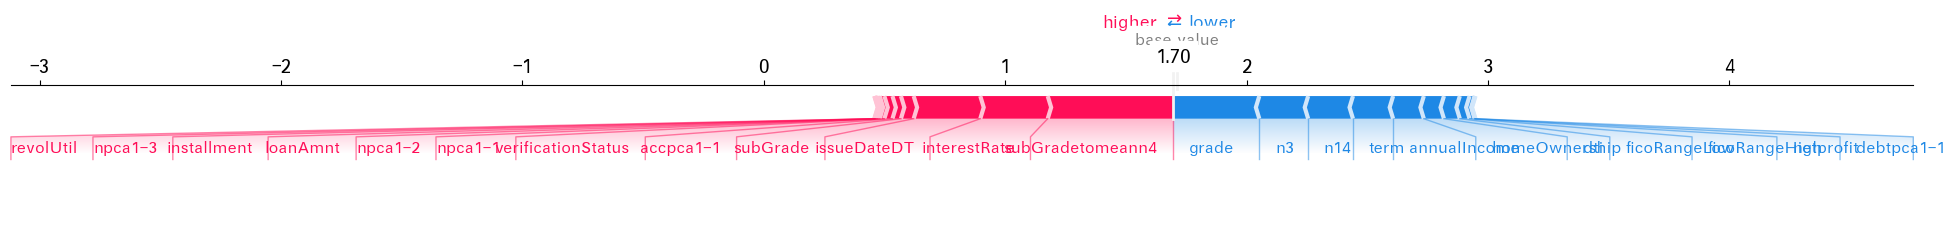

<Figure size 1000x1200 with 0 Axes>

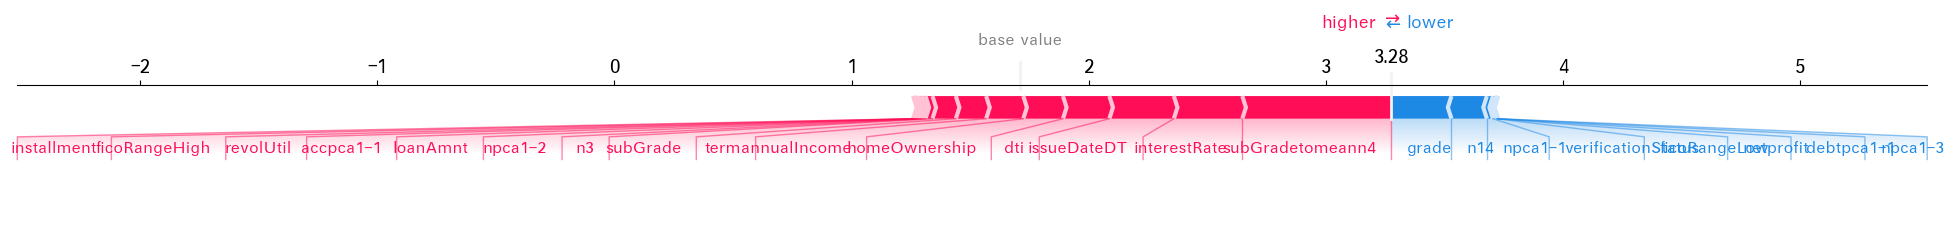

<Figure size 1000x1200 with 0 Axes>

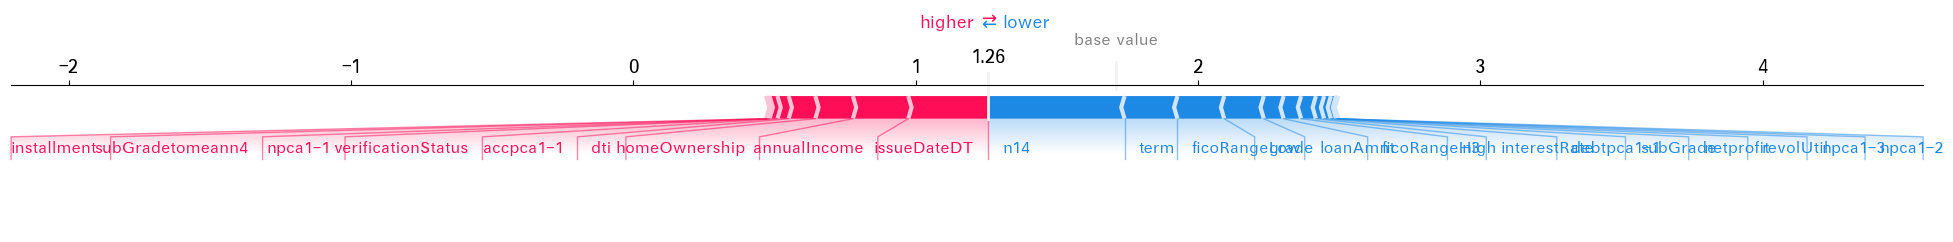

<Figure size 1000x1200 with 0 Axes>

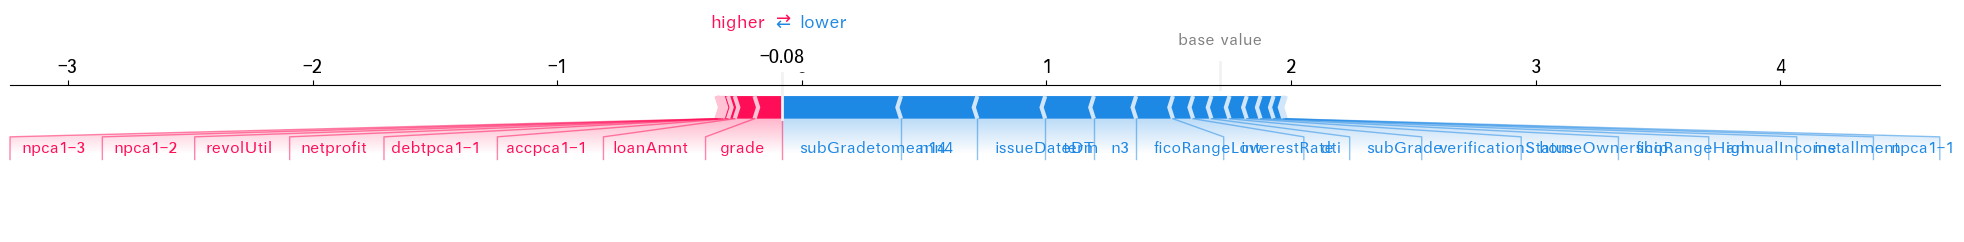

<Figure size 1000x1200 with 0 Axes>

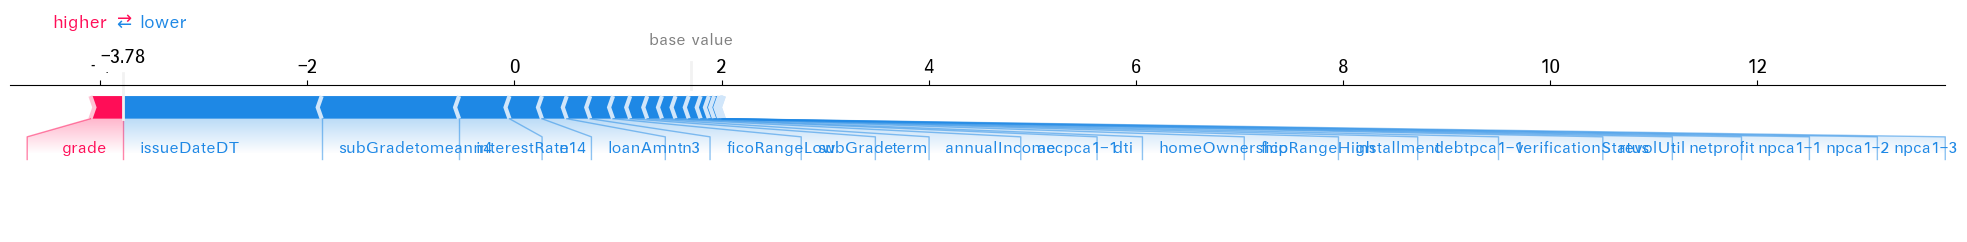

<Figure size 1000x1200 with 0 Axes>

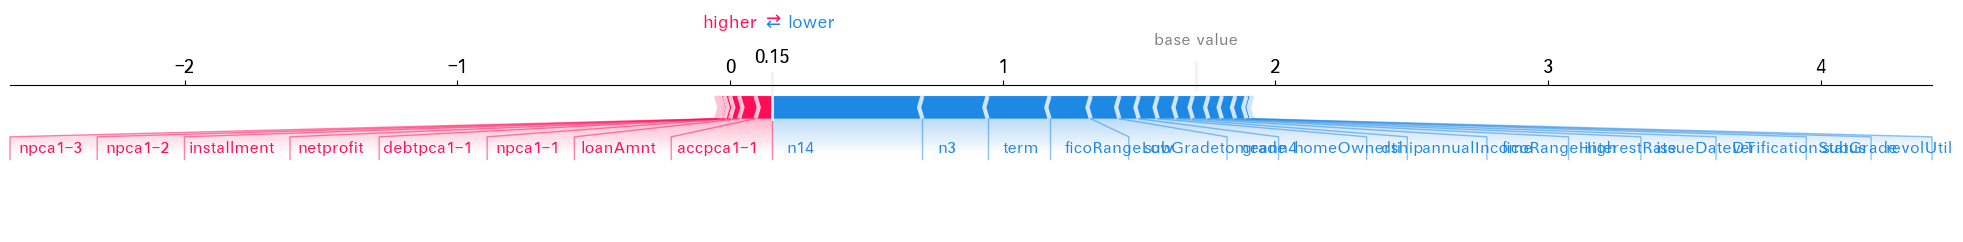


保存所有特征的SHAP值总和到CSV
所有特征的SHAP值总和已保存到 feature_shap_values.csv


(array([[-1.02346867e-01, -1.27011157e-01, -7.72715202e-02, ...,
         -6.26847938e-03, -8.78523396e-04, -4.45479617e-01],
        [ 4.84851351e-02, -3.46794902e-02, -9.29258201e-02, ...,
          3.16131611e-04, -3.16208148e-03,  2.67361290e-01],
        [ 1.66809025e-01, -1.84920757e-01,  1.20542404e-01, ...,
         -6.53597646e-03,  4.57997713e-03,  5.05118382e-01],
        ...,
        [-7.91341522e-02, -4.69935584e-02, -2.82439066e-02, ...,
          1.77596303e-03, -3.07482196e-03,  3.01091774e-01],
        [-1.15092123e-01, -1.19110352e-01,  1.54425273e-01, ...,
          1.68405987e-03, -3.38754885e-03,  4.81025163e-01],
        [-9.81460539e-02, -1.10985226e-01,  9.21197039e-02, ...,
          1.36904862e-03, -1.21616464e-03, -9.24144280e-01]]),
 array([0.08641819, 0.10081717, 0.0956564 , 0.0705107 , 0.03231696,
        0.22428496, 0.03482244, 0.17985617, 0.19376368, 0.00606555,
        0.00549598, 0.15786397, 0.07074824, 0.35652729, 0.19878581,
        0.13014339, 0.019

In [310]:
main_shap_analysis(model, x_train, x_test, feature_names=None, sample_indices=[99, 5, 10,68387,15274,143193,36088,17])